# Nodal RSAM noise profiles by geometry, component, and frequency band

This notebook summarizes RSAM amplitudes from the nodal SDS-derived RSAM archive.

Current assumptions:

- RSAM files live under `LBSSP_DATA/nodal_rsam`.
- Geometry comes from `Combined_By_Window` in `glenn_smartsolo_nodal_metadata_with_estimated_coords.xlsx`.
- SEED location codes map to geometry windows: `N1 → 1`, `N2 → 2`, `N3 → 3`.
- `N1` and `N3` share the same long-aperture geometry and can be plotted together; `N2` is the dense array.
- Components are `DPE`, `DPN`, and `DPZ`, summarized separately.
- Frequency bands use octave-style labels: `B4_8`, `B8_16`, `B16_32`, `B32_64`, `B64_128`, `B128_240`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import UTCDateTime
from flovopy.processing.sam import RSAM

plt.rcParams["figure.dpi"] = 120

## Configuration

In [2]:
LBSSP_DATA = Path("/Volumes/tachyon/LBSSP_DATA")
SAM_DIR = LBSSP_DATA / "nodal_rsam"
OUT_DIR = LBSSP_DATA / "nodal_qc" / "noise_profiles"
OUT_DIR.mkdir(parents=True, exist_ok=True)

METADATA_FILE = Path(
    "/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/"
    "2026KarstGeophysicsDEP/04_FieldData/"
    "glenn_smartsolo_nodal_metadata_with_estimated_coords.xlsx"
)

# Fallback if this notebook is run inside the ChatGPT sandbox.
if not METADATA_FILE.exists():
    fallback = Path("/mnt/data/glenn_smartsolo_nodal_metadata_with_estimated_coords(1).xlsx")
    if fallback.exists():
        METADATA_FILE = fallback

NETWORKS = ["T1", "T3"]
LOCATIONS = ["N1", "N2", "N3"]
CHANNELS = ["DPE", "DPN", "DPZ"]
COMPONENT_LABEL = {"DPE": "E", "DPN": "N", "DPZ": "Z"}

BANDS = [
    "rms",
    "B4_8",
    "B8_16",
    "B16_32",
    "B32_64",
    "B64_128",
    "B128_240",
]

LOCATION_TO_WINDOW_ID = {"N1": 1, "N2": 2, "N3": 3}
PLOT_GROUPS = {"N1_N3": ["N1", "N3"], "N2": ["N2"]}

WINDOWS = [
    {"period": "overnight_2026-05-17_0400_0800", "group": "overnight", "label": "Overnight 2026-05-17 0400–0800 UTC", "start": UTCDateTime("2026-05-17T04:00:00"), "end": UTCDateTime("2026-05-17T08:00:00")},
    {"period": "overnight_2026-05-18_0400_0800", "group": "overnight", "label": "Overnight 2026-05-18 0400–0800 UTC", "start": UTCDateTime("2026-05-18T04:00:00"), "end": UTCDateTime("2026-05-18T08:00:00")},
    {"period": "overnight_2026-05-19_0400_0800", "group": "overnight", "label": "Overnight 2026-05-19 0400–0800 UTC", "start": UTCDateTime("2026-05-19T04:00:00"), "end": UTCDateTime("2026-05-19T08:00:00")},
    {"period": "may18_1100_1300_pre_site", "group": "pre_site", "label": "May 18 1100–1300 UTC, before site arrival", "start": UTCDateTime("2026-05-18T11:00:00"), "end": UTCDateTime("2026-05-18T13:00:00")},
]

START = min(w["start"] for w in WINDOWS)
END = max(w["end"] for w in WINDOWS)

print(f"LBSSP_DATA:    {LBSSP_DATA}")
print(f"SAM_DIR:       {SAM_DIR}")
print(f"OUT_DIR:       {OUT_DIR}")
print(f"METADATA_FILE: {METADATA_FILE}")
print(f"Read RSAM from {START} to {END}")

LBSSP_DATA:    /Volumes/tachyon/LBSSP_DATA
SAM_DIR:       /Volumes/tachyon/LBSSP_DATA/nodal_rsam
OUT_DIR:       /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles
METADATA_FILE: /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/04_FieldData/glenn_smartsolo_nodal_metadata_with_estimated_coords.xlsx
Read RSAM from 2026-05-17T04:00:00.000000Z to 2026-05-19T08:00:00.000000Z


## Read nodal geometry metadata

In [3]:
def normalize_serial(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if s.endswith(".0"):
        s = s[:-2]
    if len(s) > 5 and s.isdigit():
        s = s[-5:]
    return s


def load_geometry(metadata_file):
    geom = pd.read_excel(metadata_file, sheet_name="Combined_By_Window").copy()
    geom["station"] = geom["normalized_serial_number"].apply(normalize_serial)
    geom["window_id"] = pd.to_numeric(geom["window_id"], errors="coerce").astype("Int64")
    geom["position_m"] = pd.to_numeric(geom["position_m"], errors="coerce")
    geom["node_from_north"] = pd.to_numeric(geom["node_from_north"], errors="coerce")

    keep = [
        "window_id", "station", "normalized_serial_number", "position_m",
        "node_from_north", "line_or_transect", "geometry_source",
        "position_method", "qc_flag",
    ]
    keep = [c for c in keep if c in geom.columns]
    geom = geom[keep].dropna(subset=["window_id", "station", "position_m"])
    geom["window_id"] = geom["window_id"].astype(int)
    geom["station"] = geom["station"].astype(str)
    return geom

geom = load_geometry(METADATA_FILE)
display(geom.head())
print("Rows by window_id:")
print(geom.groupby("window_id").size())

,window_id,station,normalized_serial_number,position_m,node_from_north,line_or_transect,geometry_source,position_method,qc_flag
0,1,20358,453020358.0,28.00,0.0,T1,survey1,nominal_extrapolated,"position estimated, not field-measured"
1,1,12320,453012320.0,36.00,1.0,T1,survey1,measured,NaN
2,1,19115,453019115.0,44.00,2.0,T1,survey1,measured,NaN
3,1,14357,453014357.0,52.07,3.0,T1,survey1,measured,NaN
4,1,13396,453013396.0,60.04,4.0,T1,survey1,measured,NaN


Rows by window_id:
window_id
1    36
2    36
3    36
dtype: int64


## Read RSAM for T1 and T3

In [4]:
rsams = {}

for network in NETWORKS:
    print("\n" + "=" * 80)
    print(f"Reading RSAM for network {network}")
    rsam = RSAM.read(
        START,
        END,
        SAM_DIR=str(SAM_DIR),
        network=network,
        sampling_interval=60,
        ext="csv",
        verbose=True,
    )
    rsams[network] = rsam
    print(f"Read {len(rsam.dataframes)} RSAM dataframes for {network}")

    for seed_id, df in list(rsam.dataframes.items())[:5]:
        valid = df["rms"].notna().sum() if "rms" in df.columns else np.nan
        print(seed_id, "rows=", len(df), "valid rms=", valid)


Reading RSAM for network T1
Reading /Volumes/tachyon/LBSSP_DATA/nodal_rsam/RSAM/T1/RSAM_T1.05726.N1.DPE_2026_60s.csv
Dataframe with 780 rows is already on a regular 60 s grid based on column 'time'
Reading /Volumes/tachyon/LBSSP_DATA/nodal_rsam/RSAM/T1/RSAM_T1.05726.N1.DPN_2026_60s.csv
Dataframe with 780 rows is already on a regular 60 s grid based on column 'time'
Reading /Volumes/tachyon/LBSSP_DATA/nodal_rsam/RSAM/T1/RSAM_T1.05726.N1.DPZ_2026_60s.csv
Dataframe with 780 rows is already on a regular 60 s grid based on column 'time'
Reading /Volumes/tachyon/LBSSP_DATA/nodal_rsam/RSAM/T1/RSAM_T1.05726.N2.DPE_2026_60s.csv
Dataframe with 2400 rows is already on a regular 60 s grid based on column 'time'
Reading /Volumes/tachyon/LBSSP_DATA/nodal_rsam/RSAM/T1/RSAM_T1.05726.N2.DPN_2026_60s.csv
Dataframe with 2400 rows is already on a regular 60 s grid based on column 'time'
Reading /Volumes/tachyon/LBSSP_DATA/nodal_rsam/RSAM/T1/RSAM_T1.05726.N2.DPZ_2026_60s.csv
Dataframe with 2400 rows is al

## Summarize RSAM by network, location, component, station position, band, and time window

In [5]:
def summarize_rsam(rsams, geom):
    rows = []

    for network, rsam in rsams.items():
        for seed_id, df in rsam.dataframes.items():
            parts = seed_id.split(".")
            if len(parts) != 4:
                continue

            net, sta, loc, chan = parts

            if net not in NETWORKS:
                continue
            if loc not in LOCATION_TO_WINDOW_ID:
                continue
            if chan not in CHANNELS:
                continue
            if "time" not in df.columns:
                continue

            window_id = LOCATION_TO_WINDOW_ID[loc]
            gmatch = geom[(geom["window_id"] == window_id) & (geom["station"] == str(sta))]

            if gmatch.empty:
                print(f"WARNING: no metadata match for {seed_id} window_id={window_id} station={sta}")
                position_m = np.nan
                node_from_north = np.nan
                position_method = np.nan
                qc_flag = np.nan
                geometry_source = np.nan
            else:
                grow = gmatch.iloc[0]
                position_m = grow.get("position_m", np.nan)
                node_from_north = grow.get("node_from_north", np.nan)
                position_method = grow.get("position_method", np.nan)
                qc_flag = grow.get("qc_flag", np.nan)
                geometry_source = grow.get("geometry_source", np.nan)

            available_bands = [b for b in BANDS if b in df.columns]
            missing_bands = [b for b in BANDS if b not in df.columns]
            if missing_bands:
                print(f"WARNING: {seed_id} missing bands: {missing_bands}")

            for win in WINDOWS:
                mask = (df["time"] >= win["start"].timestamp) & (df["time"] < win["end"].timestamp)

                for band in available_bands:
                    x = df.loc[mask, band].dropna()
                    if x.empty:
                        continue

                    rows.append({
                        "network": net,
                        "line": net,
                        "location": loc,
                        "plot_group": "N1_N3" if loc in ["N1", "N3"] else "N2",
                        "geometry_window_id": window_id,
                        "seed_id": seed_id,
                        "station": str(sta),
                        "channel": chan,
                        "component": COMPONENT_LABEL.get(chan, chan[-1]),
                        "position_m": position_m,
                        "node_from_north": node_from_north,
                        "position_method": position_method,
                        "geometry_source": geometry_source,
                        "qc_flag": qc_flag,
                        "period": win["period"],
                        "group": win["group"],
                        "period_label": win["label"],
                        "start": str(win["start"]),
                        "end": str(win["end"]),
                        "band": band,
                        "n": len(x),
                        "median": x.median(),
                        "mean": x.mean(),
                        "p25": x.quantile(0.25),
                        "p75": x.quantile(0.75),
                        "min": x.min(),
                        "max": x.max(),
                    })

    summary = pd.DataFrame(rows)
    if not summary.empty:
        summary = summary.sort_values(["network", "component", "location", "position_m", "band", "period"])
    return summary

summary = summarize_rsam(rsams, geom)
print(summary.shape)
display(summary.head())

if not summary.empty:
    print("Unique stations by network/location/component:")
    display(summary.groupby(["network", "location", "component"])["station"].nunique().unstack(fill_value=0))

(2016, 27)


,network,line,location,plot_group,geometry_window_id,seed_id,station,channel,component,position_m,...,start,end,band,n,median,mean,p25,p75,min,max
1938,T1,T1,N1,N1_N3,1,T1.20358.N1.DPE,20358,DPE,E,28.0,...,2026-05-17T04:00:00.000000Z,2026-05-17T08:00:00.000000Z,B128_240,240,0.000846,0.001177,0.000747,0.001193,0.000612,0.017747
1935,T1,T1,N1,N1_N3,1,T1.20358.N1.DPE,20358,DPE,E,28.0,...,2026-05-17T04:00:00.000000Z,2026-05-17T08:00:00.000000Z,B16_32,240,0.001072,0.001378,0.000933,0.001312,0.000829,0.013614
1936,T1,T1,N1,N1_N3,1,T1.20358.N1.DPE,20358,DPE,E,28.0,...,2026-05-17T04:00:00.000000Z,2026-05-17T08:00:00.000000Z,B32_64,240,0.000457,0.000824,0.000401,0.000611,0.000353,0.018398
1933,T1,T1,N1,N1_N3,1,T1.20358.N1.DPE,20358,DPE,E,28.0,...,2026-05-17T04:00:00.000000Z,2026-05-17T08:00:00.000000Z,B4_8,240,0.000562,0.000586,0.000502,0.000618,0.000442,0.001886
1937,T1,T1,N1,N1_N3,1,T1.20358.N1.DPE,20358,DPE,E,28.0,...,2026-05-17T04:00:00.000000Z,2026-05-17T08:00:00.000000Z,B64_128,240,0.000664,0.001080,0.000601,0.000883,0.000518,0.021614


Unique stations by network/location/component:


component          E   N   Z
network location            
T1      N1        24  24  24
        N2        24  24  24

In [6]:
summary_csv = OUT_DIR / "nodal_noise_profile_summary_by_position_all_components.csv"
summary.to_csv(summary_csv, index=False)
print(f"Wrote {summary_csv}")

if not summary.empty:
    print("Summary rows by network, component, location, band, group:")
    display(summary.groupby(["network", "component", "location", "band", "group"]).size().rename("rows").reset_index())

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/nodal_noise_profile_summary_by_position_all_components.csv
Summary rows by network, component, location, band, group:


,network,component,location,band,group,rows
0,T1,E,N1,B128_240,overnight,24
1,T1,E,N1,B16_32,overnight,24
2,T1,E,N1,B32_64,overnight,24
3,T1,E,N1,B4_8,overnight,24
4,T1,E,N1,B64_128,overnight,24
...,...,...,...,...,...,...
58,T1,Z,N2,B64_128,pre_site,24
59,T1,Z,N2,B8_16,overnight,48
60,T1,Z,N2,B8_16,pre_site,24
61,T1,Z,N2,rms,overnight,48


## Plot functions

The profile plots use linear amplitude scale.

- Thin semi-transparent lines show individual overnight windows.
- Heavy solid lines show the median of the overnight windows.
- Heavy dotted lines show May 18, 1100–1300 UTC, before site arrival / during logging activity.

Plots are generated separately by component so that E/N/Z amplitudes are not conflated.

In [7]:
def plot_noise_profile(summary, network, component, plot_group_name, locations, band):
    sdf = summary[
        (summary["network"] == network)
        & (summary["component"] == component)
        & (summary["location"].isin(locations))
        & (summary["band"] == band)
        & summary["position_m"].notna()
    ].copy()

    if sdf.empty:
        print(f"No data for {network} {component} {plot_group_name} {band}")
        return None

    fig, ax = plt.subplots(figsize=(11, 5))
    overnight = sdf[sdf["group"] == "overnight"].copy()

    for (loc, period), g in overnight.groupby(["location", "period"]):
        g = g.sort_values("position_m")
        label = f"{loc} {period.replace('overnight_', '').replace('_0400_0800', '')}"
        ax.plot(
            g["position_m"], g["median"],
            color="0.65", alpha=0.35, linewidth=1.0,
            marker="o", markersize=2.5,
            label=label,
        )

    med = (
        overnight
        .groupby("position_m", as_index=False)["median"]
        .median()
        .sort_values("position_m")
    )

    if not med.empty:
        ax.plot(
            med["position_m"], med["median"],
            color="black", linewidth=2.8,
            marker="o", markersize=4,
            label="Overnight median, 0400–0800 UTC",
        )

    pre = (
        sdf[sdf["group"] == "pre_site"]
        .groupby("position_m", as_index=False)["median"]
        .median()
        .sort_values("position_m")
    )

    if not pre.empty:
        ax.plot(
            pre["position_m"], pre["median"],
            color="black", linestyle=":", linewidth=2.4,
            marker="s", markersize=4,
            label="May 18, 1100–1300 UTC",
        )

    ax.set_title(f"{network} {plot_group_name} {component}-component noise profile: {band}")
    ax.set_xlabel("Position along line (m)")
    ax.set_ylabel(f"{band} RSAM amplitude, linear scale")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()

    outfile = OUT_DIR / f"{network}_{plot_group_name}_{component}_noise_profile_{band}.png"
    fig.savefig(outfile, dpi=200)
    plt.show()
    print(f"Wrote {outfile}")
    return outfile


def plot_noise_profile_all_lines(summary, network, component, band):
    sdf = summary[
        (summary["network"] == network)
        & (summary["component"] == component)
        & (summary["band"] == band)
        & summary["position_m"].notna()
    ].copy()

    if sdf.empty:
        print(f"No data for {network} {component} {band}")
        return None

    fig, ax = plt.subplots(figsize=(13, 6))
    line_styles = {"N1_N3": "-", "N2": "--"}
    marker_styles = {"N1_N3": "o", "N2": "s"}
    overnight = sdf[sdf["group"] == "overnight"]

    for plot_group, pg in overnight.groupby("plot_group"):
        for period, g in pg.groupby("period"):
            g = g.sort_values("position_m")
            label = f"{plot_group} {period.replace('overnight_', '').replace('_0400_0800', '')}"
            ax.plot(
                g["position_m"], g["median"],
                linestyle=line_styles.get(plot_group, "-"),
                marker=marker_styles.get(plot_group, "o"),
                linewidth=1.2,
                markersize=3,
                alpha=0.45,
                label=label,
            )

    for plot_group, pg in overnight.groupby("plot_group"):
        med = pg.groupby("position_m", as_index=False)["median"].median().sort_values("position_m")
        if med.empty:
            continue
        ax.plot(
            med["position_m"], med["median"],
            linestyle=line_styles.get(plot_group, "-"),
            marker=marker_styles.get(plot_group, "o"),
            linewidth=3.0,
            markersize=4,
            label=f"{plot_group} overnight median",
        )

    pre = sdf[sdf["group"] == "pre_site"]
    for plot_group, g in pre.groupby("plot_group"):
        g = g.sort_values("position_m")
        ax.plot(
            g["position_m"], g["median"],
            linestyle=":",
            marker=marker_styles.get(plot_group, "o"),
            linewidth=2.5,
            markersize=4,
            label=f"{plot_group} May 18 1100–1300 UTC",
        )

    ax.set_title(f"{network} {component}-component noise profiles: {band}")
    ax.set_xlabel("Position along line (m)")
    ax.set_ylabel(f"{band} RSAM amplitude, linear scale")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0, fontsize=8)
    fig.tight_layout()

    outfile = OUT_DIR / f"{network}_ALL_LINES_{component}_noise_profile_{band}.png"
    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Wrote {outfile}")
    return outfile

## Generate plots

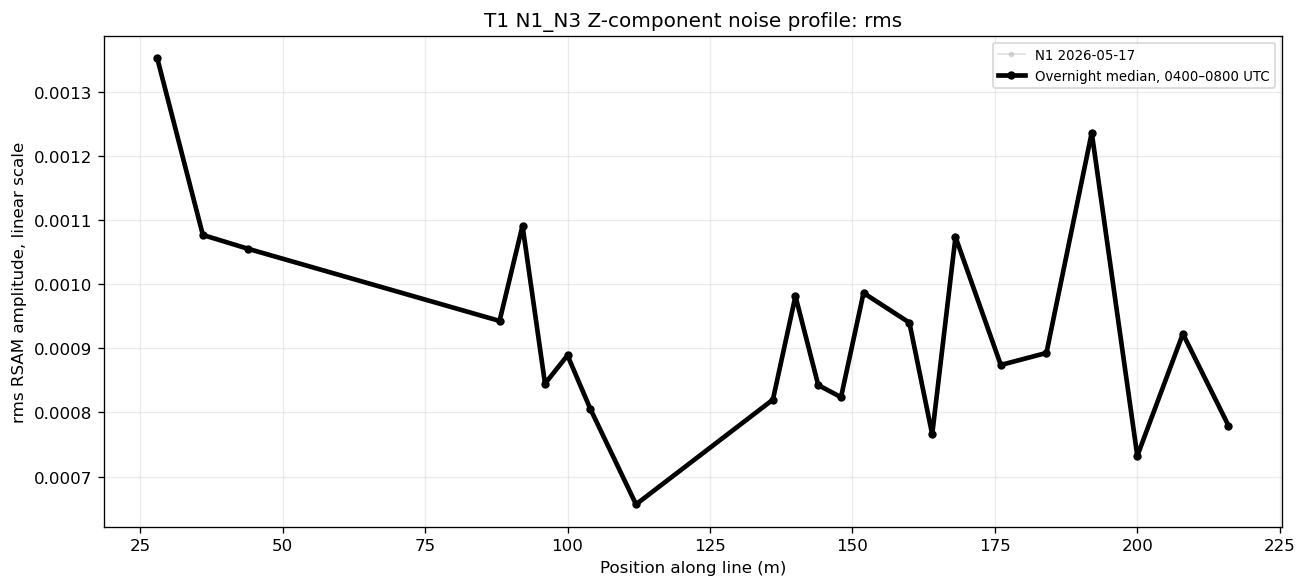

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_Z_noise_profile_rms.png


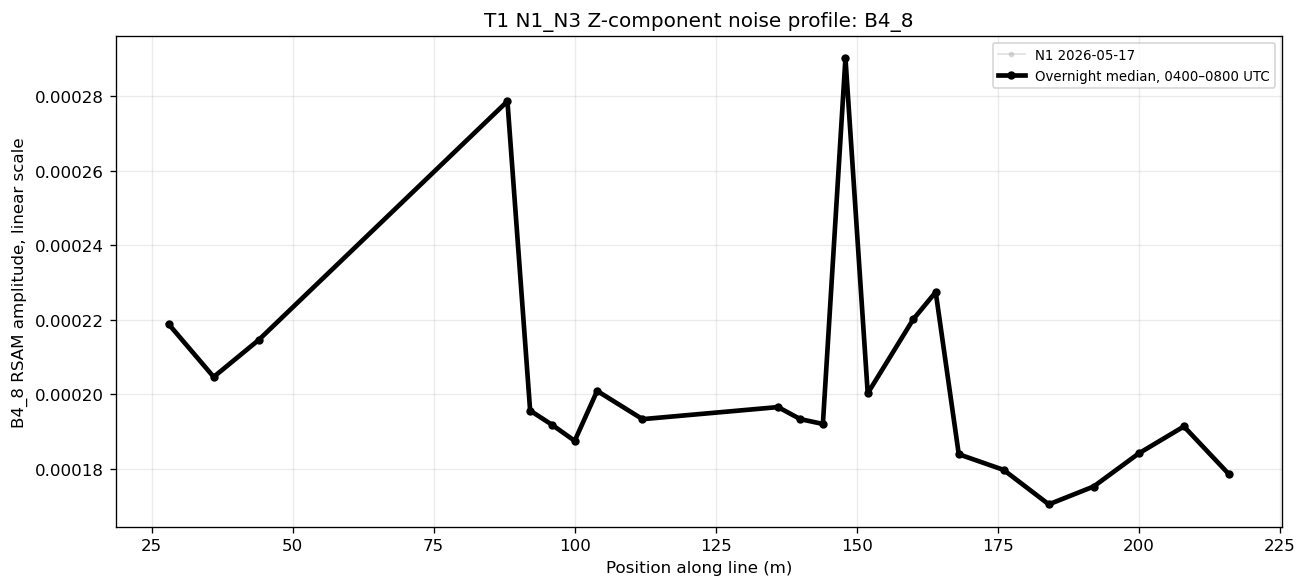

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_Z_noise_profile_B4_8.png


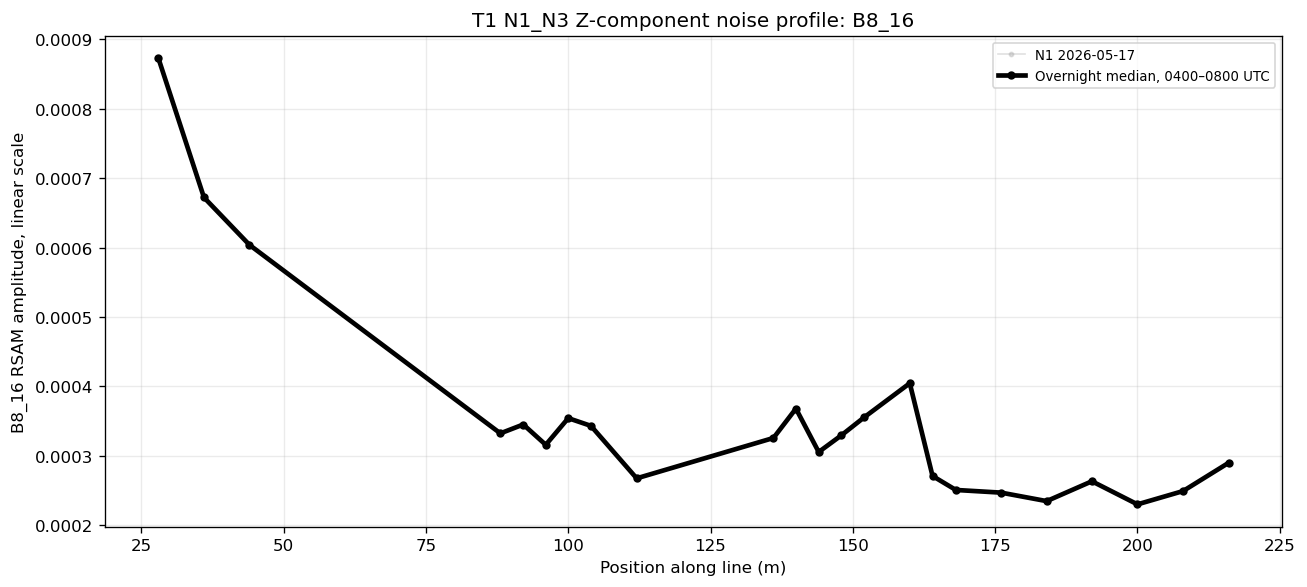

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_Z_noise_profile_B8_16.png


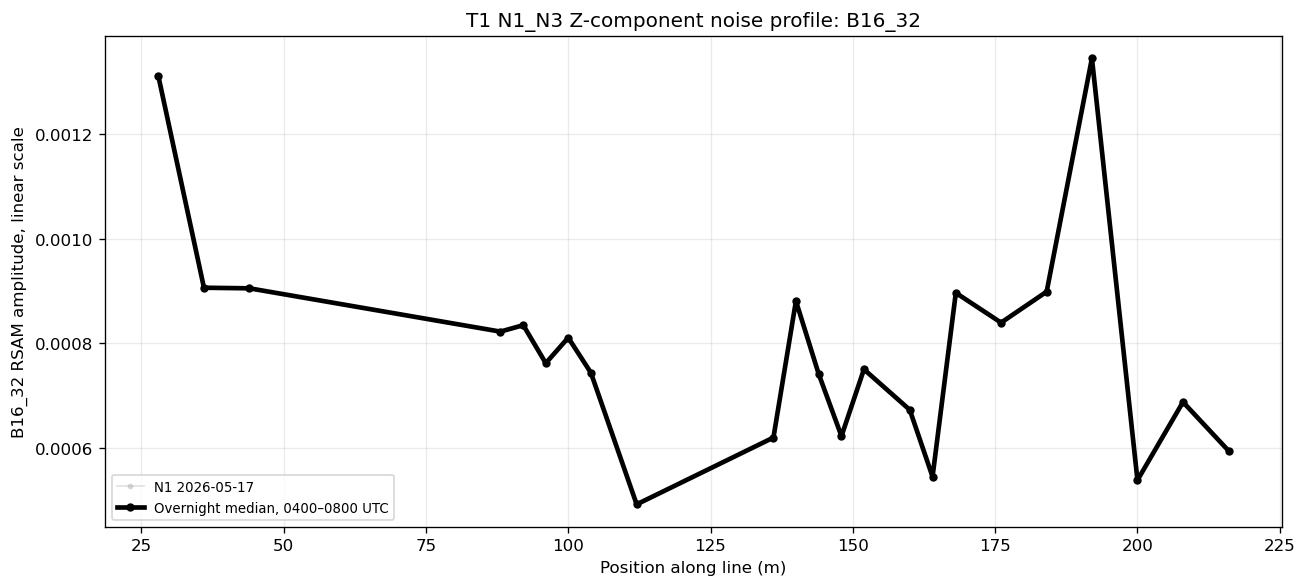

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_Z_noise_profile_B16_32.png


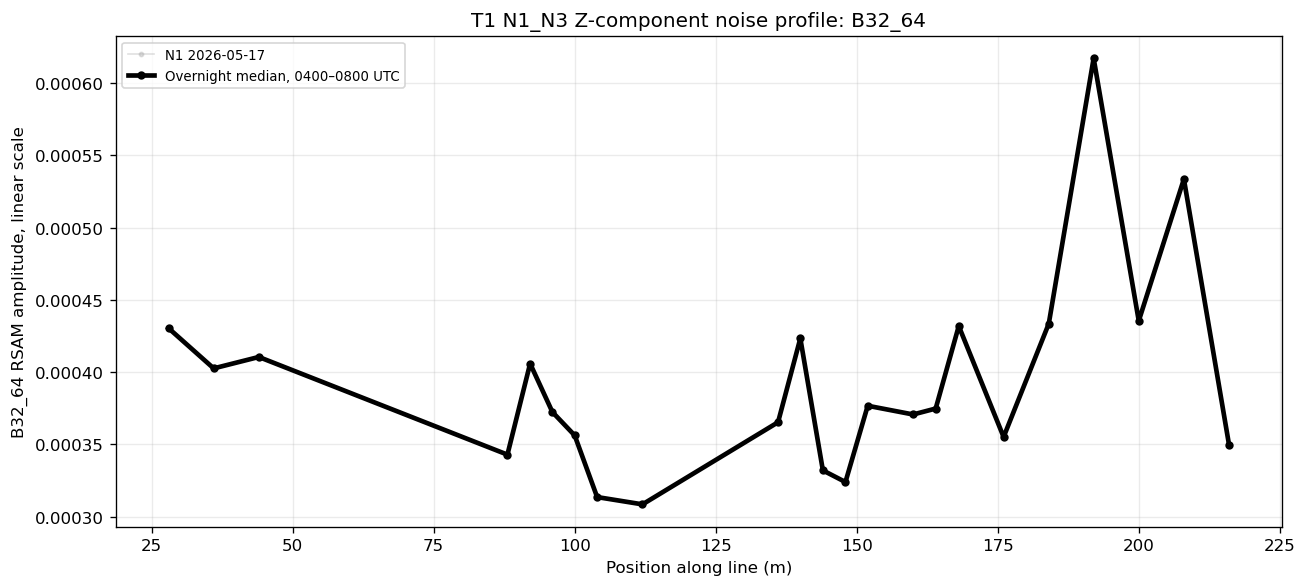

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_Z_noise_profile_B32_64.png


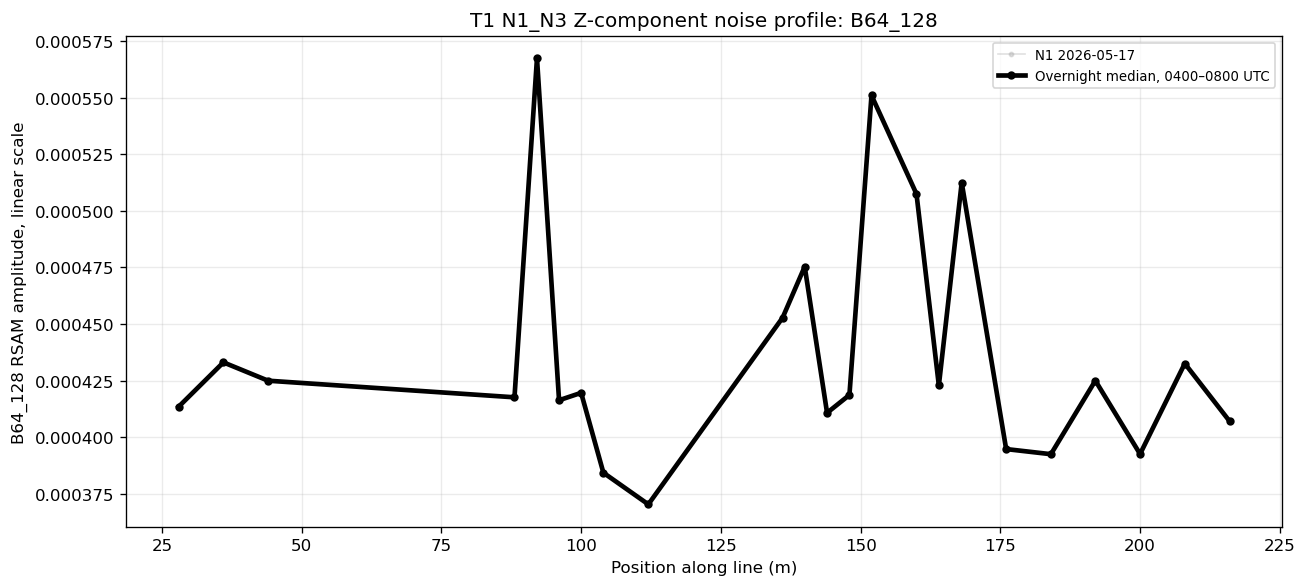

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_Z_noise_profile_B64_128.png


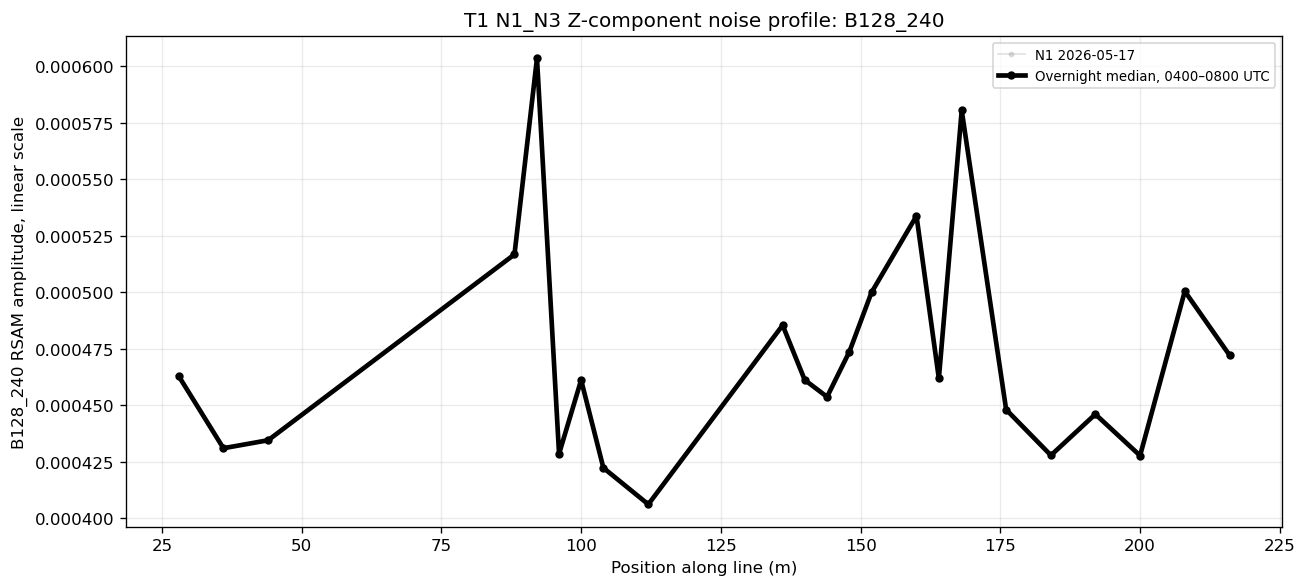

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_Z_noise_profile_B128_240.png


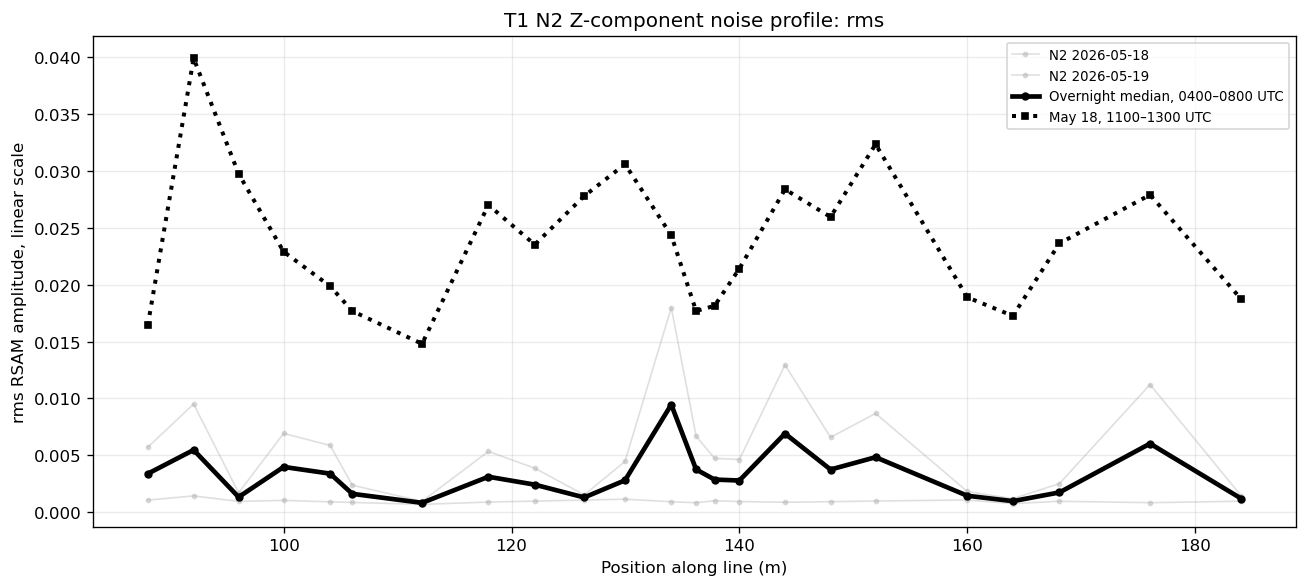

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_Z_noise_profile_rms.png


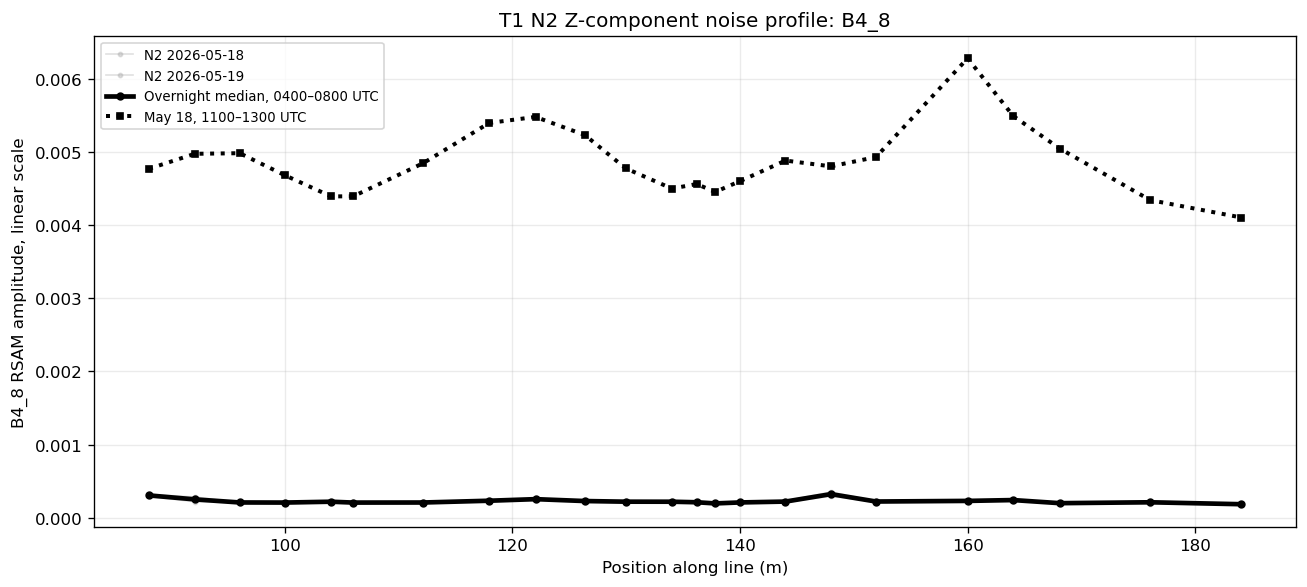

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_Z_noise_profile_B4_8.png


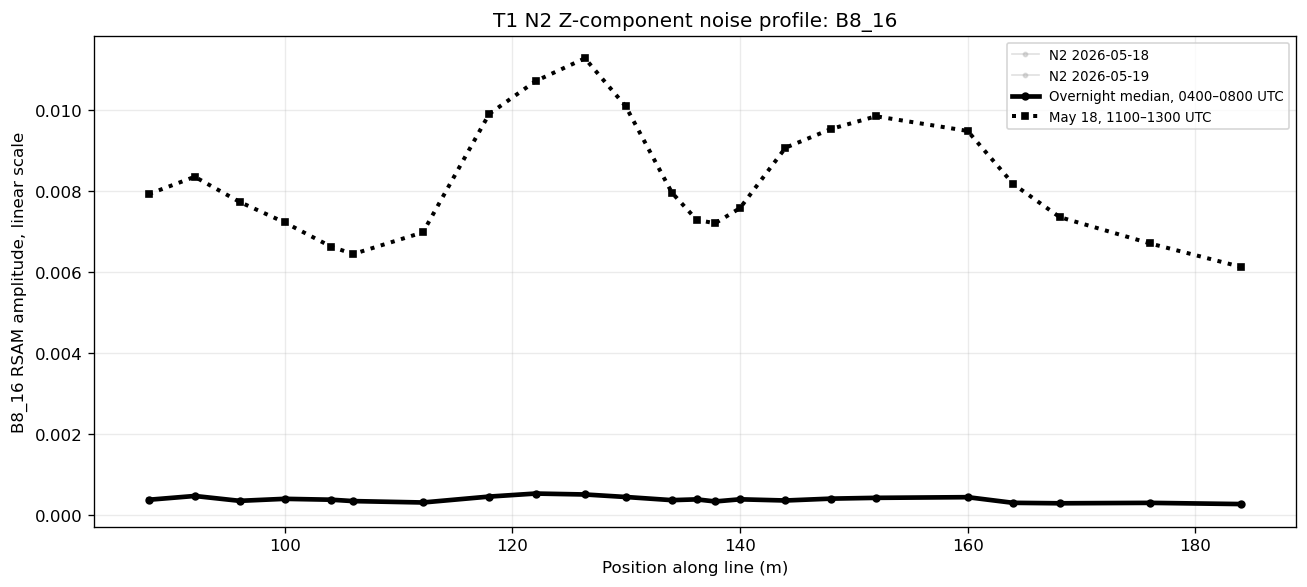

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_Z_noise_profile_B8_16.png


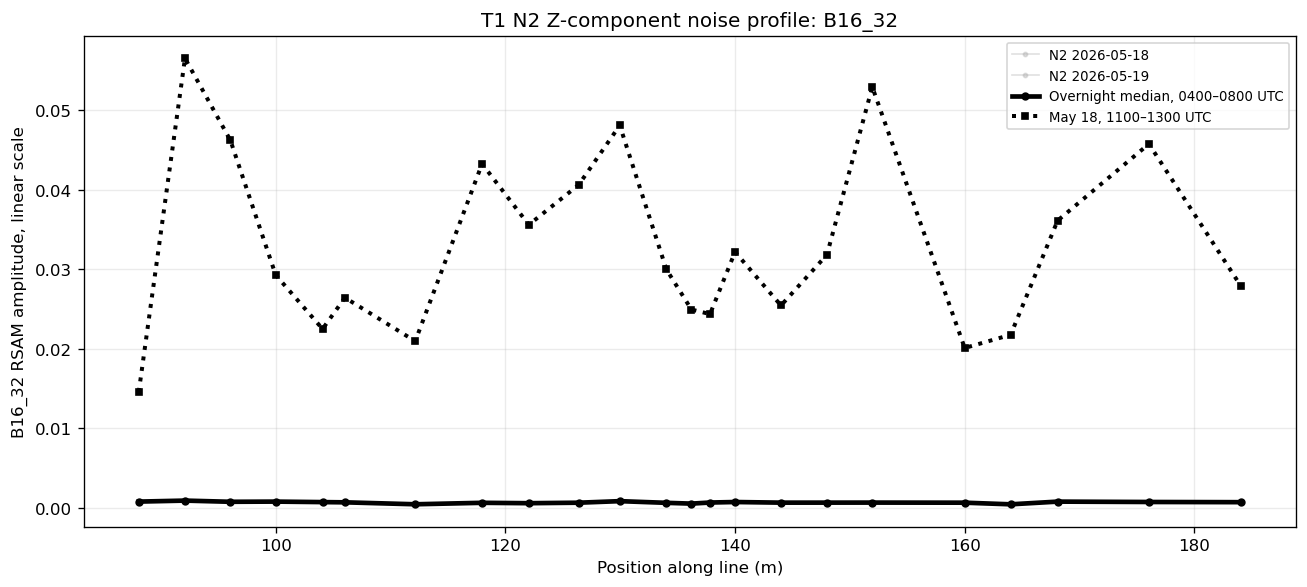

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_Z_noise_profile_B16_32.png


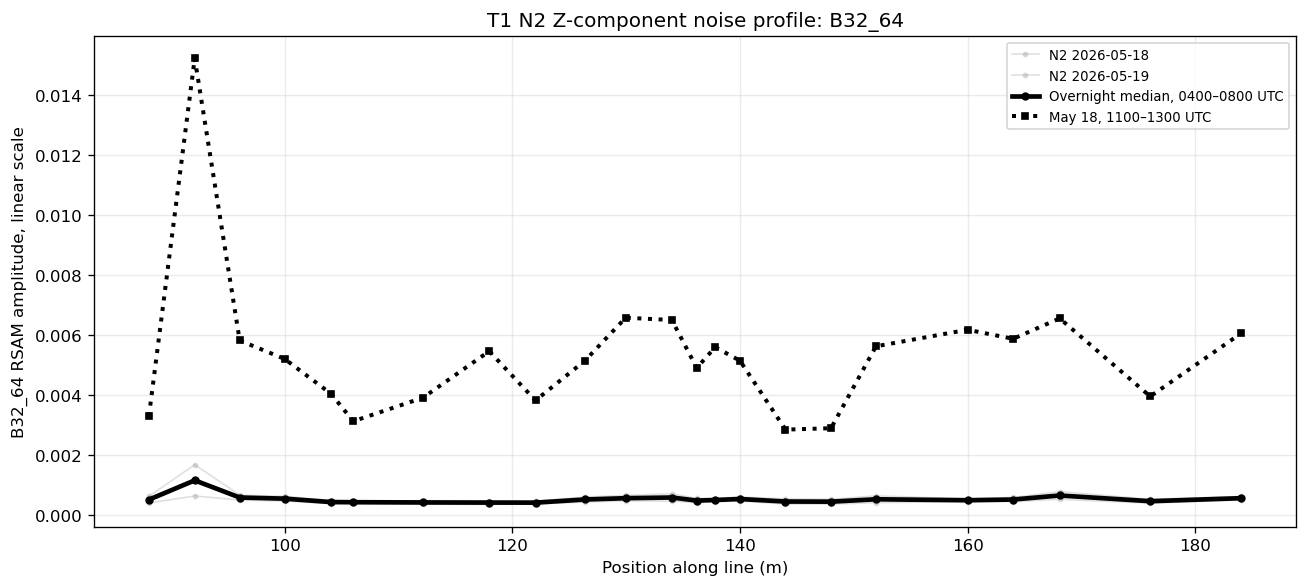

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_Z_noise_profile_B32_64.png


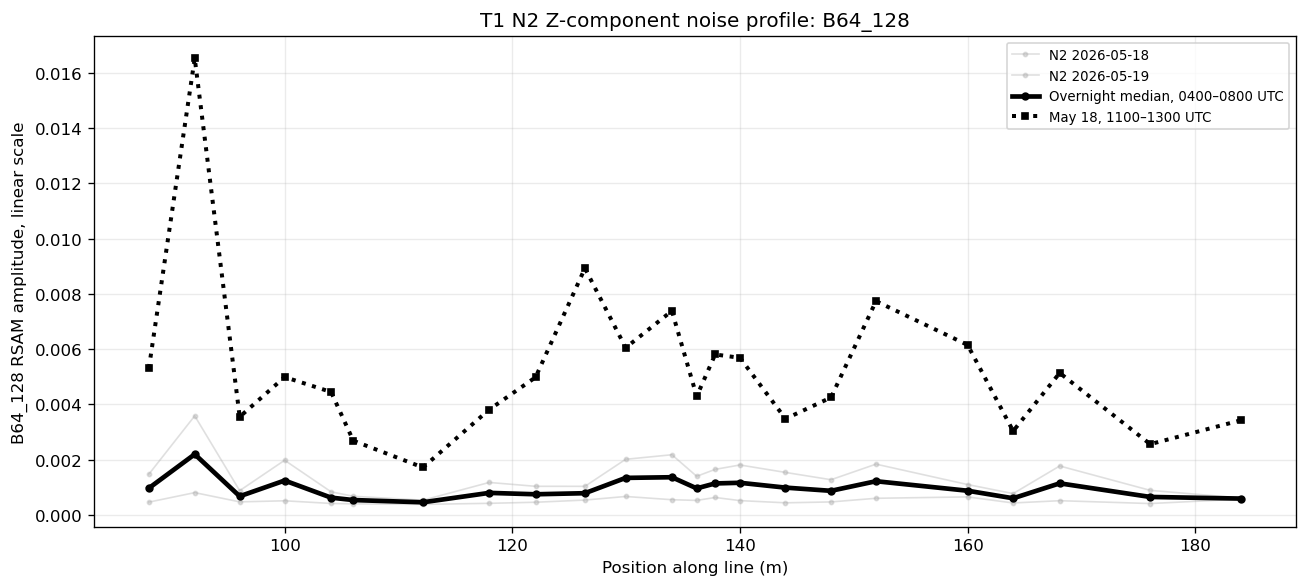

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_Z_noise_profile_B64_128.png


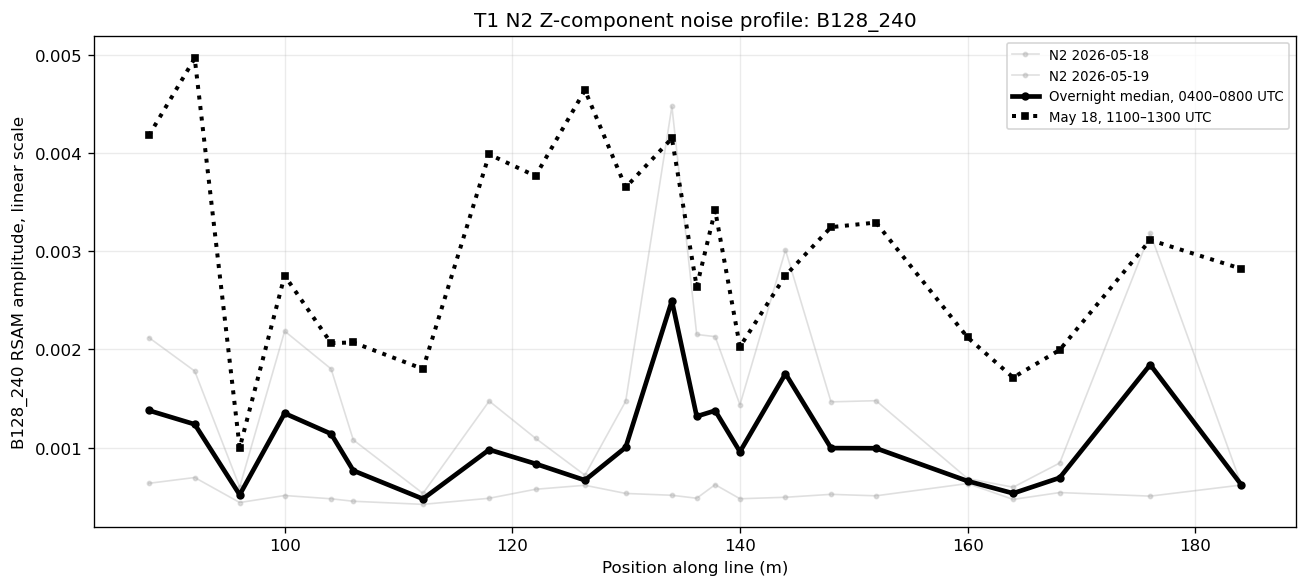

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_Z_noise_profile_B128_240.png


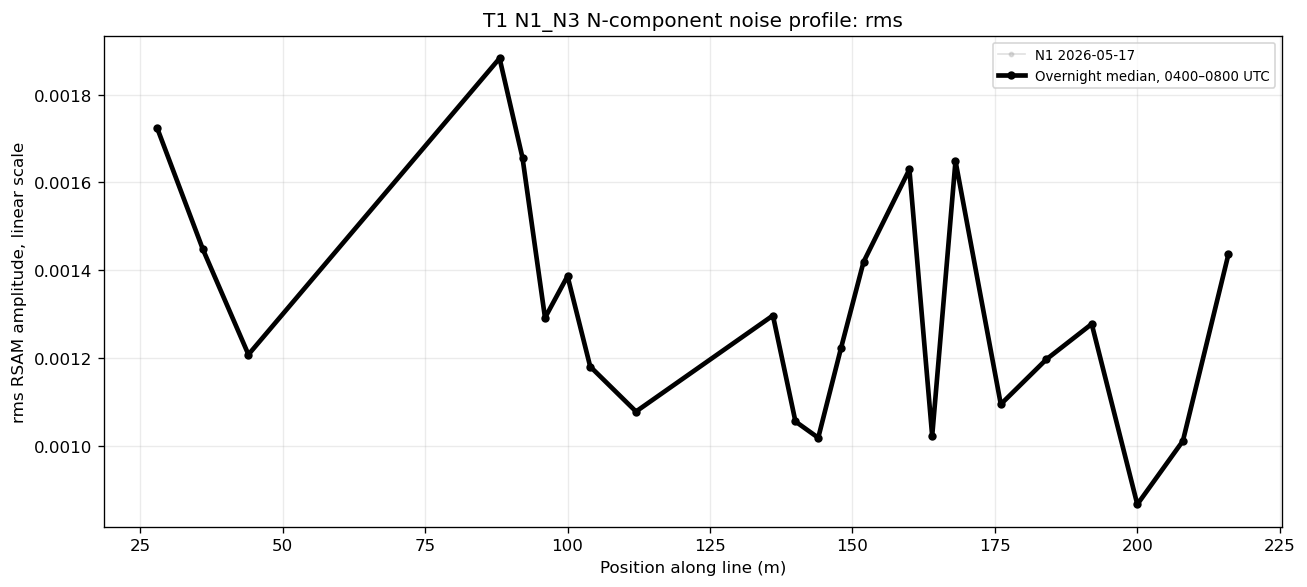

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_N_noise_profile_rms.png


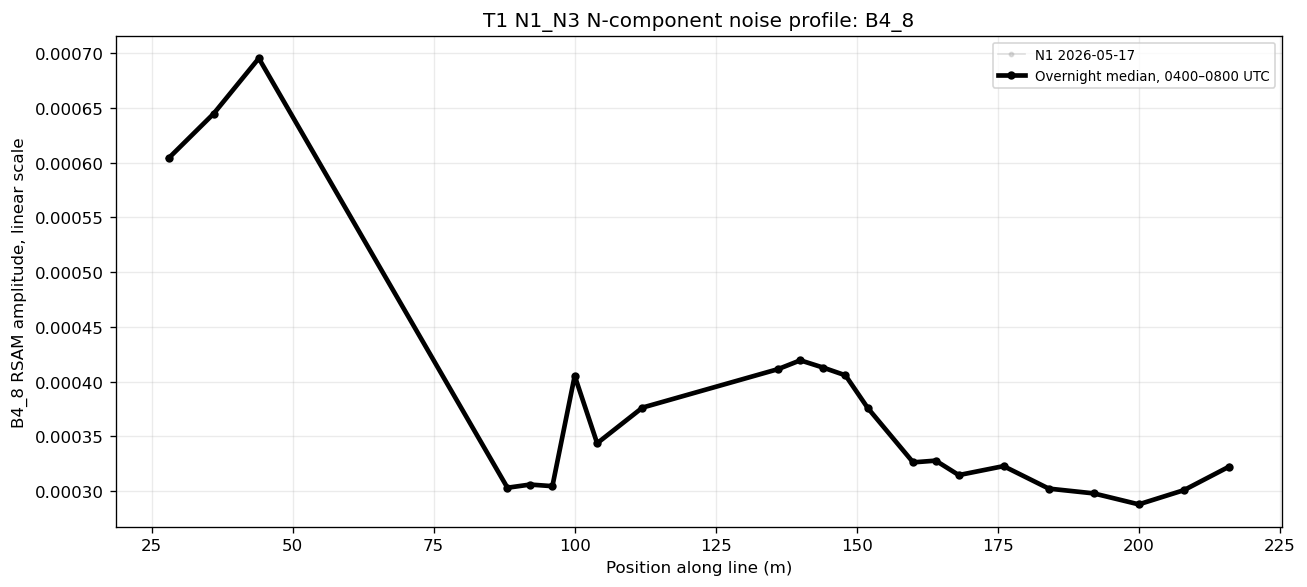

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_N_noise_profile_B4_8.png


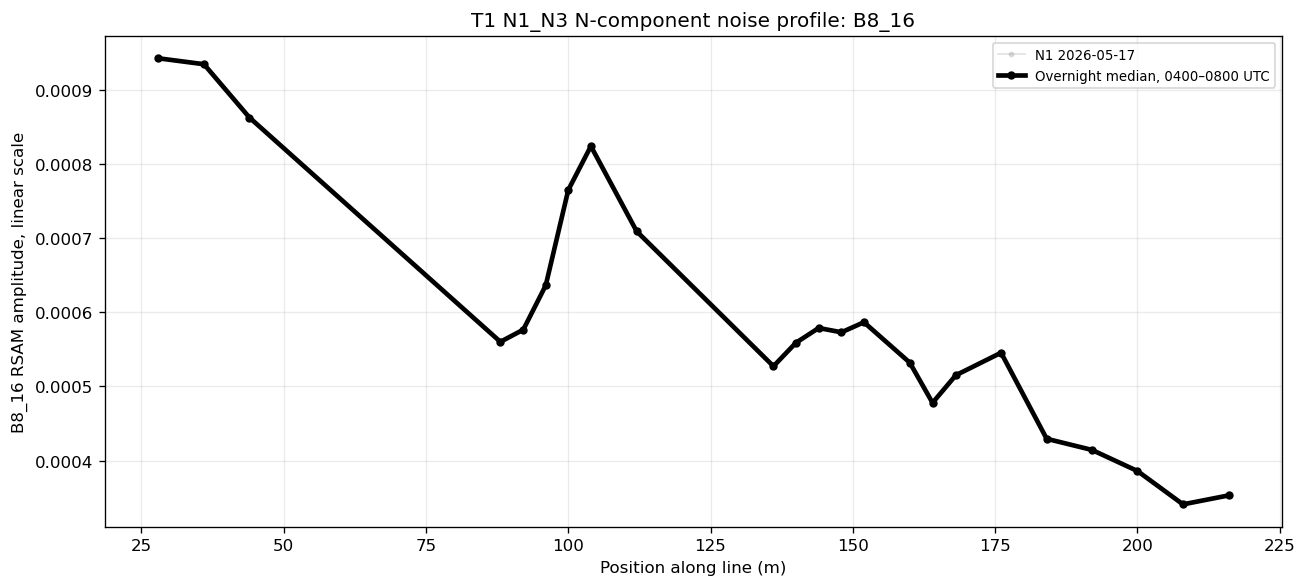

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_N_noise_profile_B8_16.png


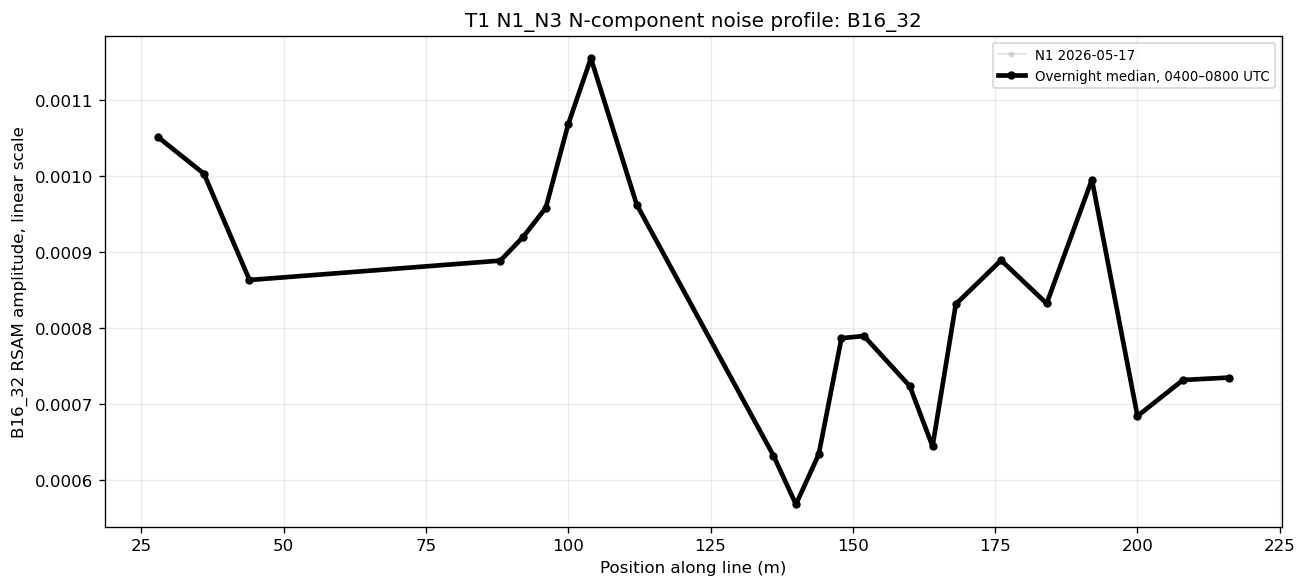

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_N_noise_profile_B16_32.png


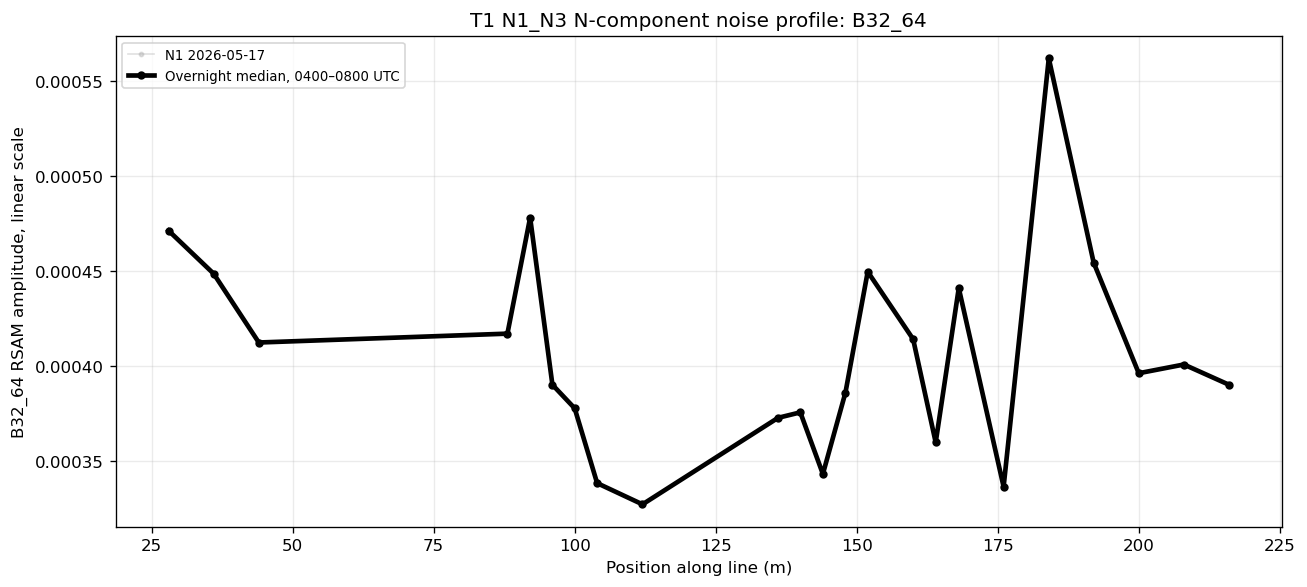

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_N_noise_profile_B32_64.png


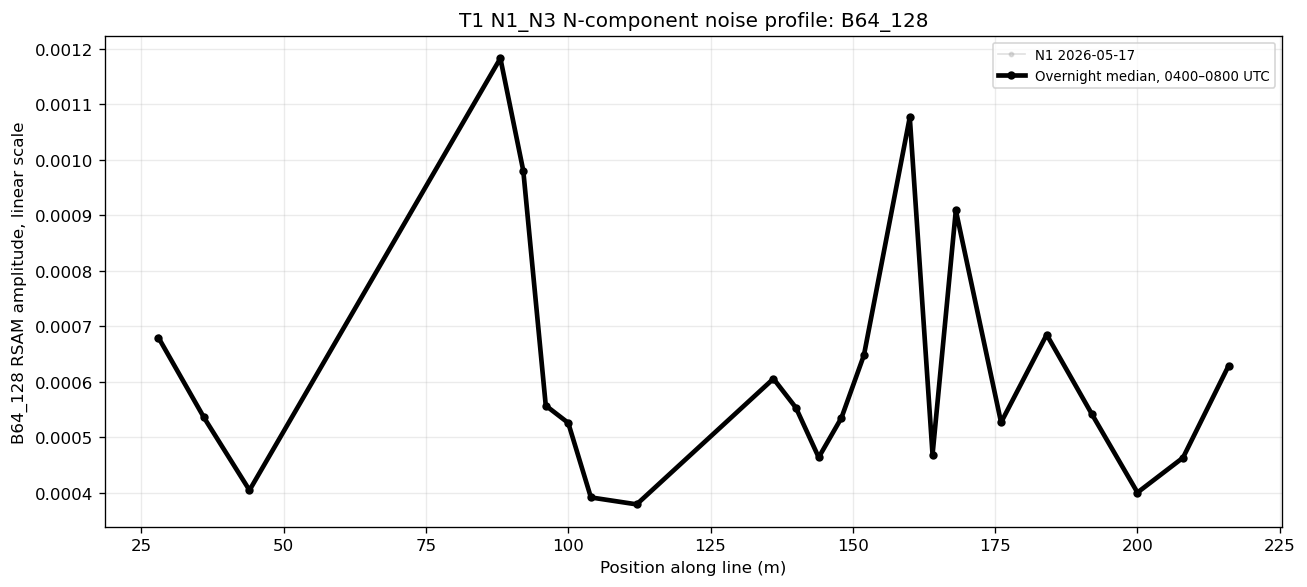

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_N_noise_profile_B64_128.png


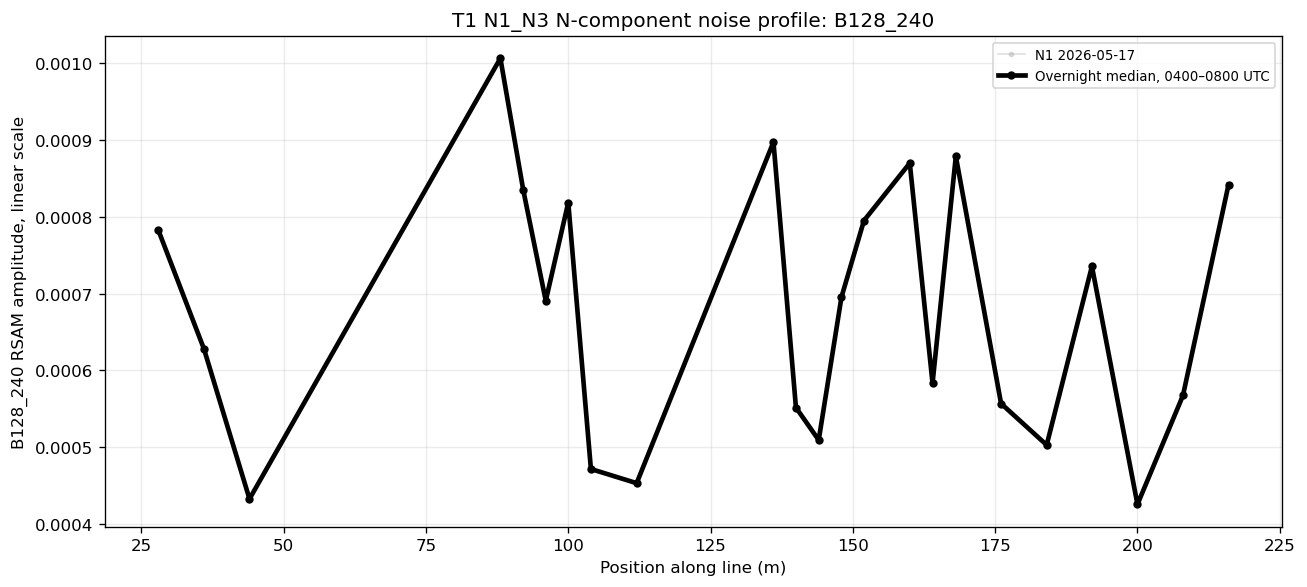

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_N_noise_profile_B128_240.png


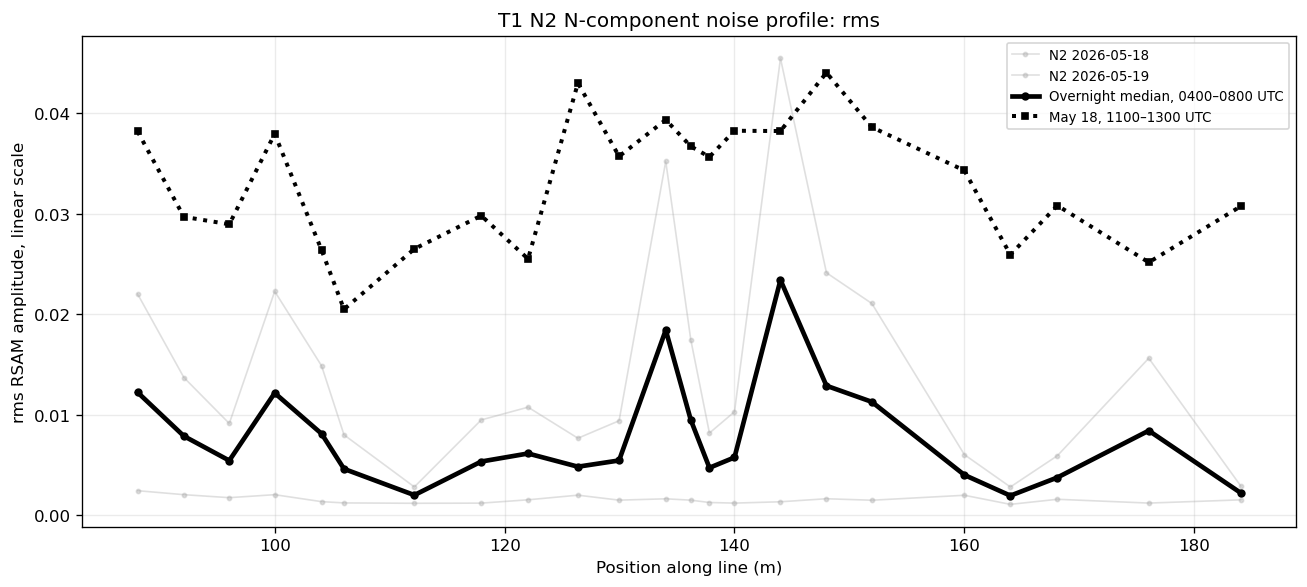

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_N_noise_profile_rms.png


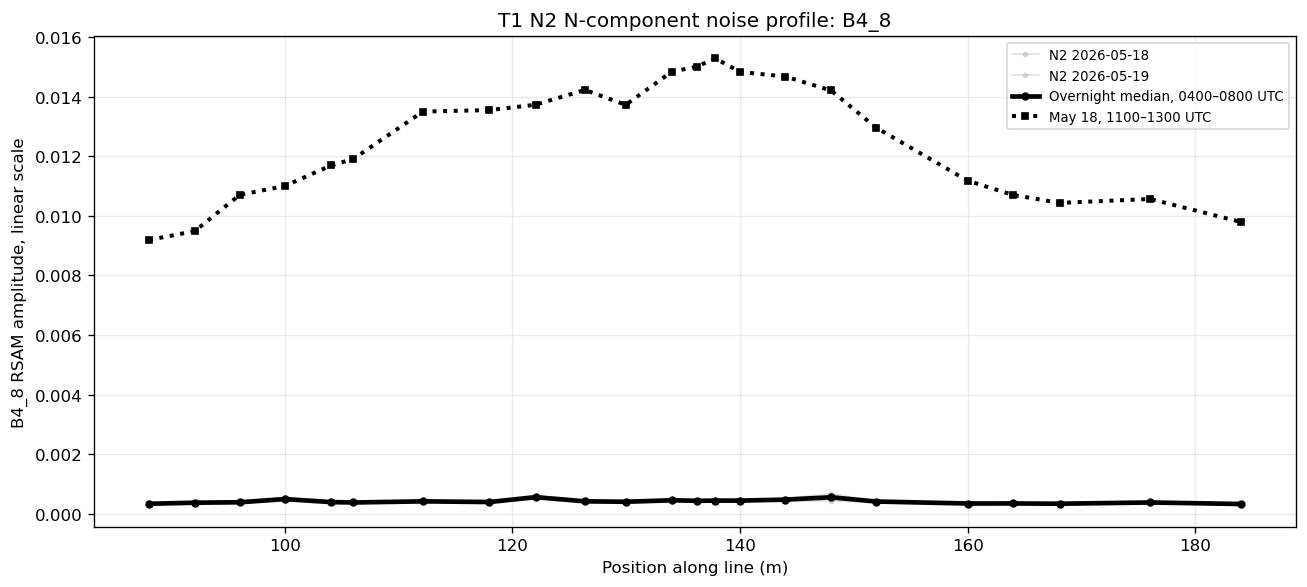

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_N_noise_profile_B4_8.png


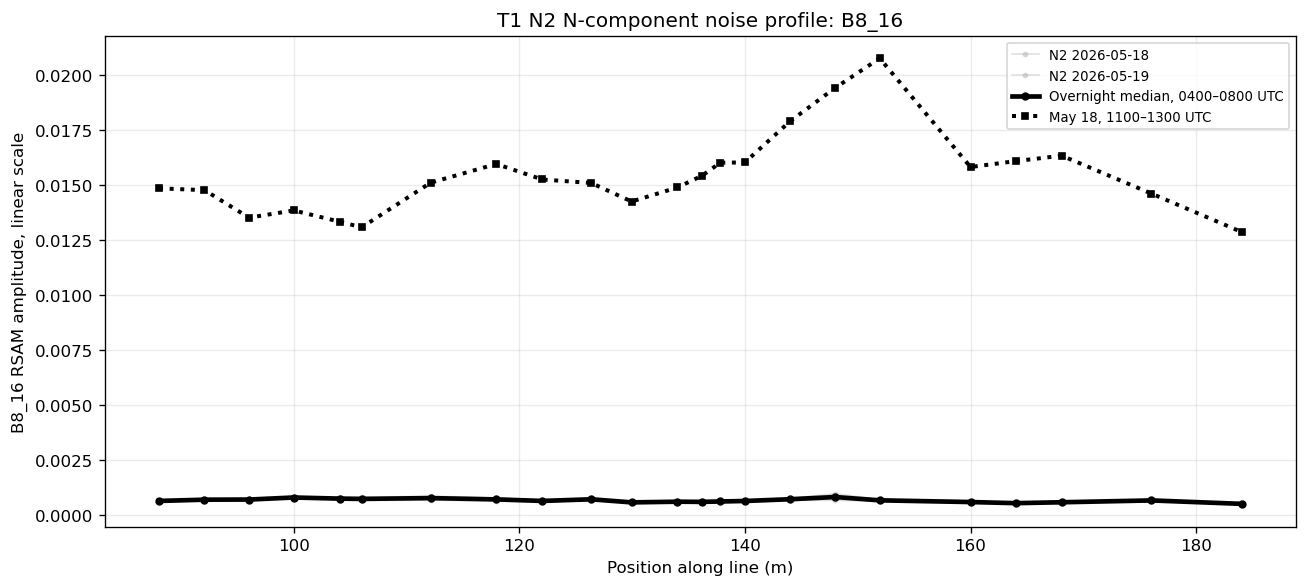

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_N_noise_profile_B8_16.png


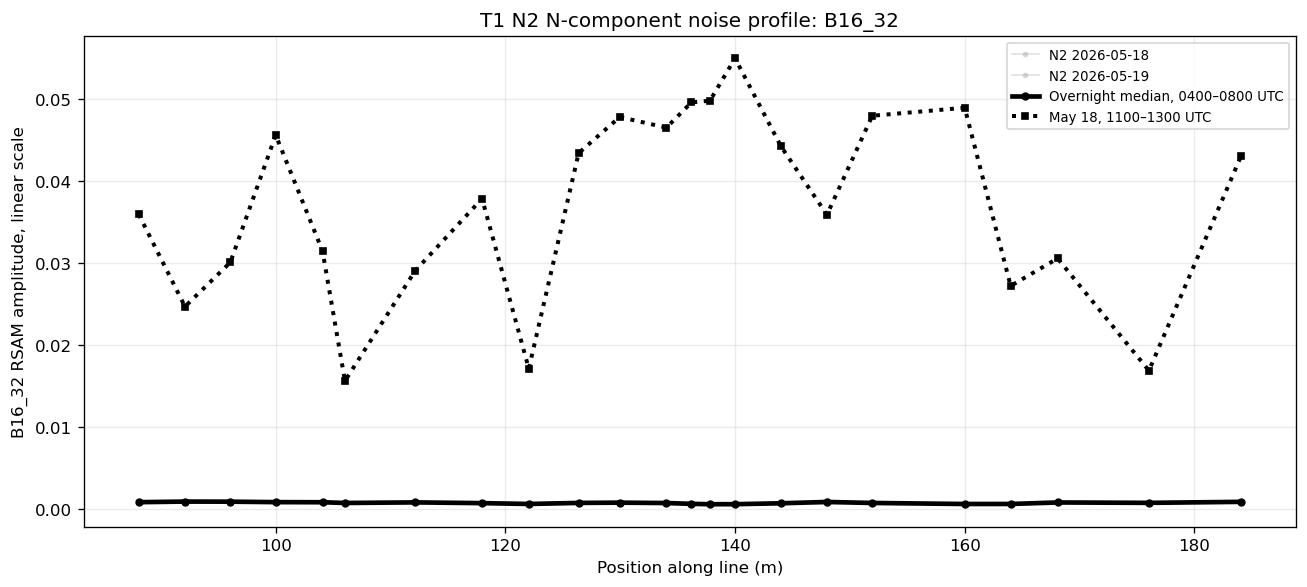

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_N_noise_profile_B16_32.png


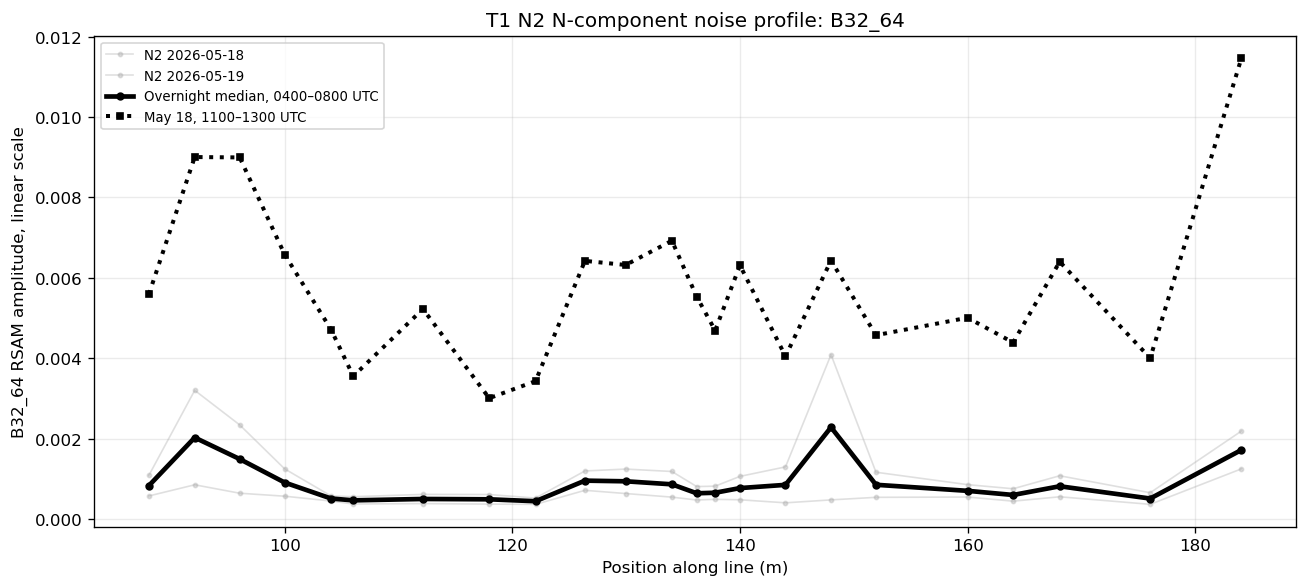

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_N_noise_profile_B32_64.png


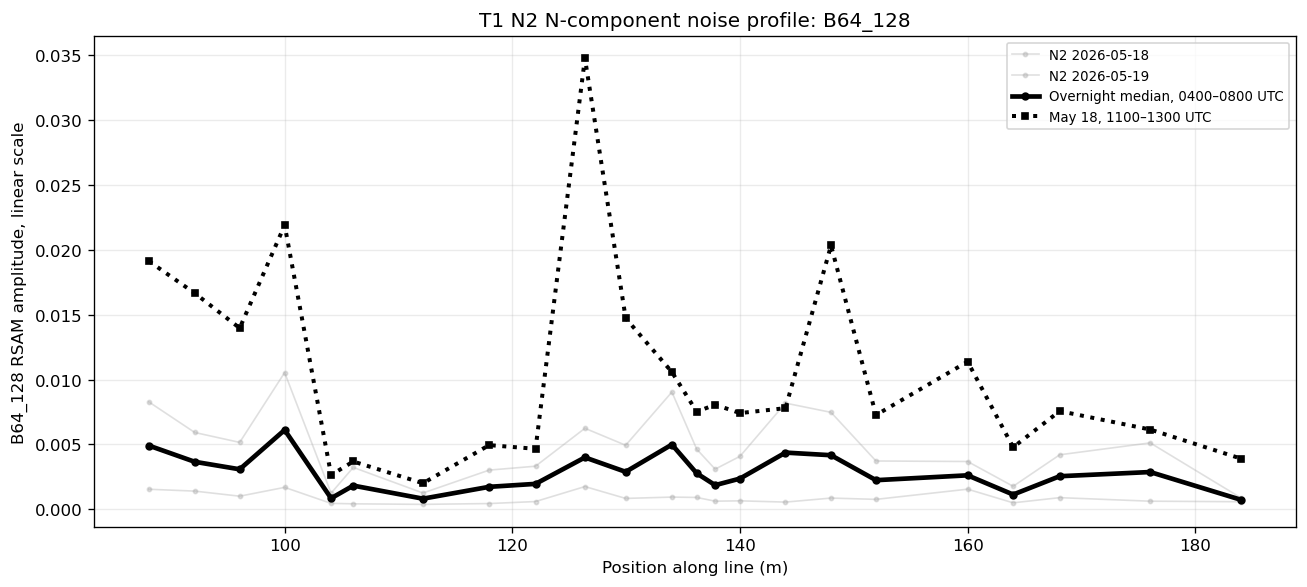

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_N_noise_profile_B64_128.png


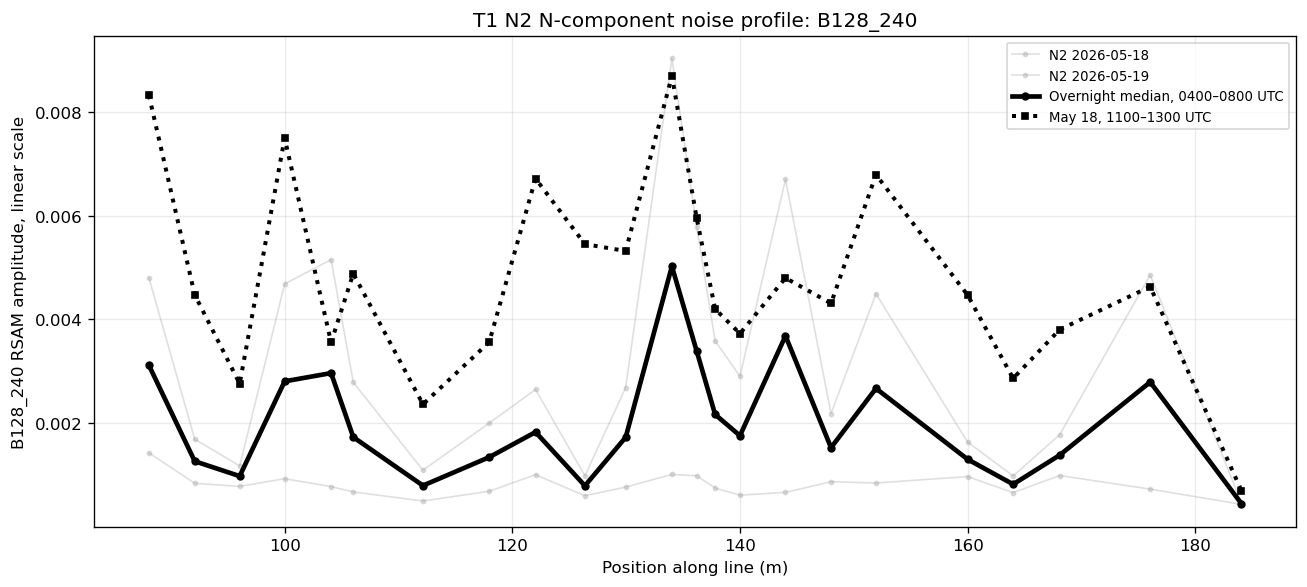

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_N_noise_profile_B128_240.png


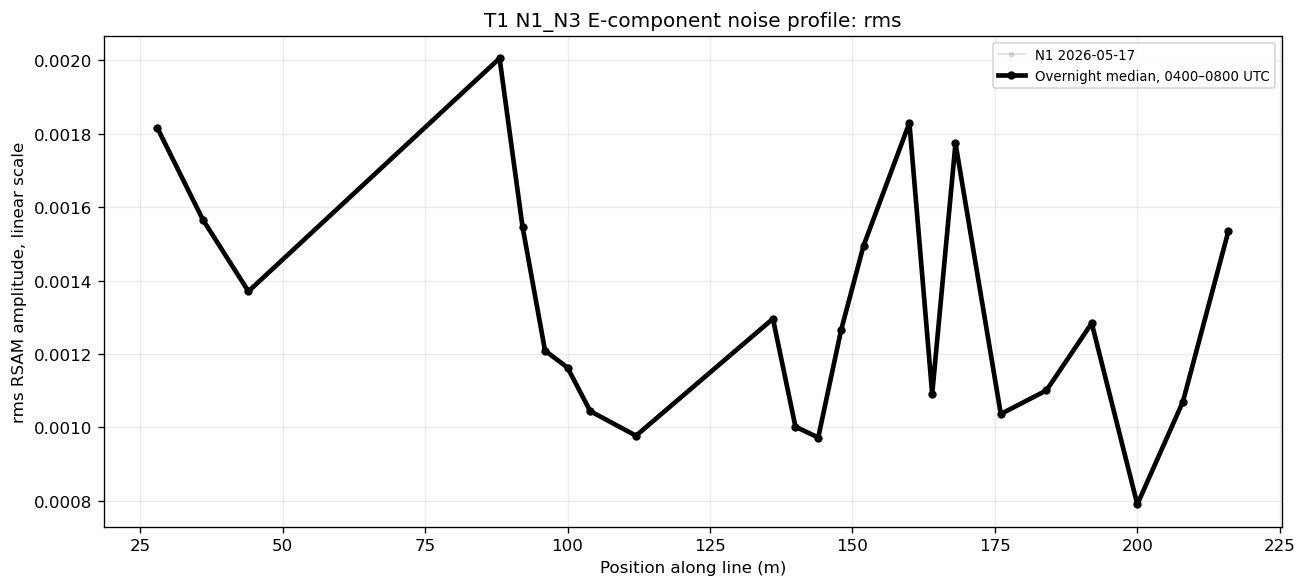

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_E_noise_profile_rms.png


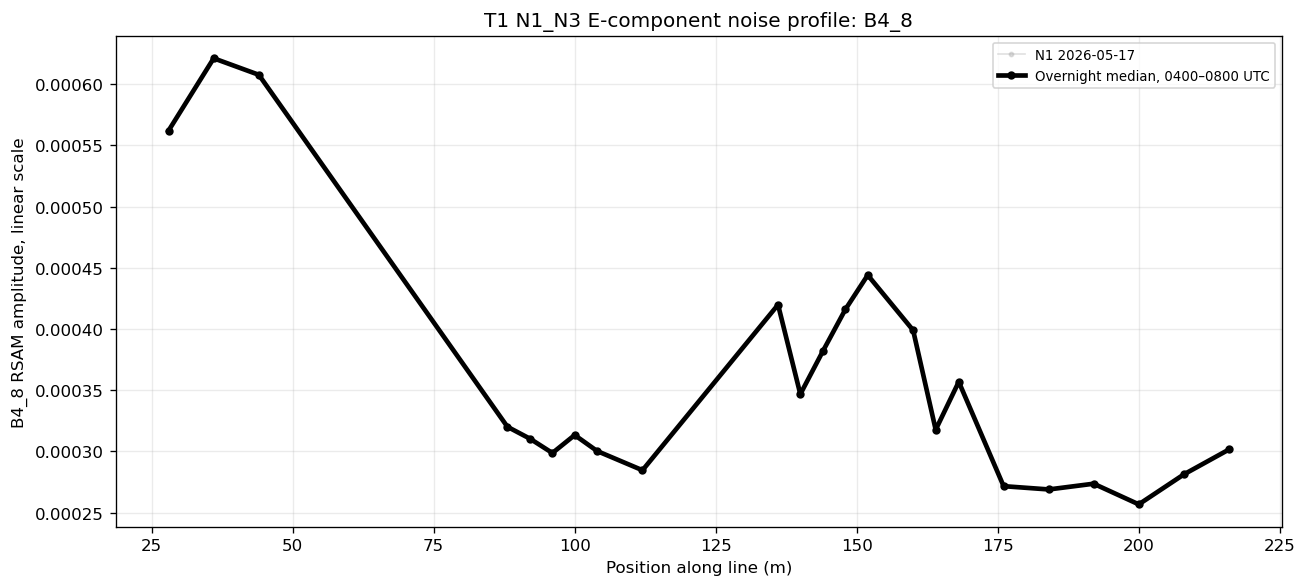

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_E_noise_profile_B4_8.png


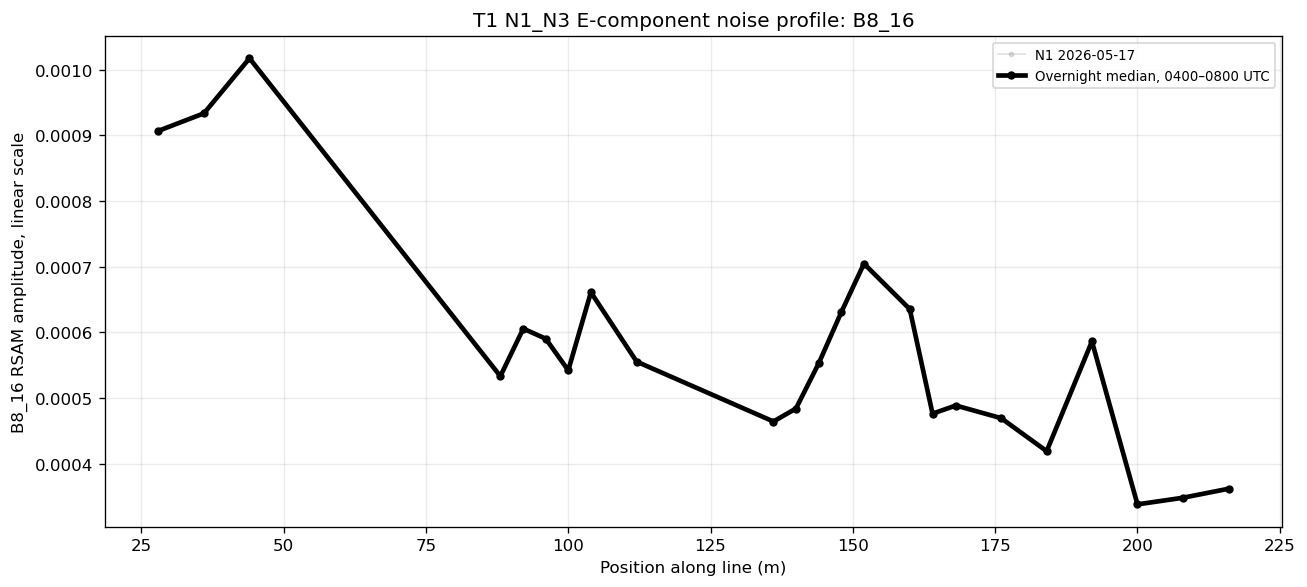

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_E_noise_profile_B8_16.png


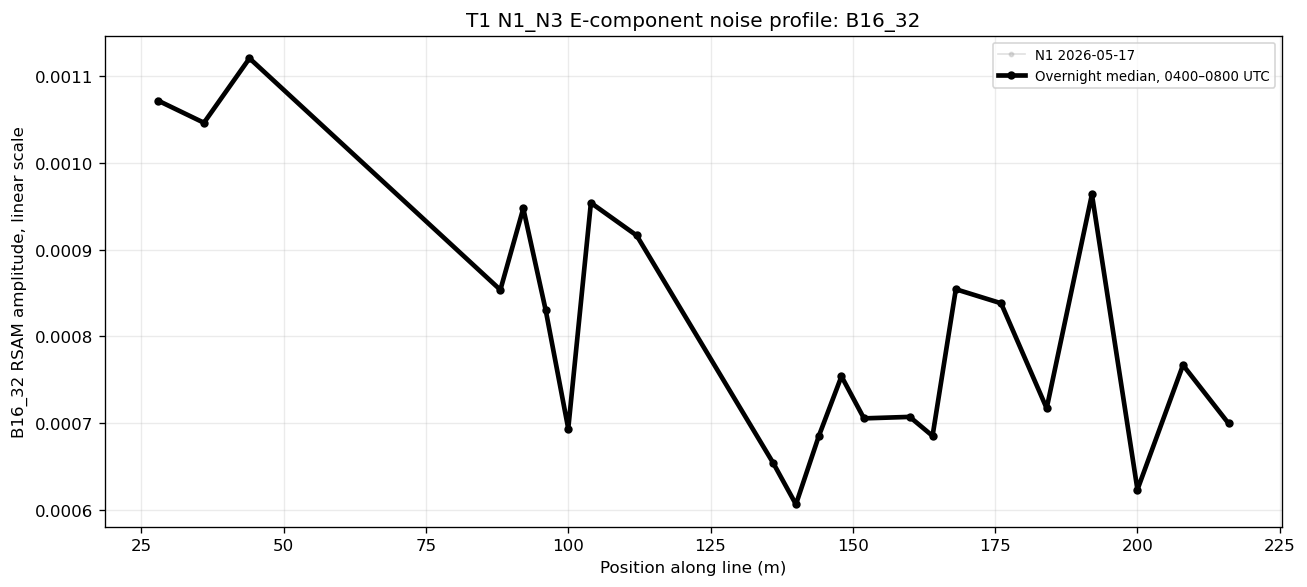

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_E_noise_profile_B16_32.png


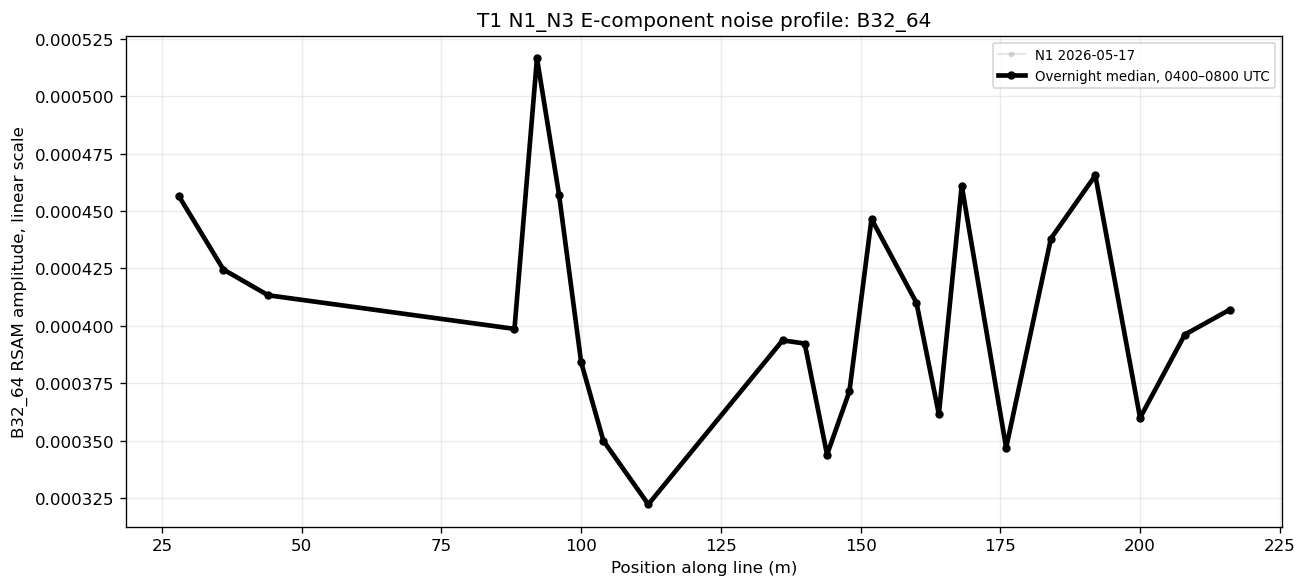

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_E_noise_profile_B32_64.png


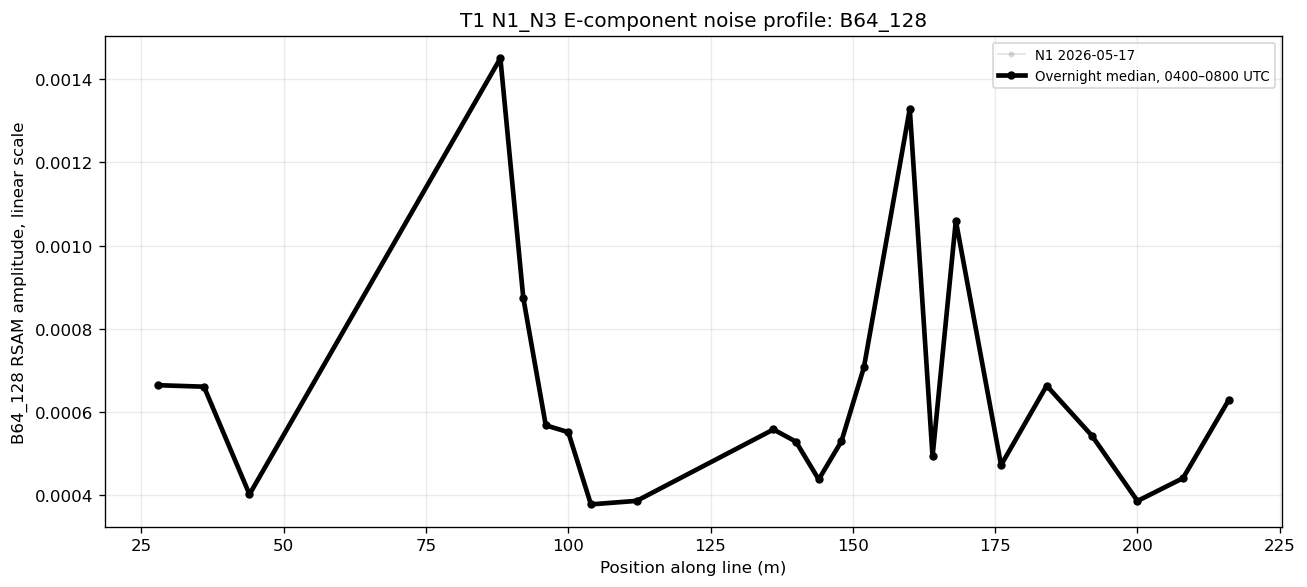

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_E_noise_profile_B64_128.png


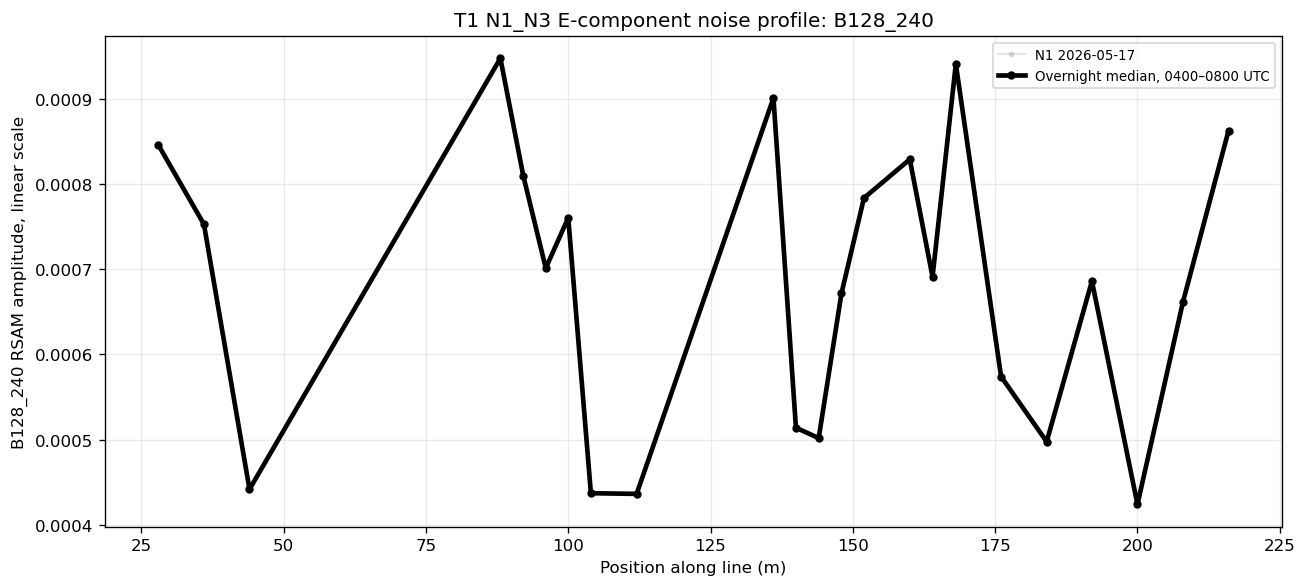

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N1_N3_E_noise_profile_B128_240.png


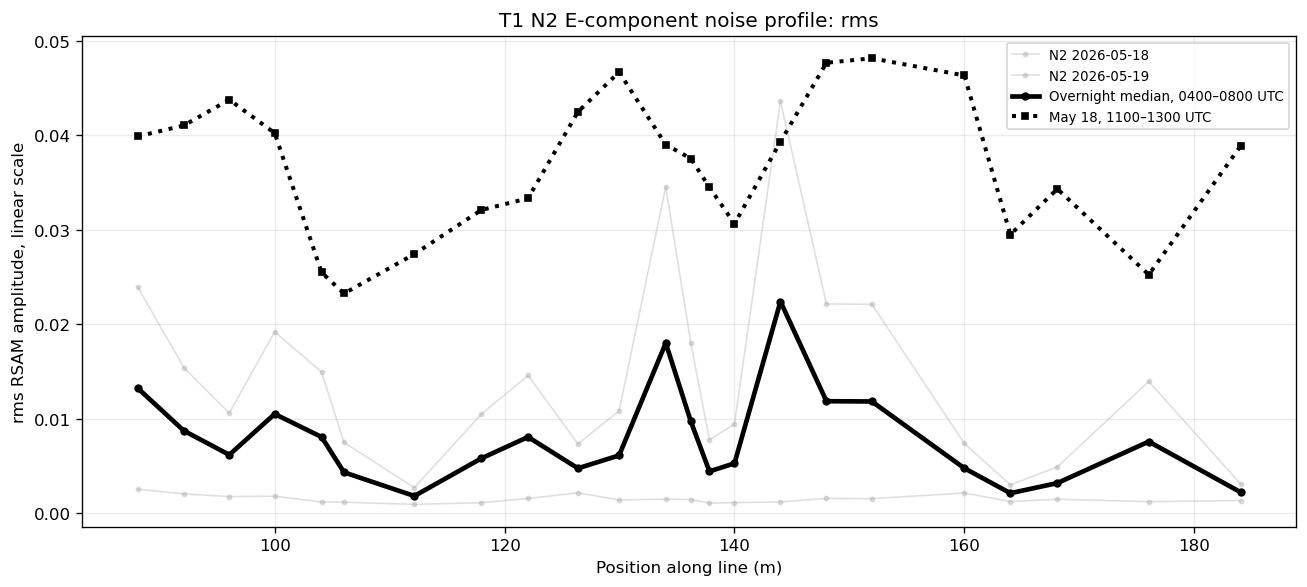

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_E_noise_profile_rms.png


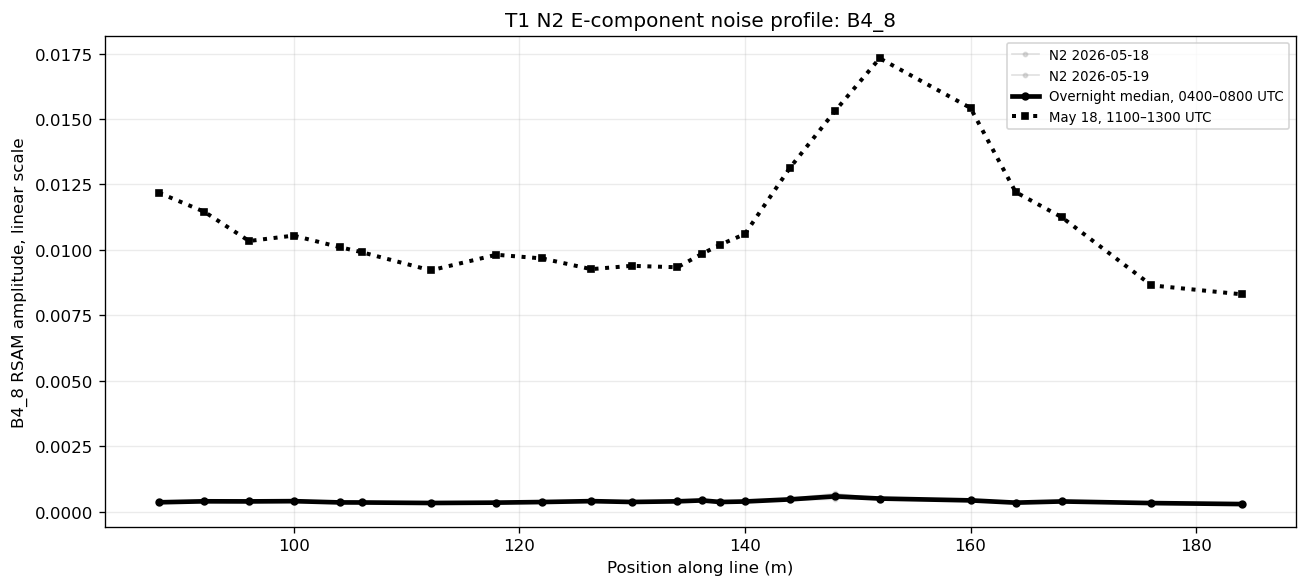

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_E_noise_profile_B4_8.png


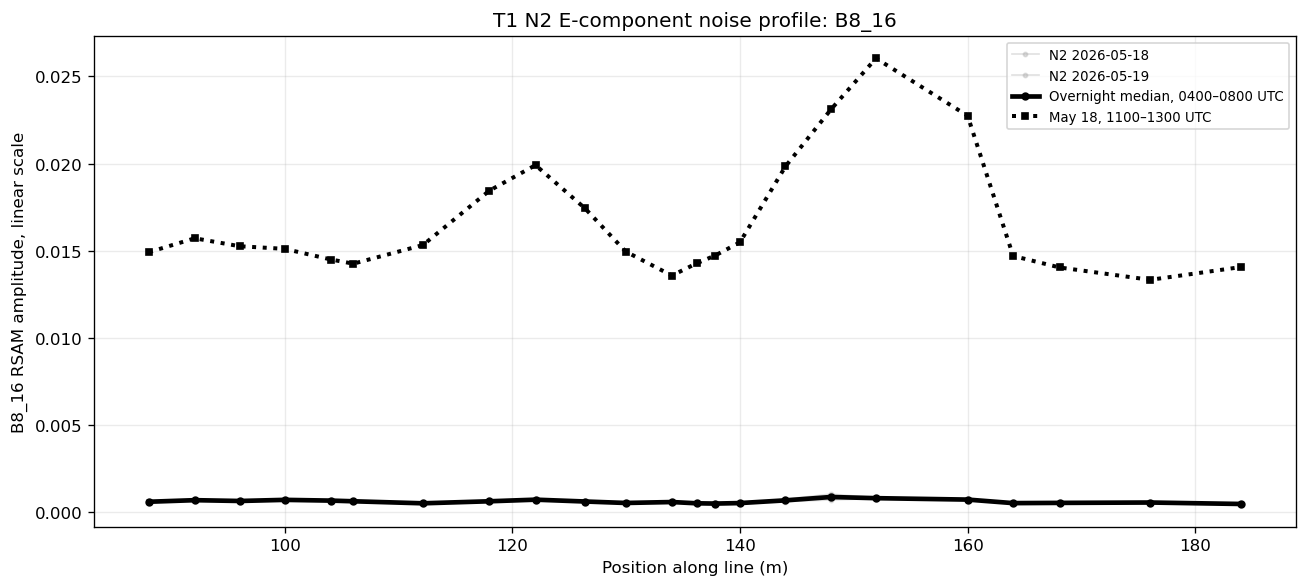

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_E_noise_profile_B8_16.png


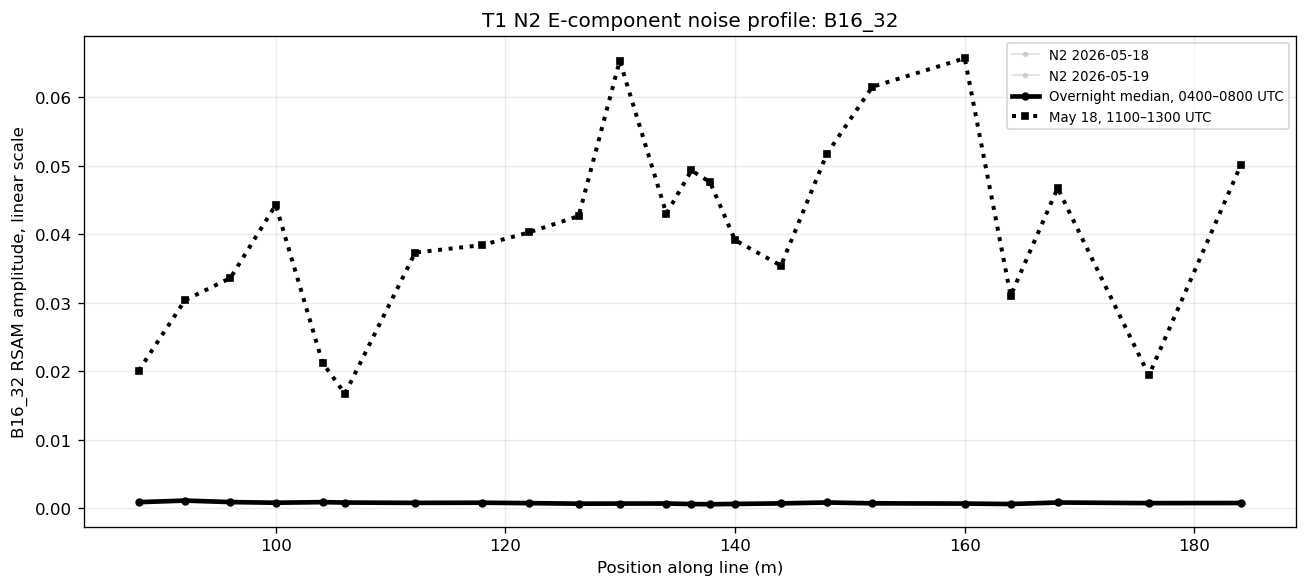

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_E_noise_profile_B16_32.png


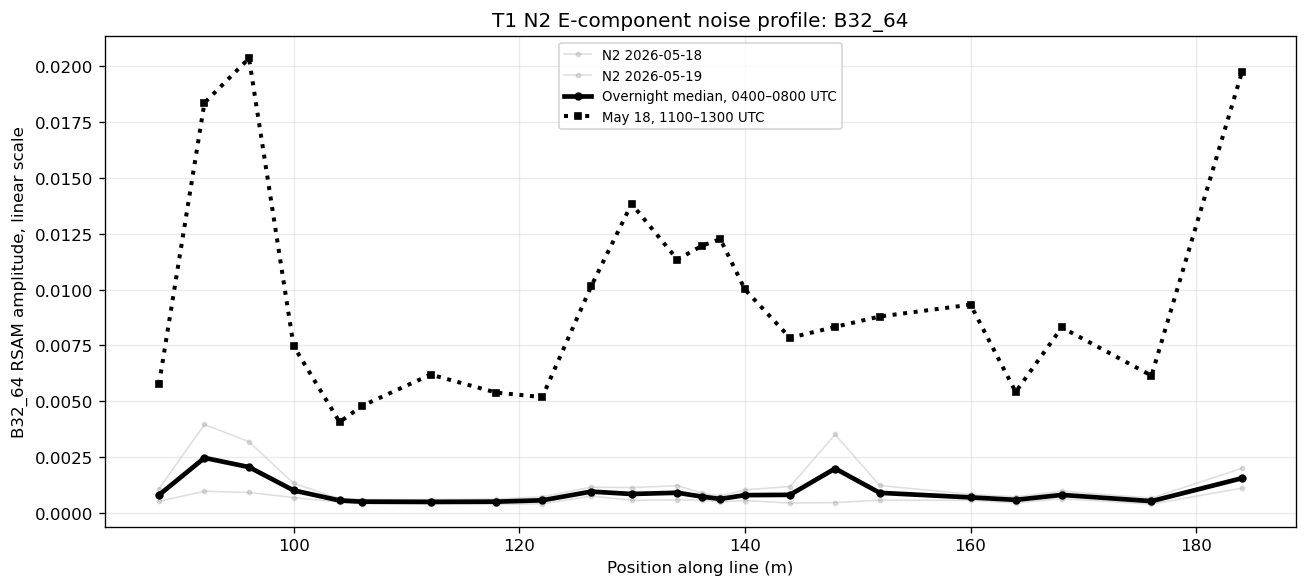

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_E_noise_profile_B32_64.png


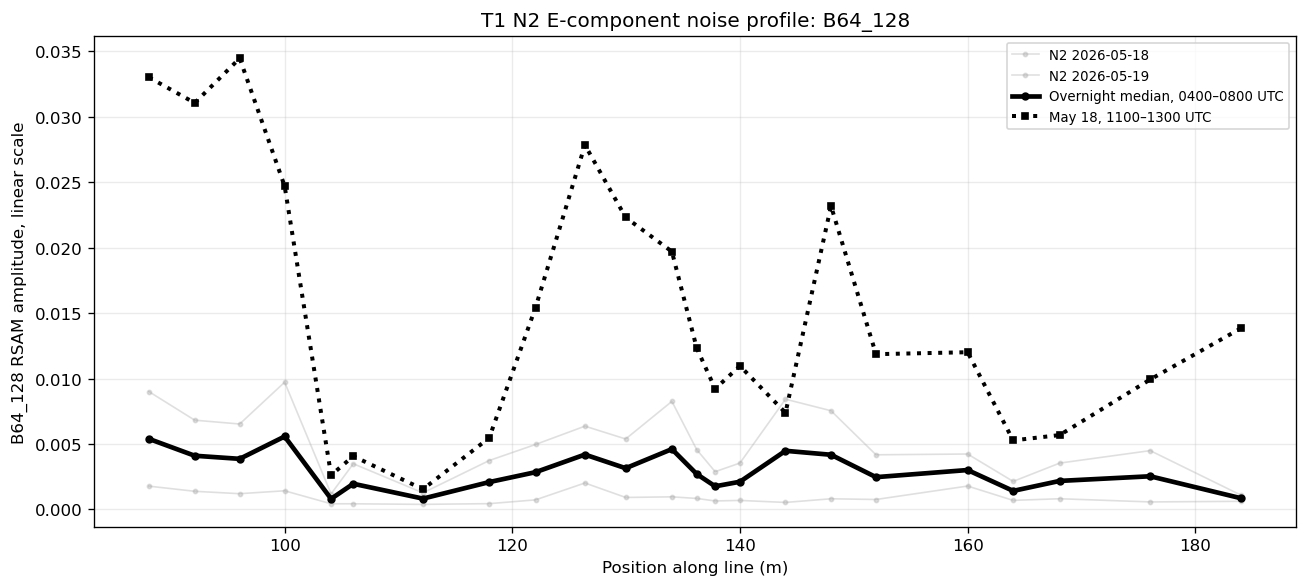

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_E_noise_profile_B64_128.png


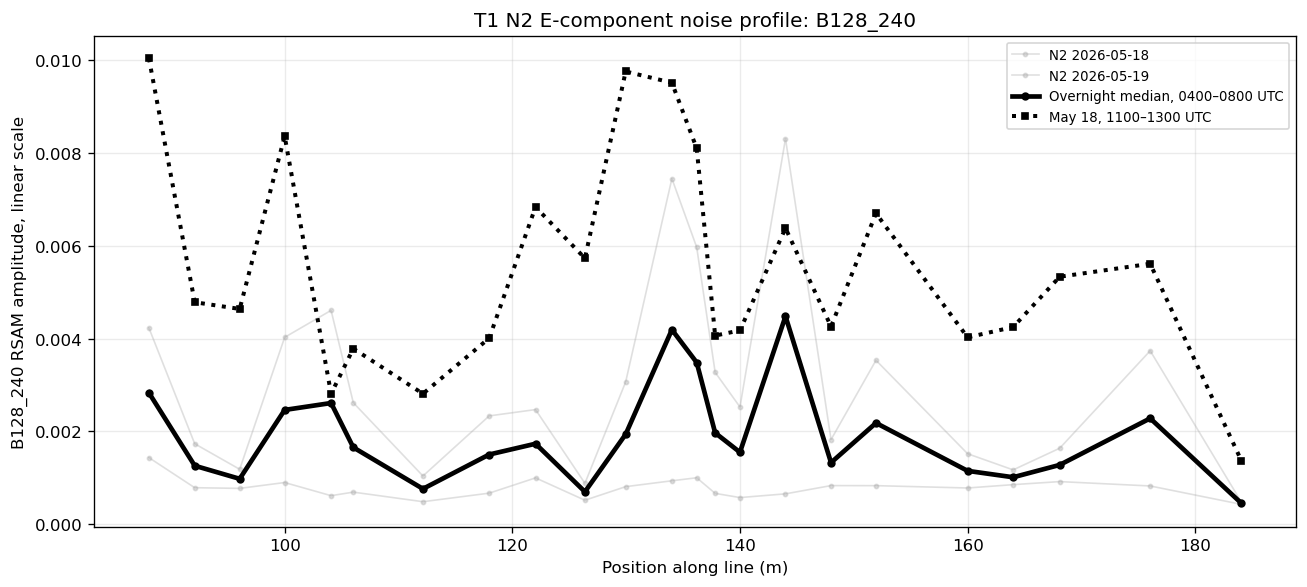

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N2_E_noise_profile_B128_240.png
No data for T3 Z N1_N3 rms
No data for T3 Z N1_N3 B4_8
No data for T3 Z N1_N3 B8_16
No data for T3 Z N1_N3 B16_32
No data for T3 Z N1_N3 B32_64
No data for T3 Z N1_N3 B64_128
No data for T3 Z N1_N3 B128_240
No data for T3 Z N2 rms
No data for T3 Z N2 B4_8
No data for T3 Z N2 B8_16
No data for T3 Z N2 B16_32
No data for T3 Z N2 B32_64
No data for T3 Z N2 B64_128
No data for T3 Z N2 B128_240
No data for T3 N N1_N3 rms
No data for T3 N N1_N3 B4_8
No data for T3 N N1_N3 B8_16
No data for T3 N N1_N3 B16_32
No data for T3 N N1_N3 B32_64
No data for T3 N N1_N3 B64_128
No data for T3 N N1_N3 B128_240
No data for T3 N N2 rms
No data for T3 N N2 B4_8
No data for T3 N N2 B8_16
No data for T3 N N2 B16_32
No data for T3 N N2 B32_64
No data for T3 N N2 B64_128
No data for T3 N N2 B128_240
No data for T3 E N1_N3 rms
No data for T3 E N1_N3 B4_8
No data for T3 E N1_N3 B8_16
No data for T3 E N1_N3 B16_32
No data

In [8]:
plot_files = []

for network in NETWORKS:
    for component in ["Z", "N", "E"]:
        for plot_group_name, locations in PLOT_GROUPS.items():
            for band in BANDS:
                outfile = plot_noise_profile(summary, network, component, plot_group_name, locations, band)
                if outfile is not None:
                    plot_files.append(outfile)

print(f"Generated {len(plot_files)} per-group plot files")

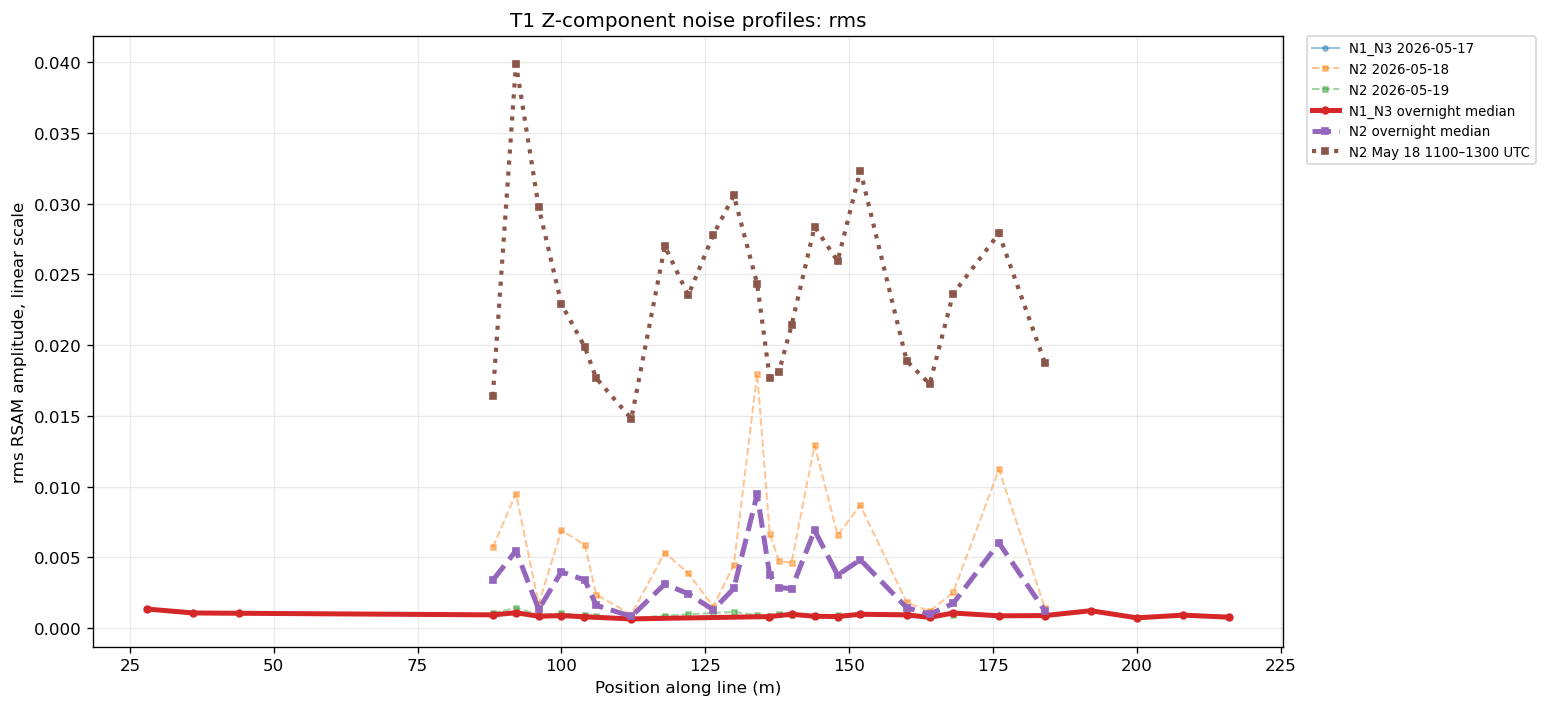

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_Z_noise_profile_rms.png


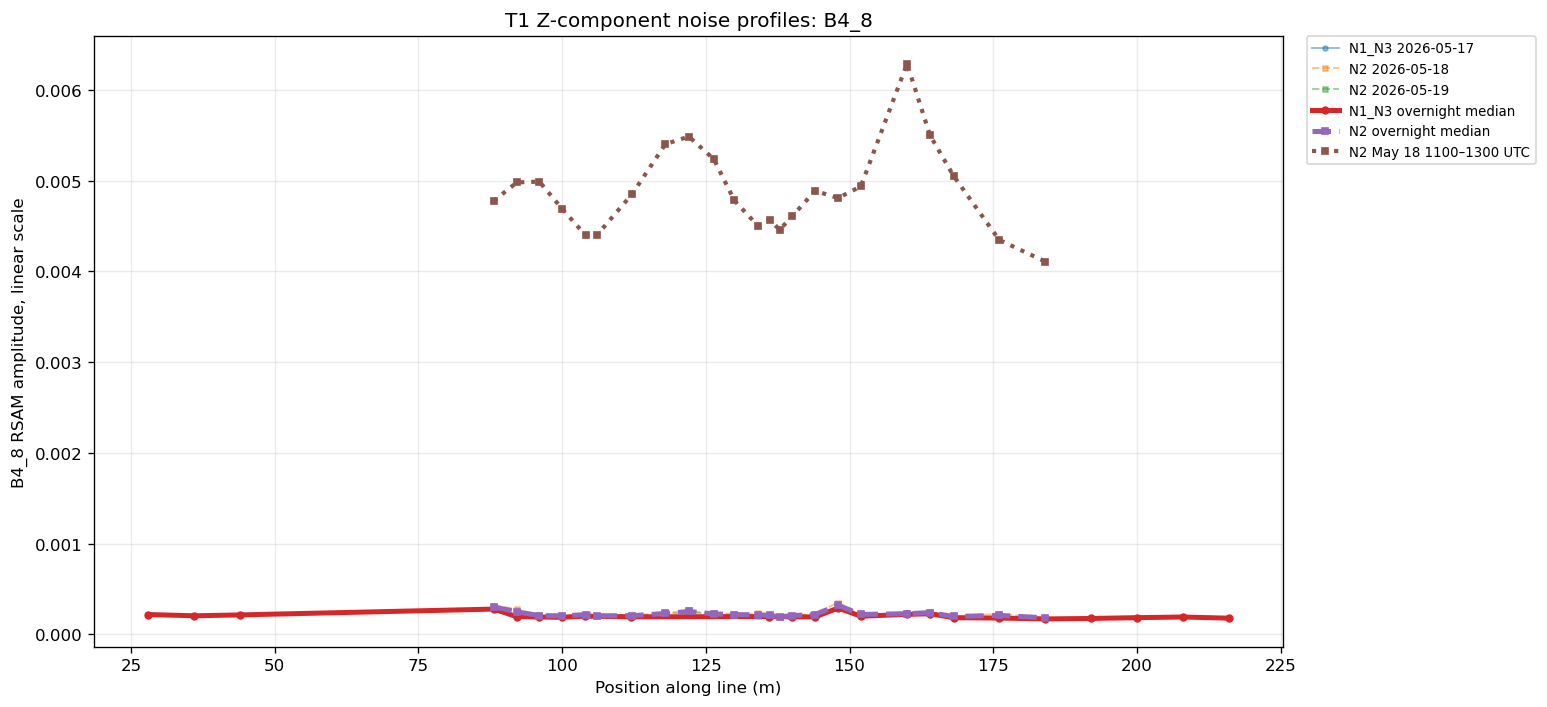

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_Z_noise_profile_B4_8.png


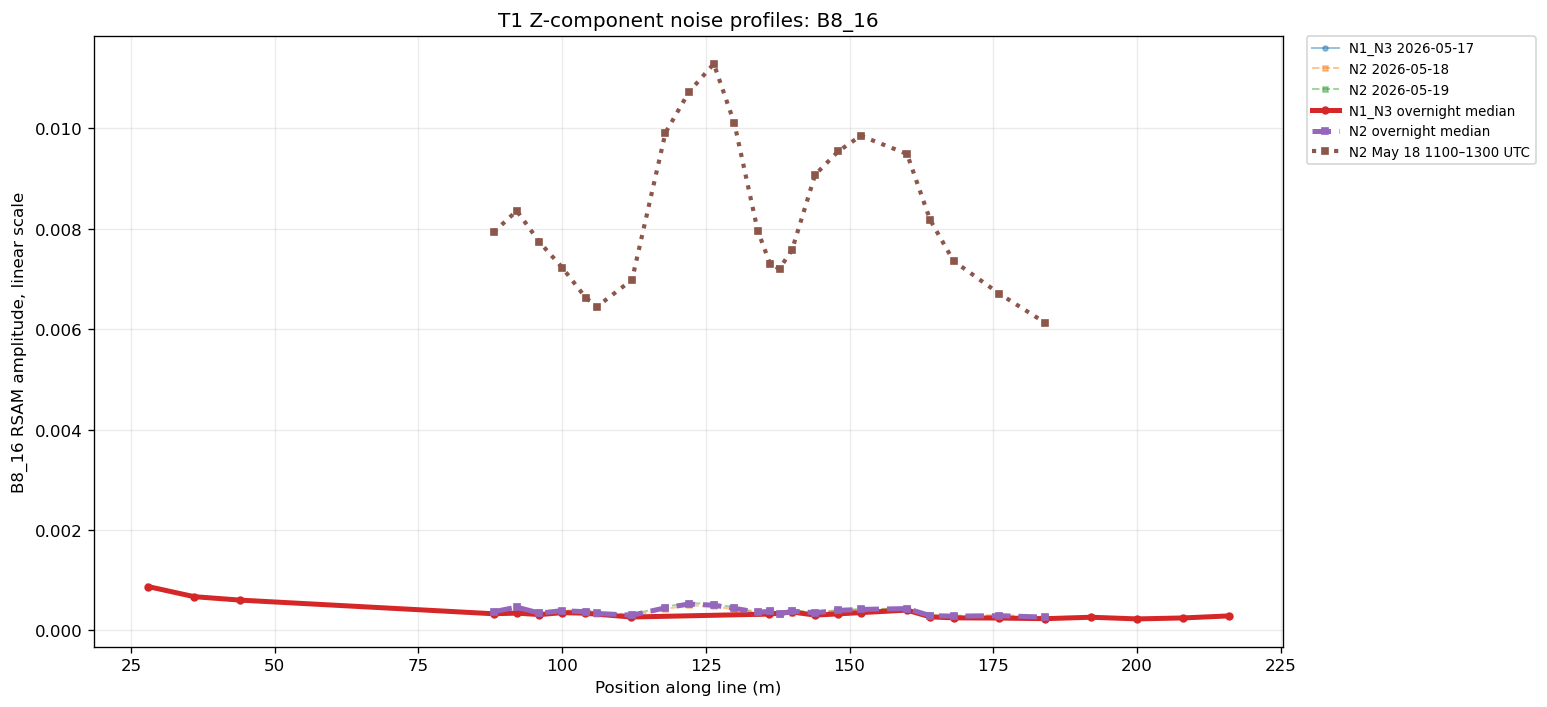

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_Z_noise_profile_B8_16.png


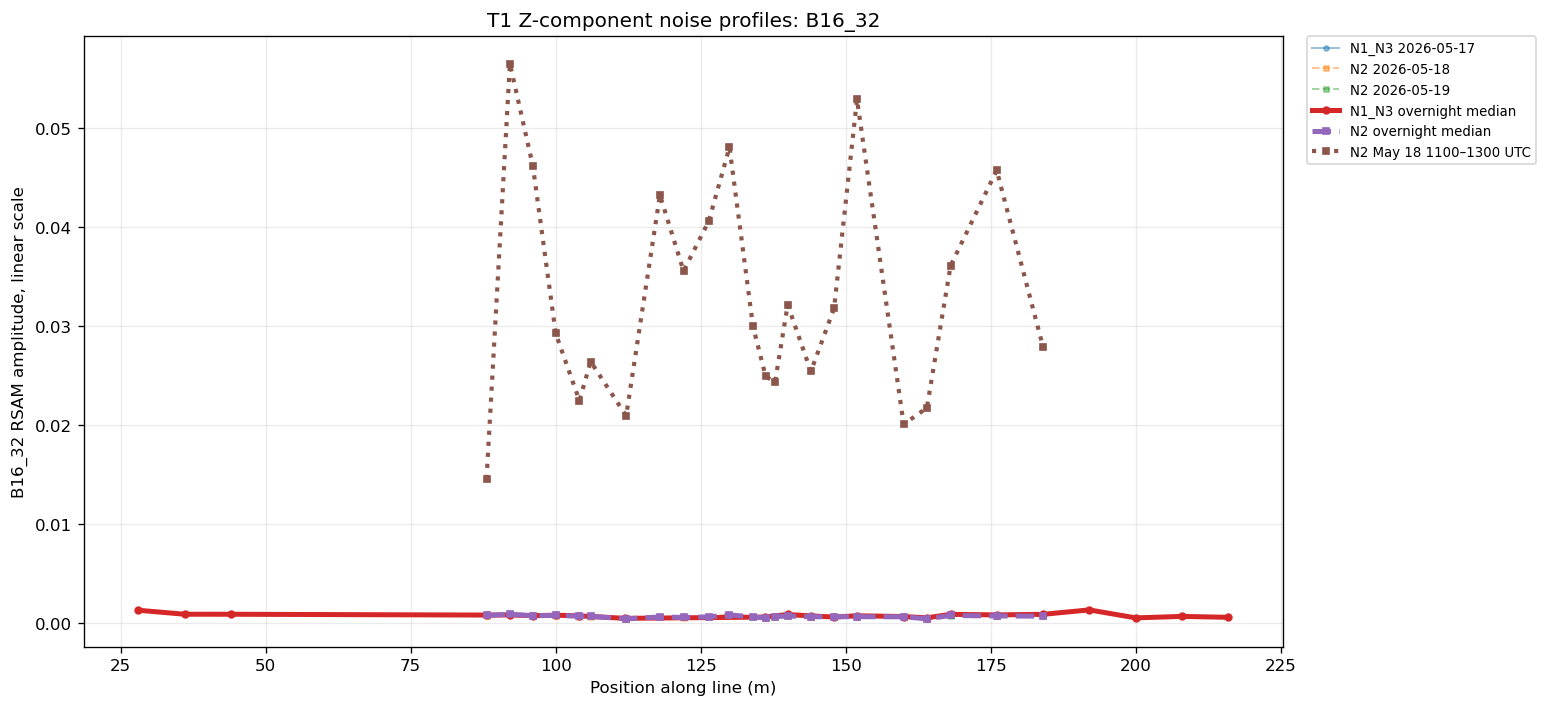

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_Z_noise_profile_B16_32.png


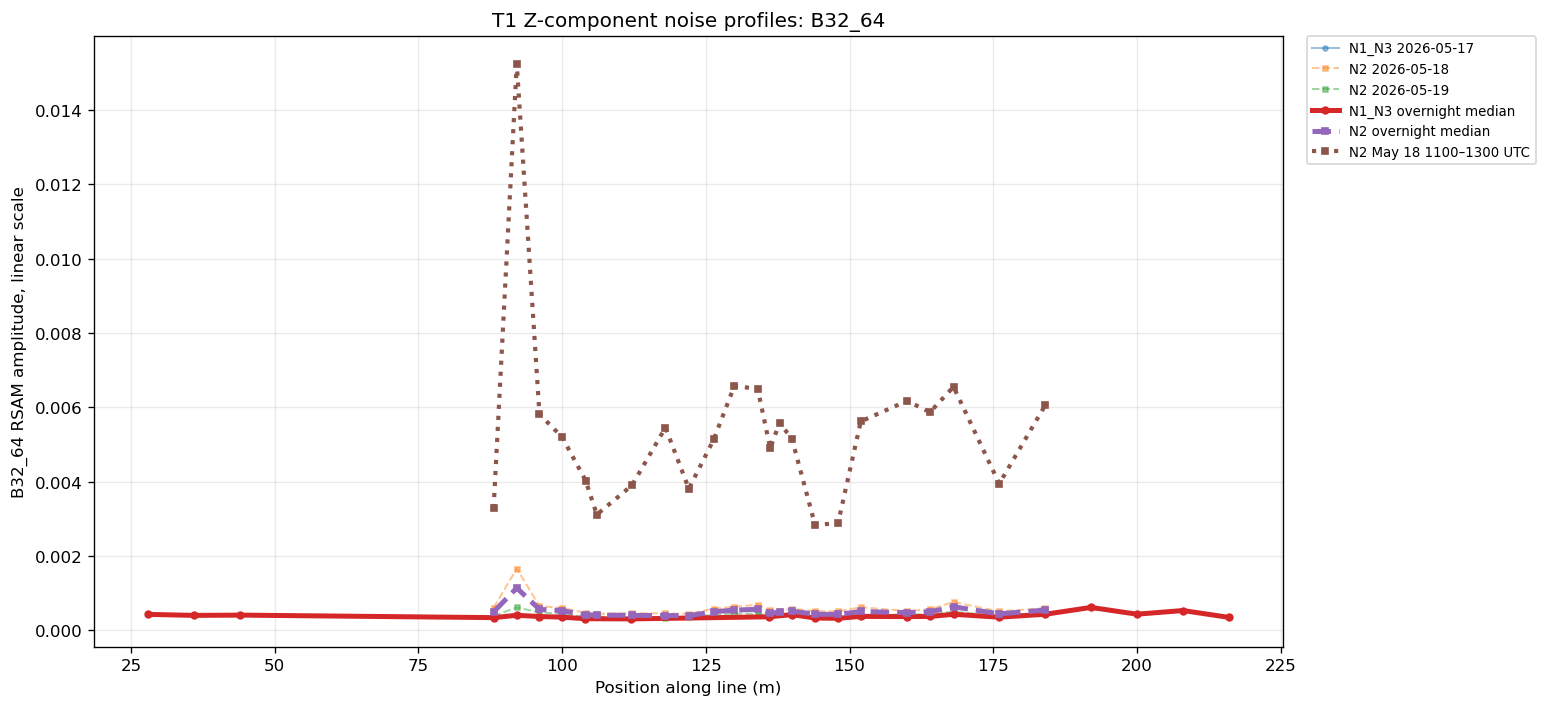

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_Z_noise_profile_B32_64.png


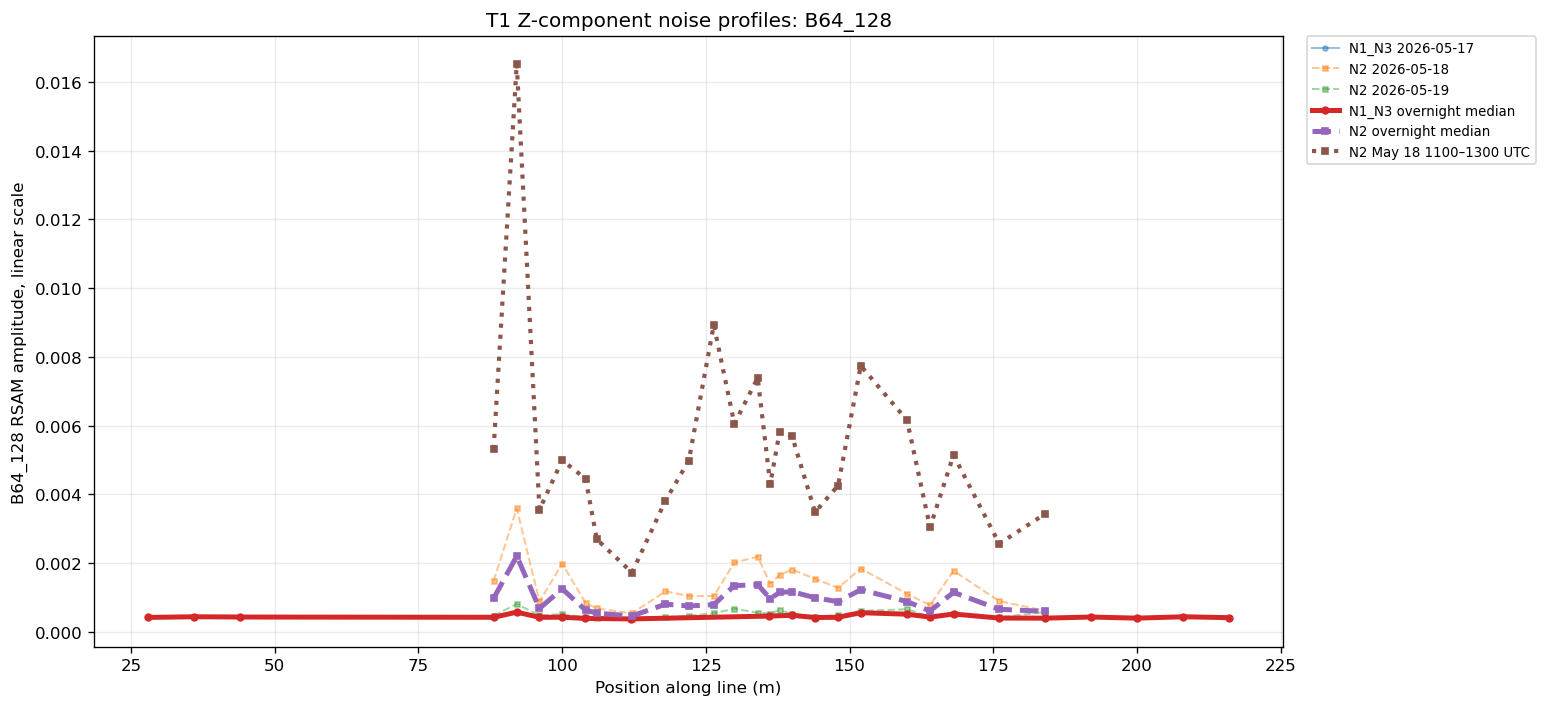

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_Z_noise_profile_B64_128.png


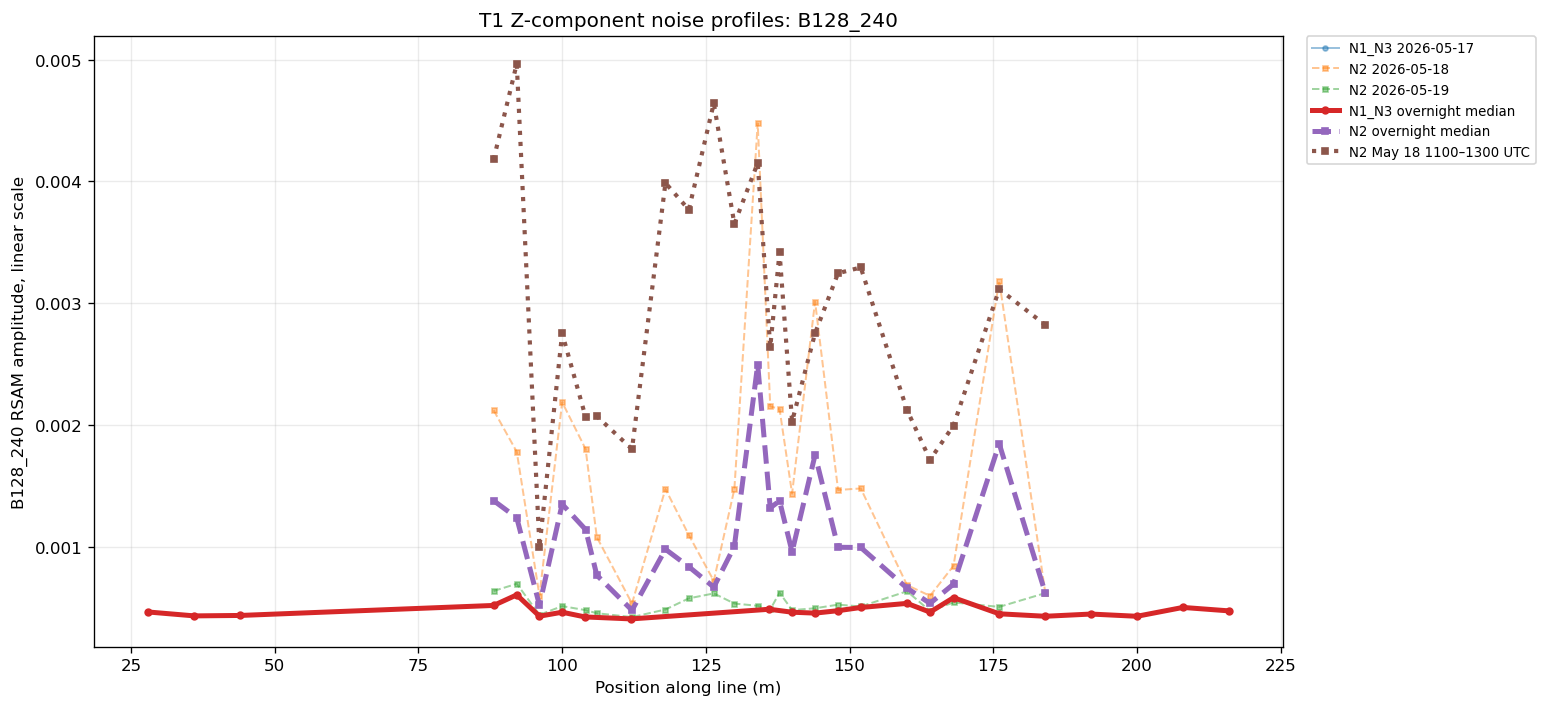

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_Z_noise_profile_B128_240.png


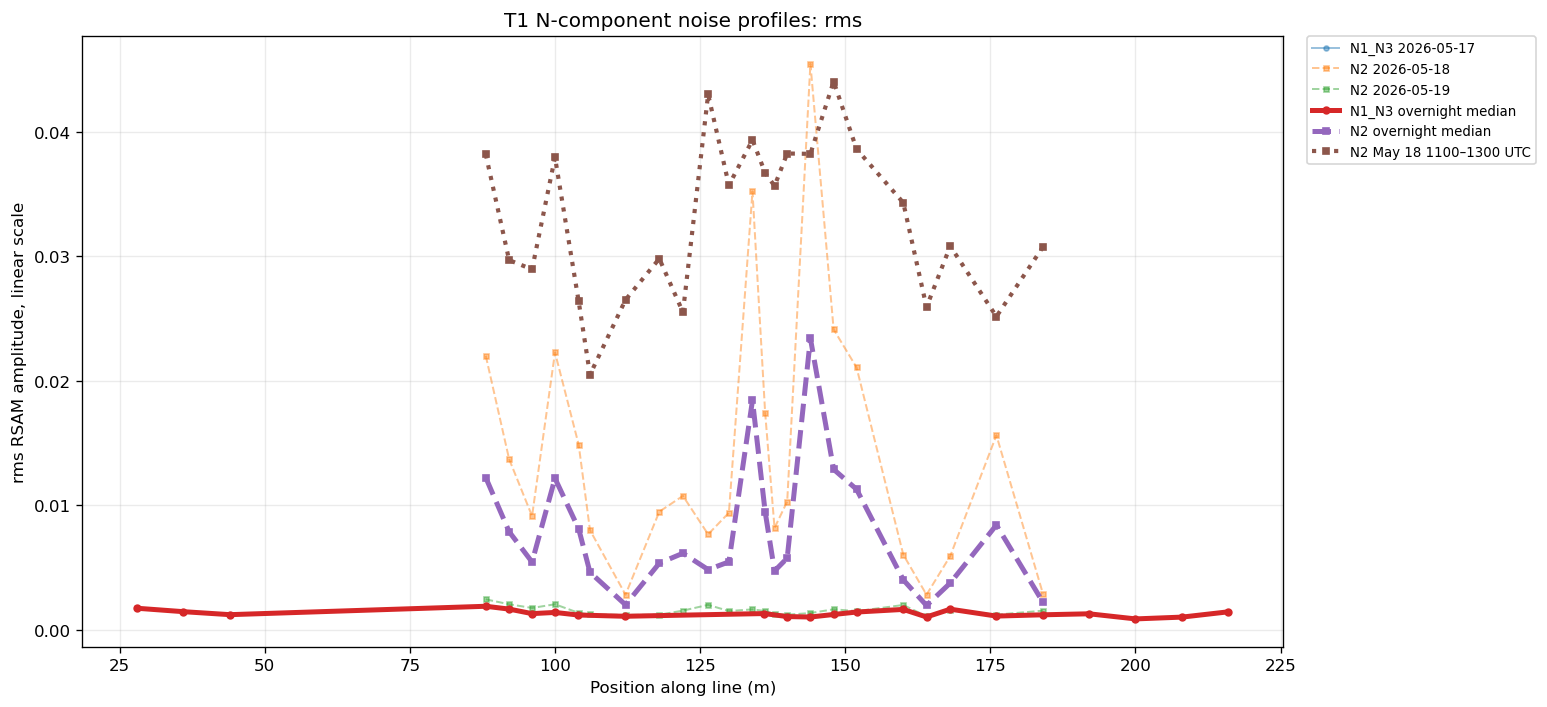

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_N_noise_profile_rms.png


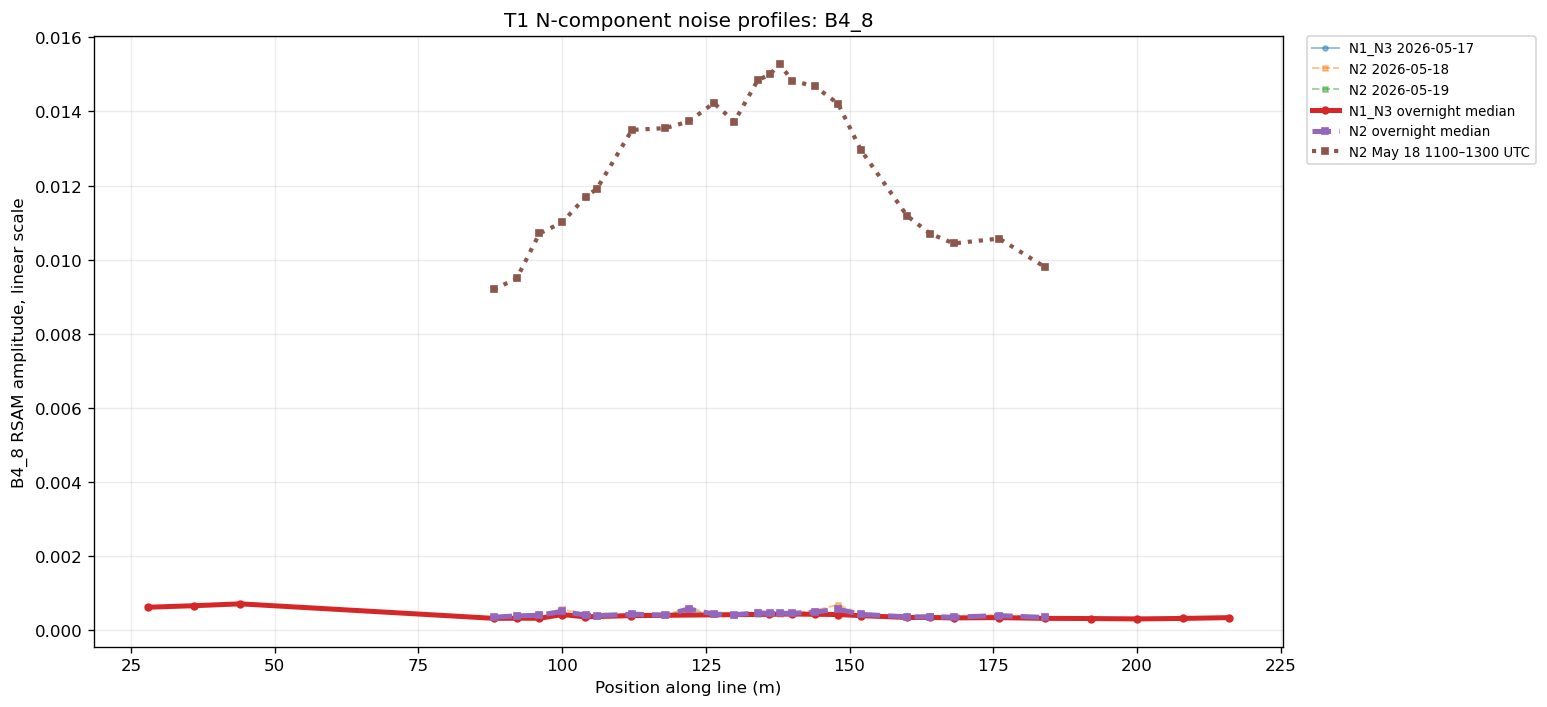

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_N_noise_profile_B4_8.png


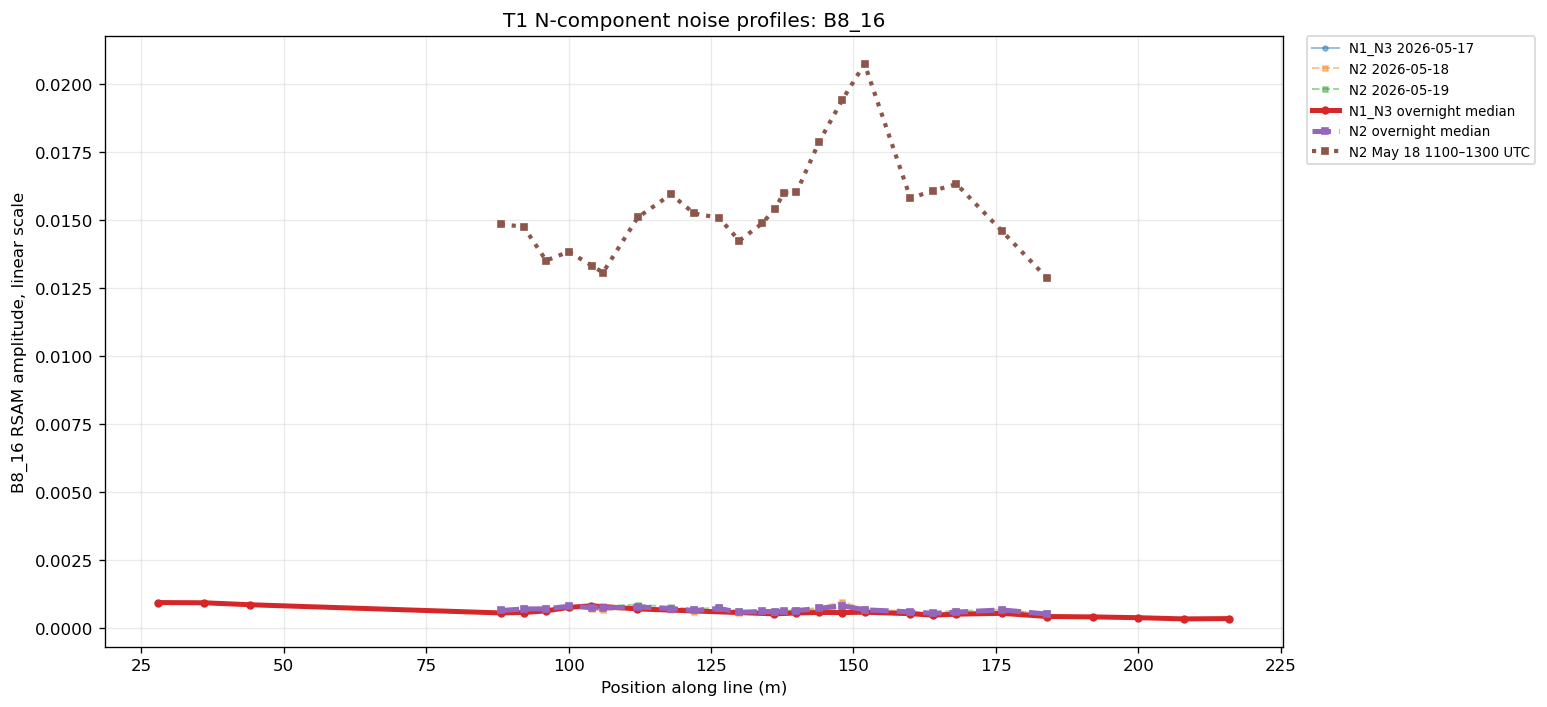

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_N_noise_profile_B8_16.png


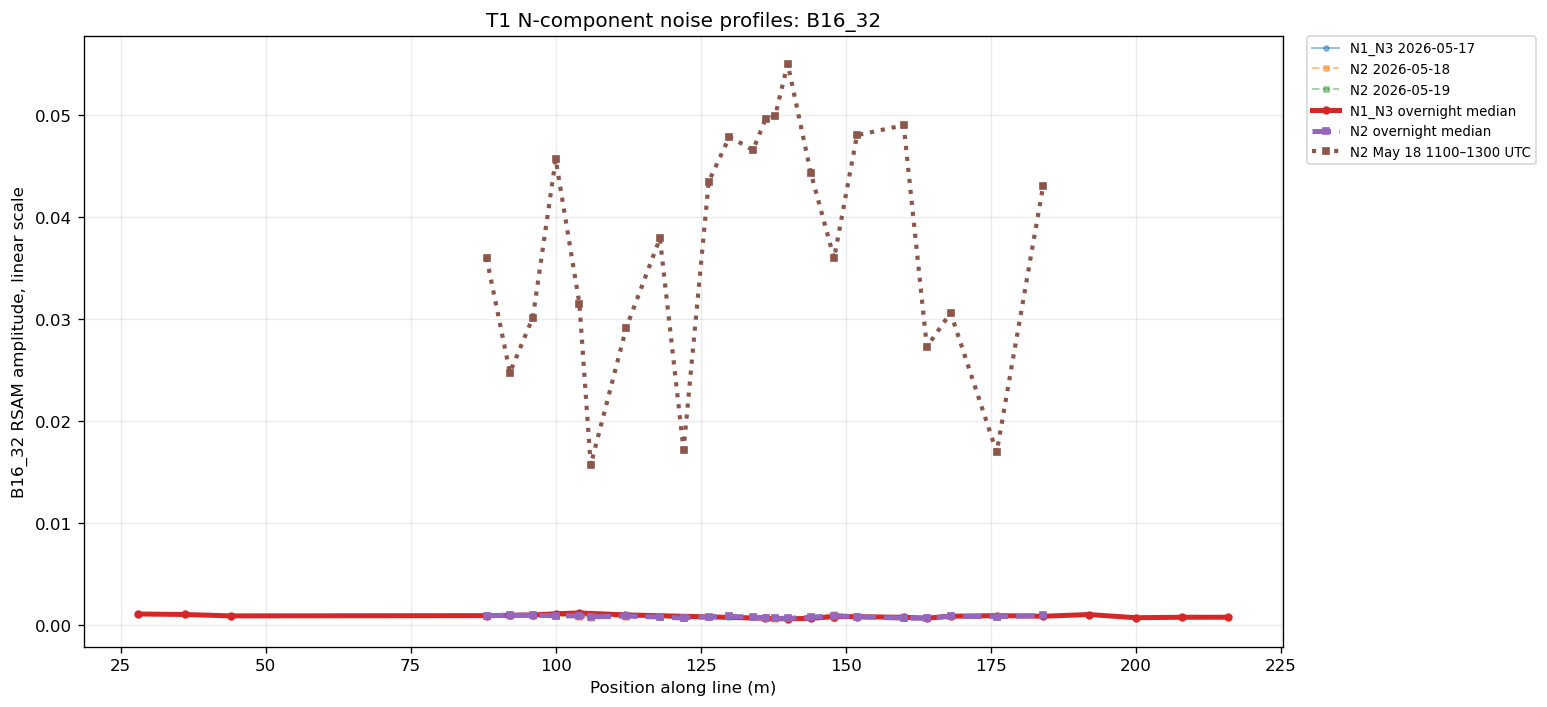

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_N_noise_profile_B16_32.png


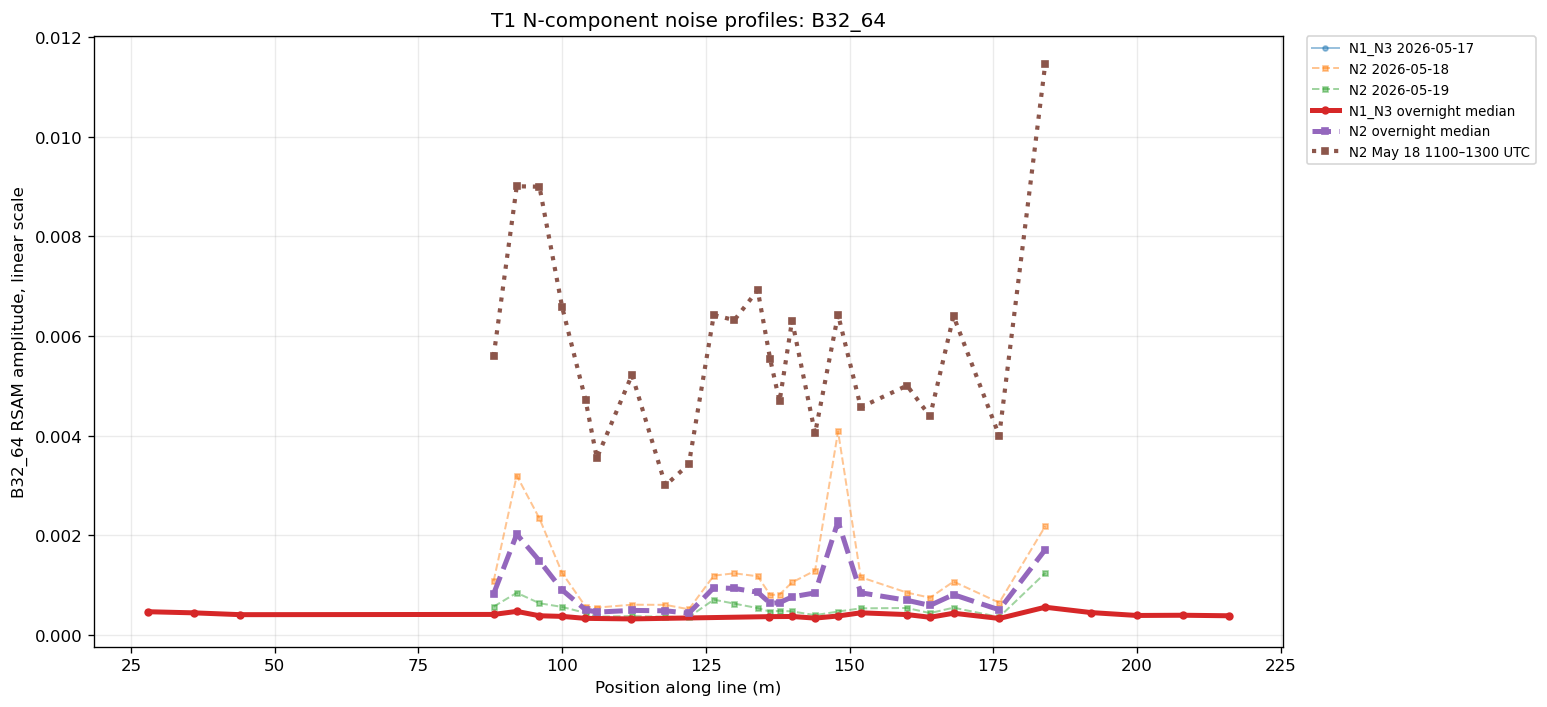

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_N_noise_profile_B32_64.png


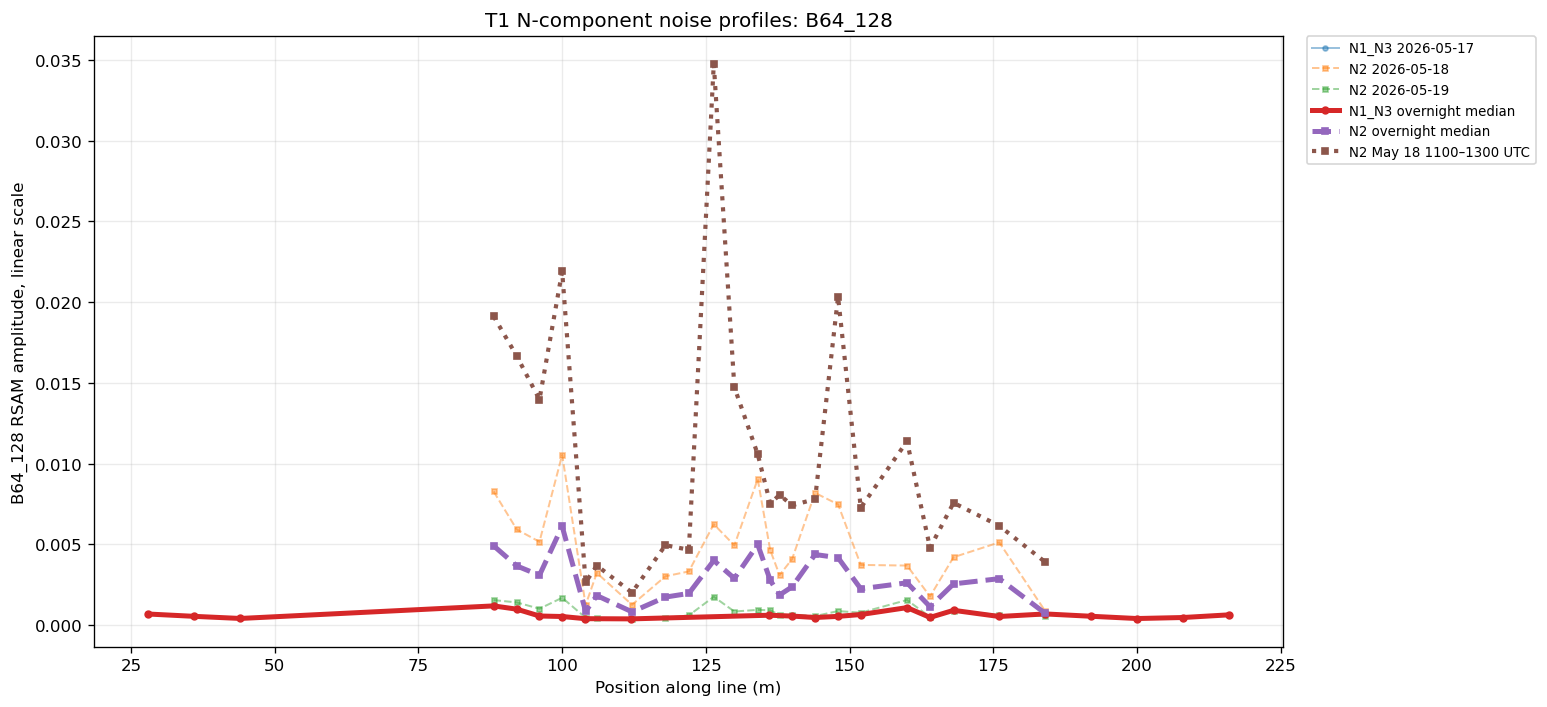

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_N_noise_profile_B64_128.png


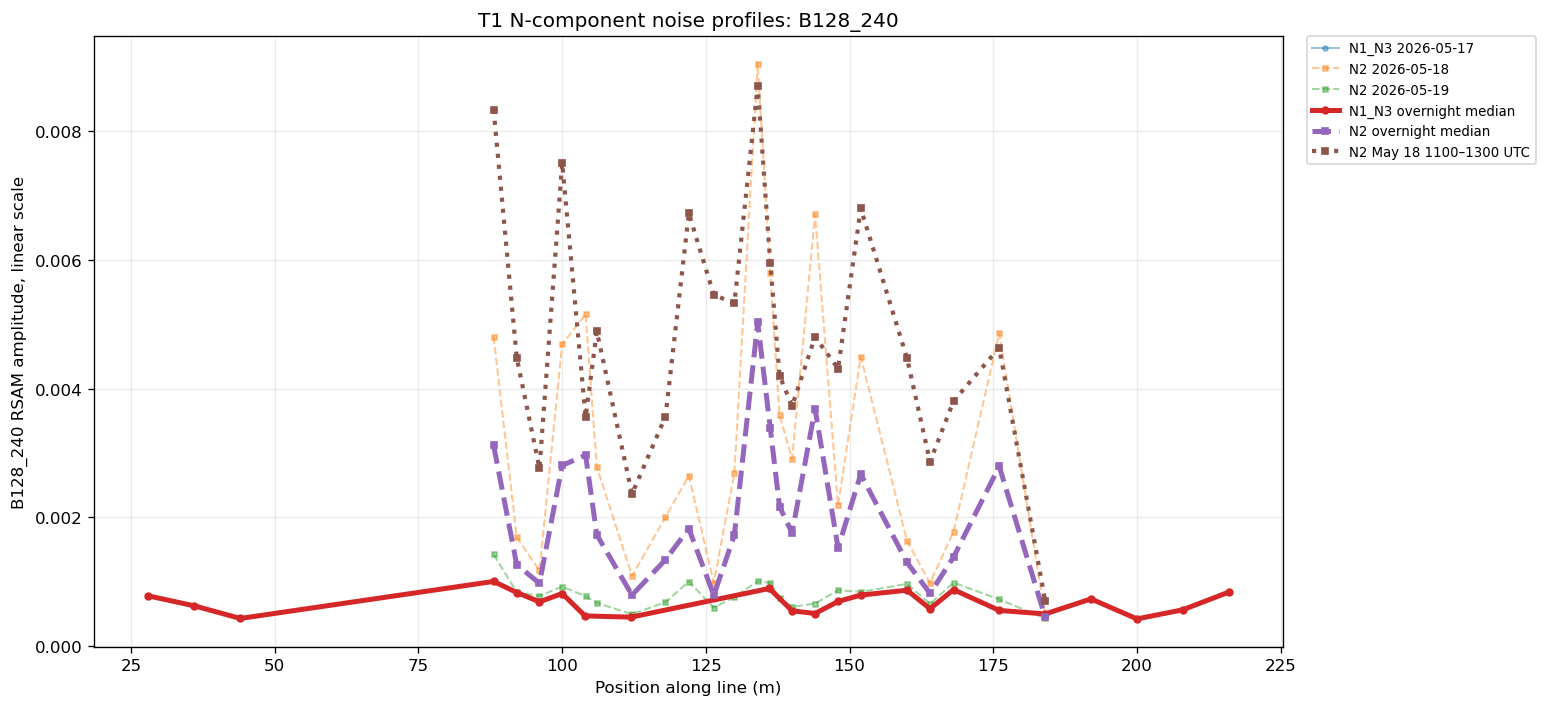

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_N_noise_profile_B128_240.png


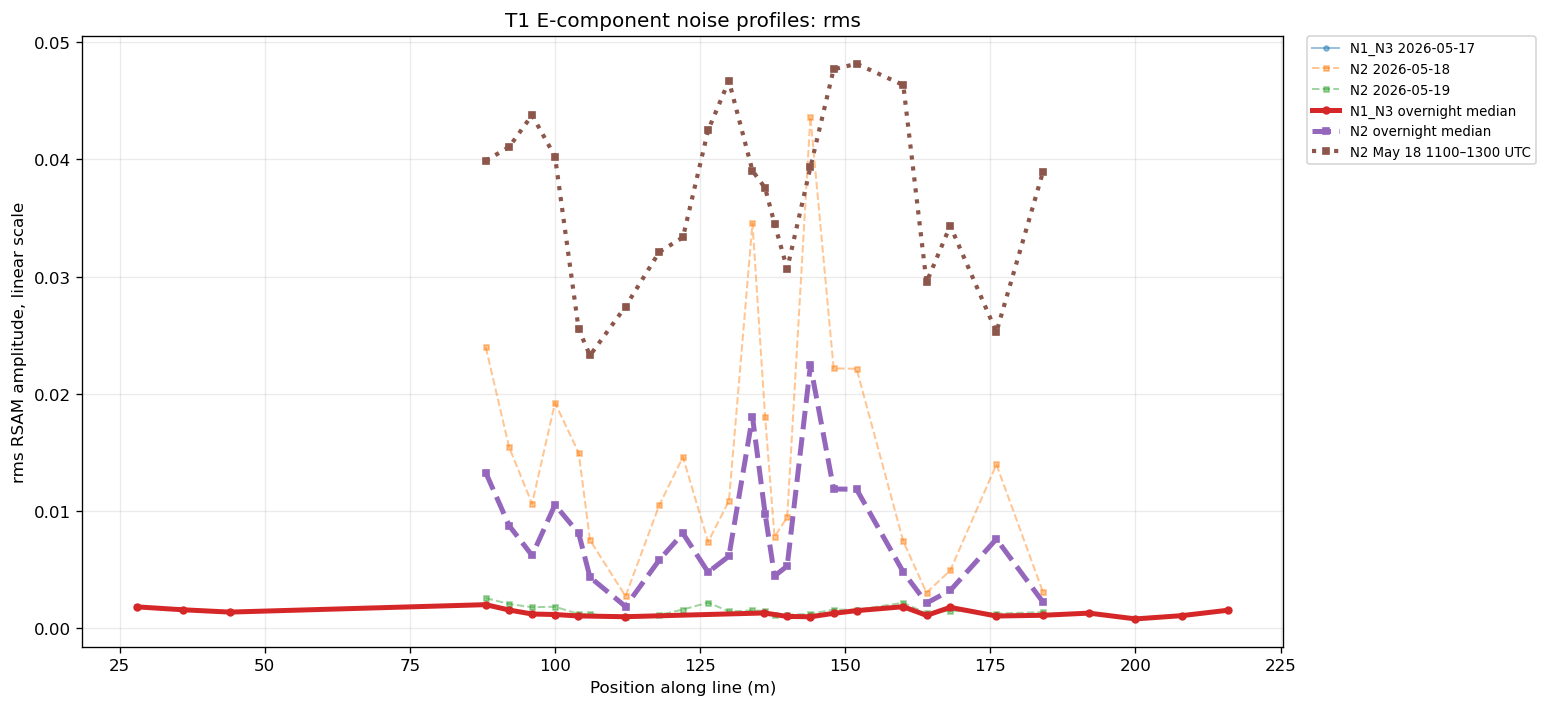

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_E_noise_profile_rms.png


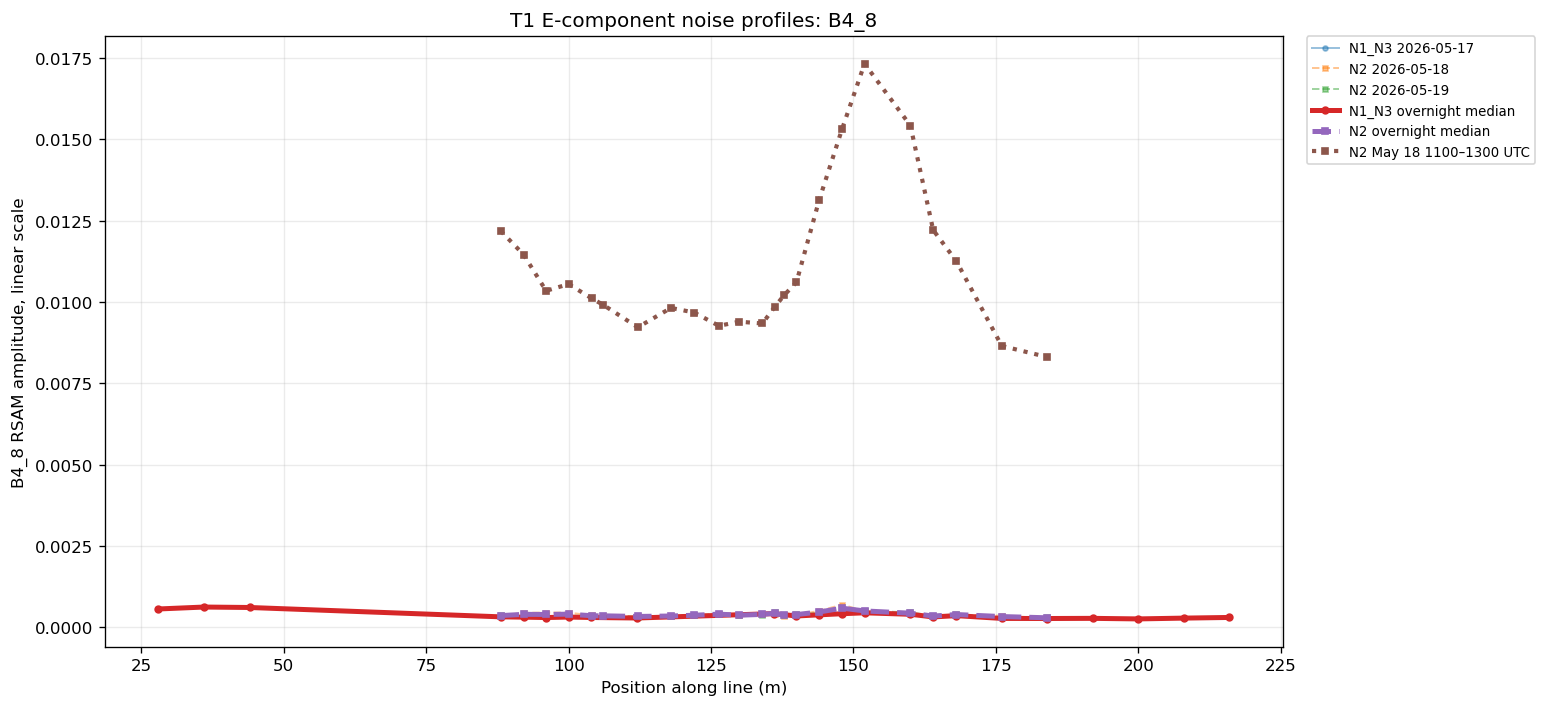

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_E_noise_profile_B4_8.png


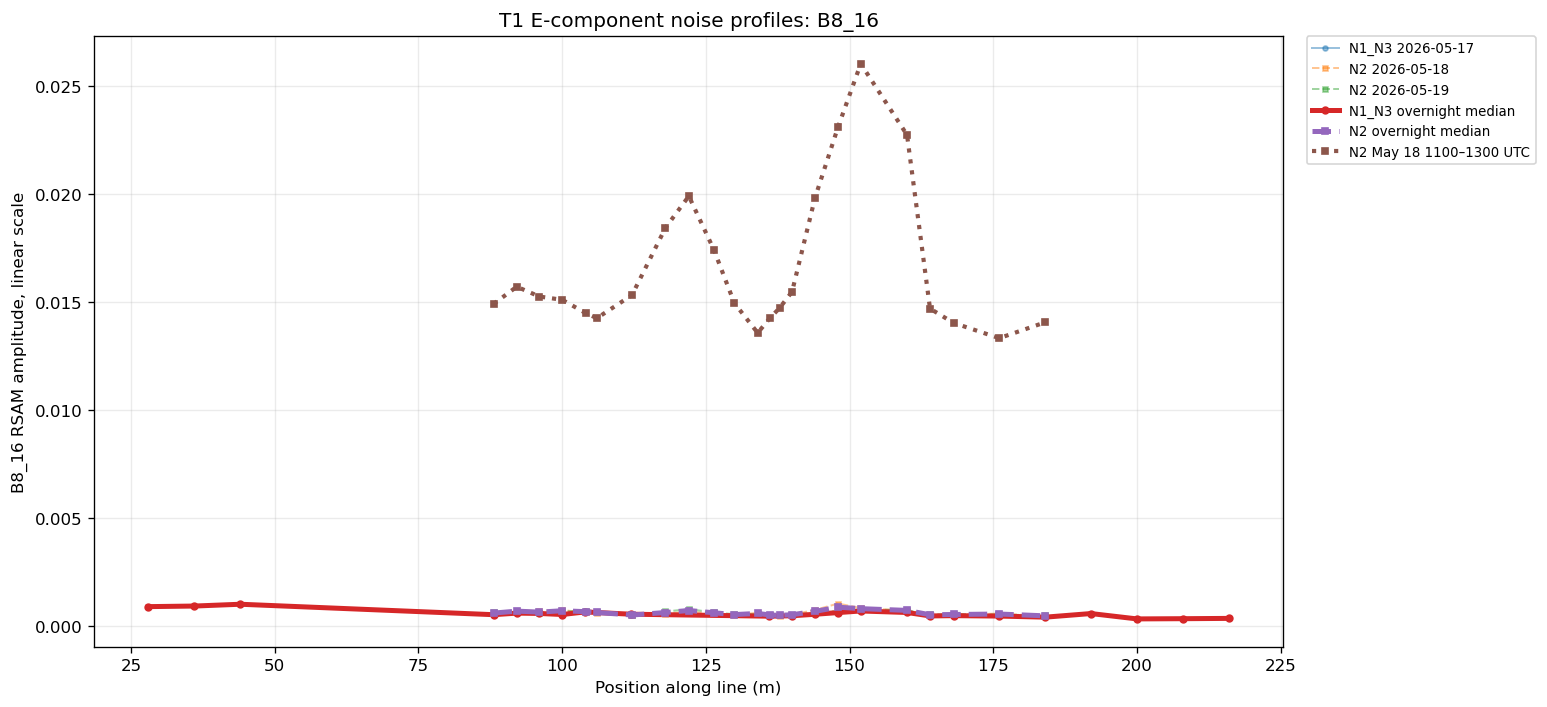

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_E_noise_profile_B8_16.png


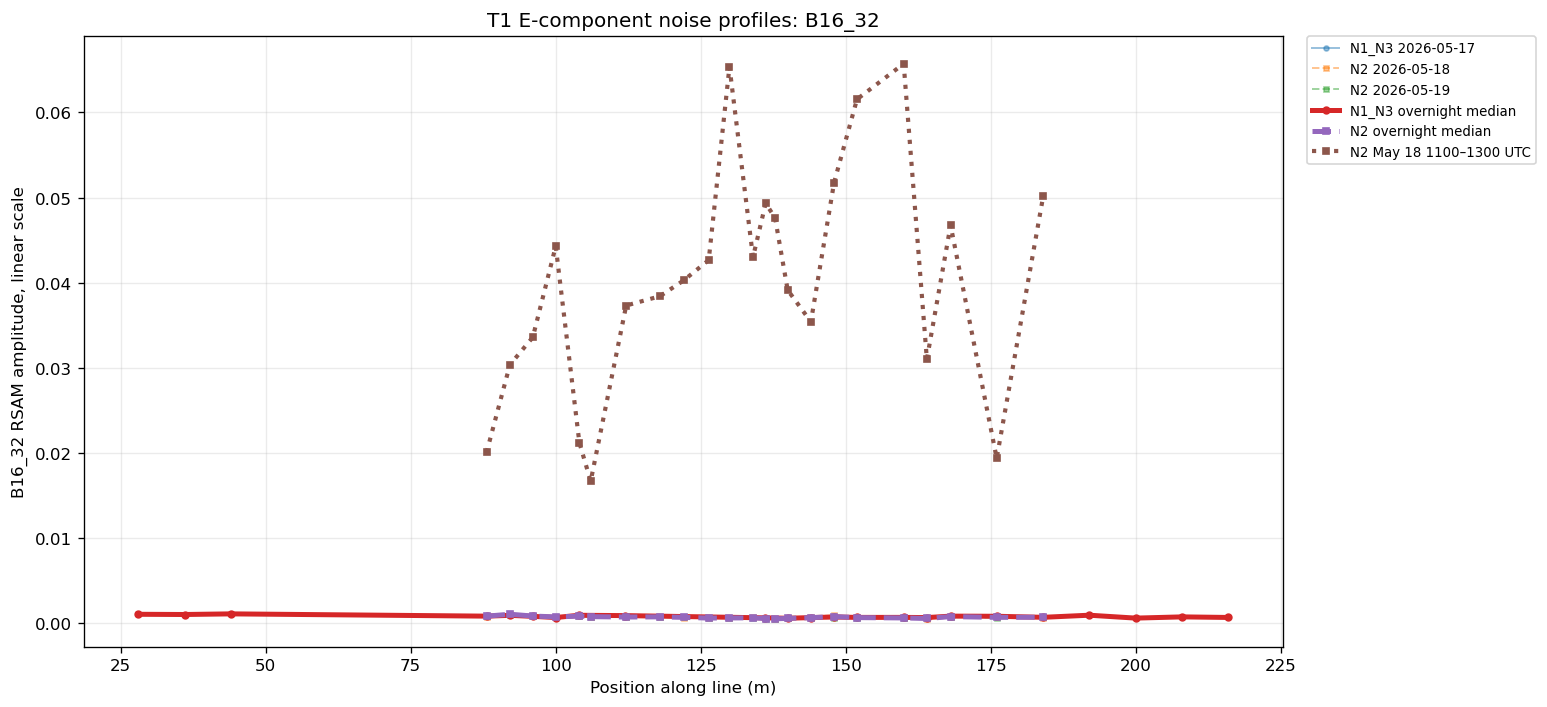

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_E_noise_profile_B16_32.png


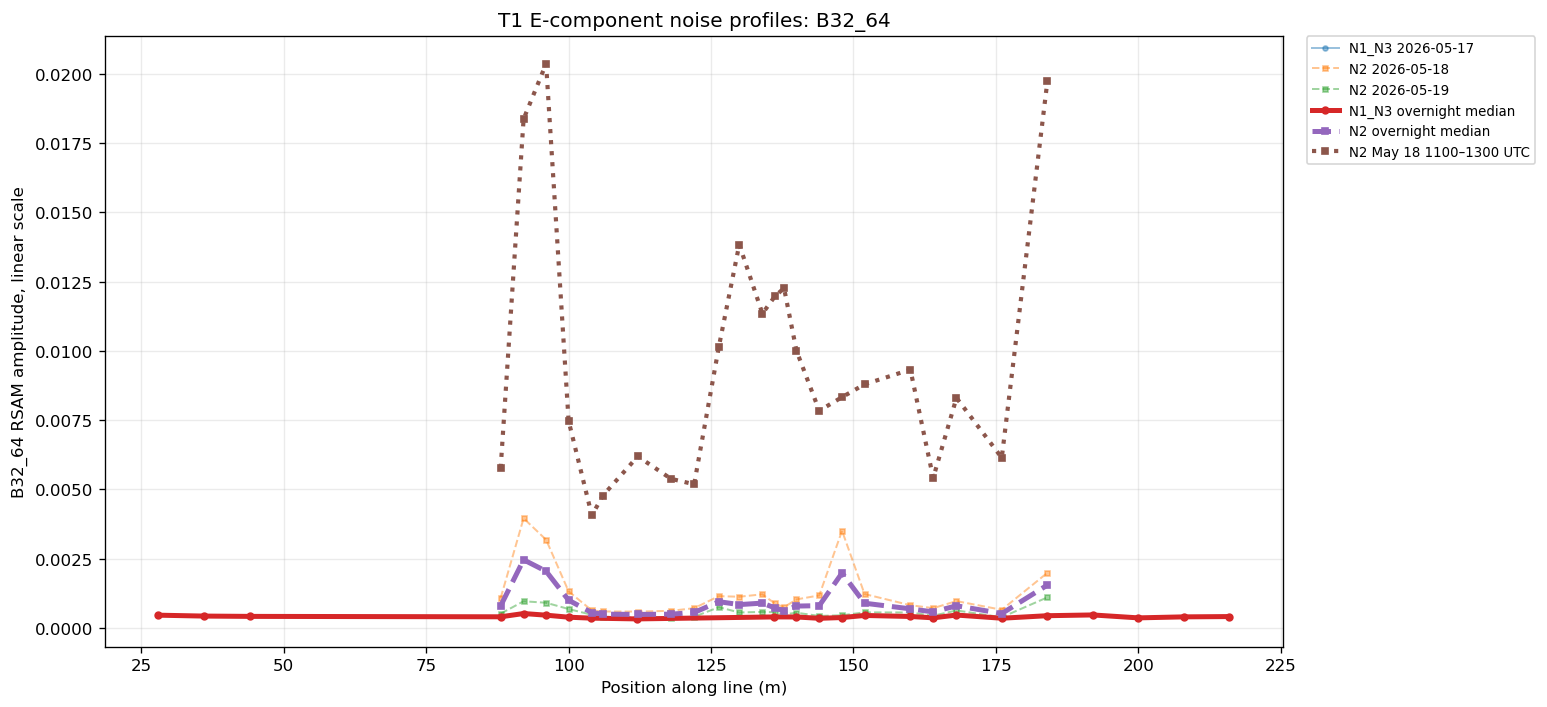

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_E_noise_profile_B32_64.png


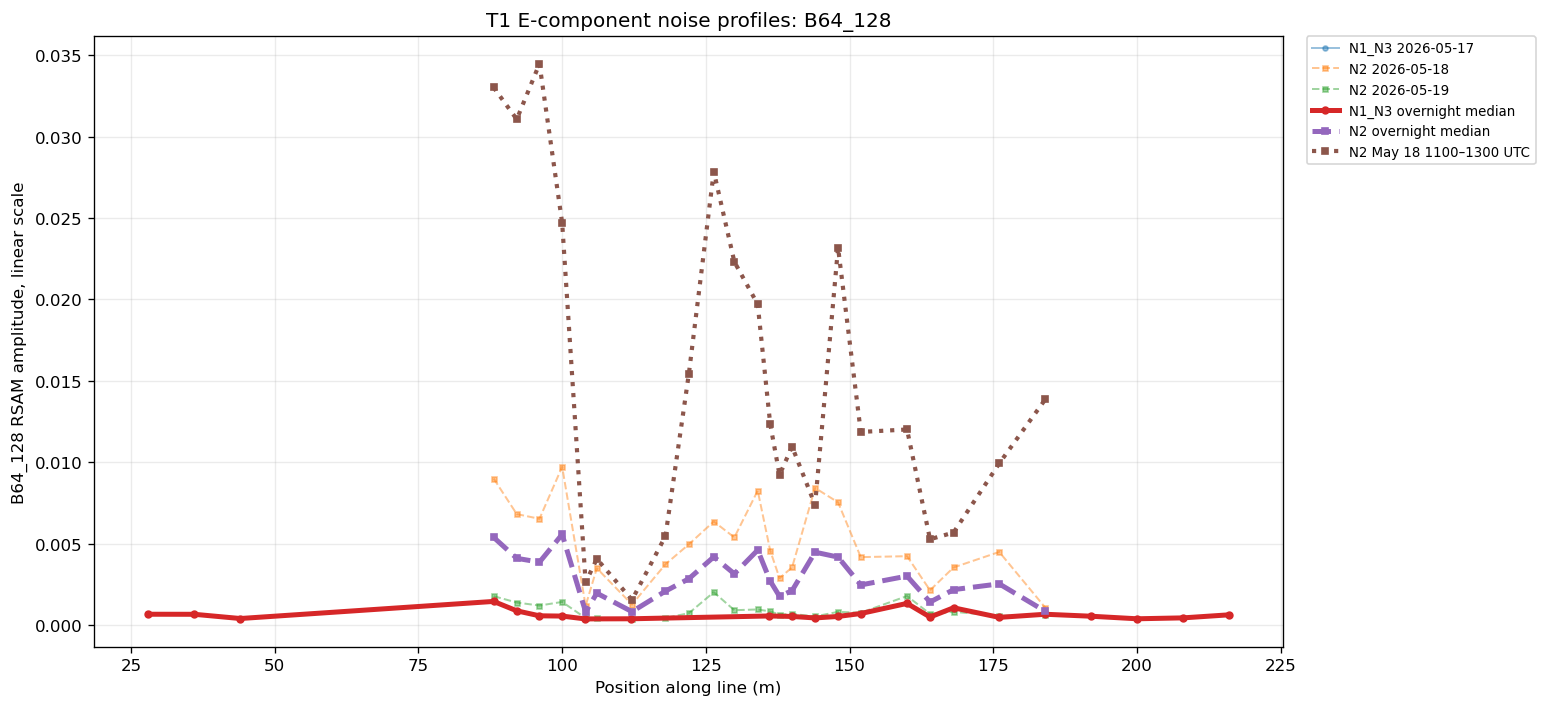

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_E_noise_profile_B64_128.png


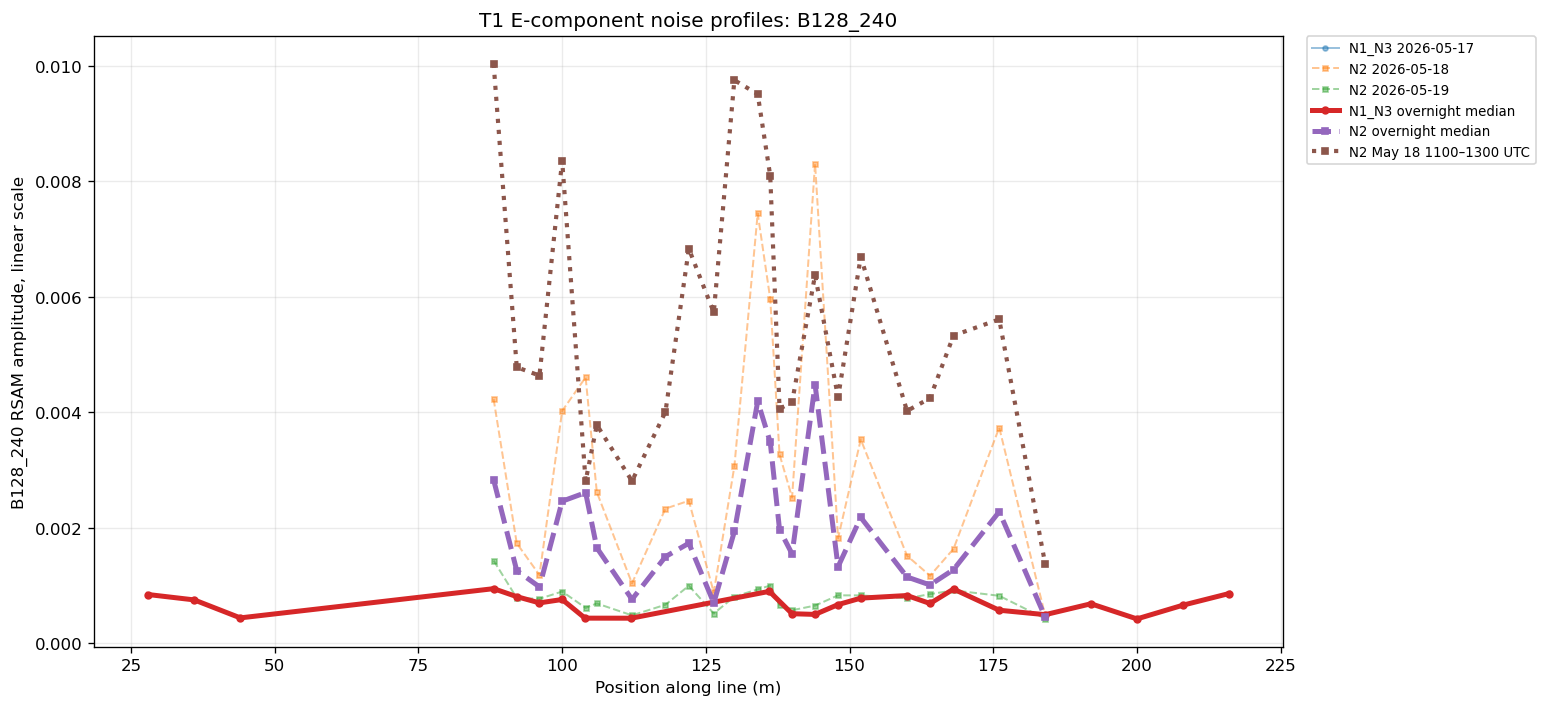

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_ALL_LINES_E_noise_profile_B128_240.png
No data for T3 Z rms
No data for T3 Z B4_8
No data for T3 Z B8_16
No data for T3 Z B16_32
No data for T3 Z B32_64
No data for T3 Z B64_128
No data for T3 Z B128_240
No data for T3 N rms
No data for T3 N B4_8
No data for T3 N B8_16
No data for T3 N B16_32
No data for T3 N B32_64
No data for T3 N B64_128
No data for T3 N B128_240
No data for T3 E rms
No data for T3 E B4_8
No data for T3 E B8_16
No data for T3 E B16_32
No data for T3 E B32_64
No data for T3 E B64_128
No data for T3 E B128_240
Generated 21 all-lines plot files


In [9]:
all_line_plot_files = []

for network in NETWORKS:
    for component in ["Z", "N", "E"]:
        for band in BANDS:
            outfile = plot_noise_profile_all_lines(summary, network, component, band)
            if outfile is not None:
                all_line_plot_files.append(outfile)

print(f"Generated {len(all_line_plot_files)} all-lines plot files")

## Logging / quiet-night ratios

In [10]:
def compute_logging_ratio(summary, quiet_period="overnight_2026-05-19_0400_0800"):
    logging = summary[summary["period"] == "may18_1100_1300_pre_site"].copy()
    quiet = summary[summary["period"] == quiet_period].copy()
    keys = ["network", "component", "location", "plot_group", "station", "position_m", "band"]

    ratio_df = (
        logging[keys + ["median"]]
        .rename(columns={"median": "logging_median"})
        .merge(
            quiet[keys + ["median"]].rename(columns={"median": "quiet_median"}),
            on=keys,
            how="inner",
        )
    )

    ratio_df["ratio"] = ratio_df["logging_median"] / ratio_df["quiet_median"]
    ratio_df = ratio_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["ratio"])
    return ratio_df

ratio_df = compute_logging_ratio(summary)
ratio_csv = OUT_DIR / "nodal_logging_to_quiet_ratio_by_position_all_components.csv"
ratio_df.to_csv(ratio_csv, index=False)
print(f"Wrote {ratio_csv}")

display(
    ratio_df.groupby(["network", "component", "band"])["ratio"]
    .agg(["count", "median", "min", "max"])
    .reset_index()
)

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/nodal_logging_to_quiet_ratio_by_position_all_components.csv


,network,component,band,count,median,min,max
0,T1,E,B128_240,24,6.094360,3.196717,12.046730
1,T1,E,B16_32,24,58.946642,20.883861,165.567468
2,T1,E,B32_64,24,16.503277,8.649402,25.252640
3,T1,E,B4_8,24,28.481510,21.319601,35.908370
4,T1,E,B64_128,24,15.247220,4.030945,28.777031
5,T1,E,B8_16,24,26.998814,20.532180,34.007097
6,T1,E,rms,24,24.980528,15.541613,44.989385
7,T1,N,B128_240,24,5.731156,1.616008,9.105020
8,T1,N,B16_32,24,50.614568,18.633448,89.048488
9,T1,N,B32_64,24,10.017187,8.111490,14.029642


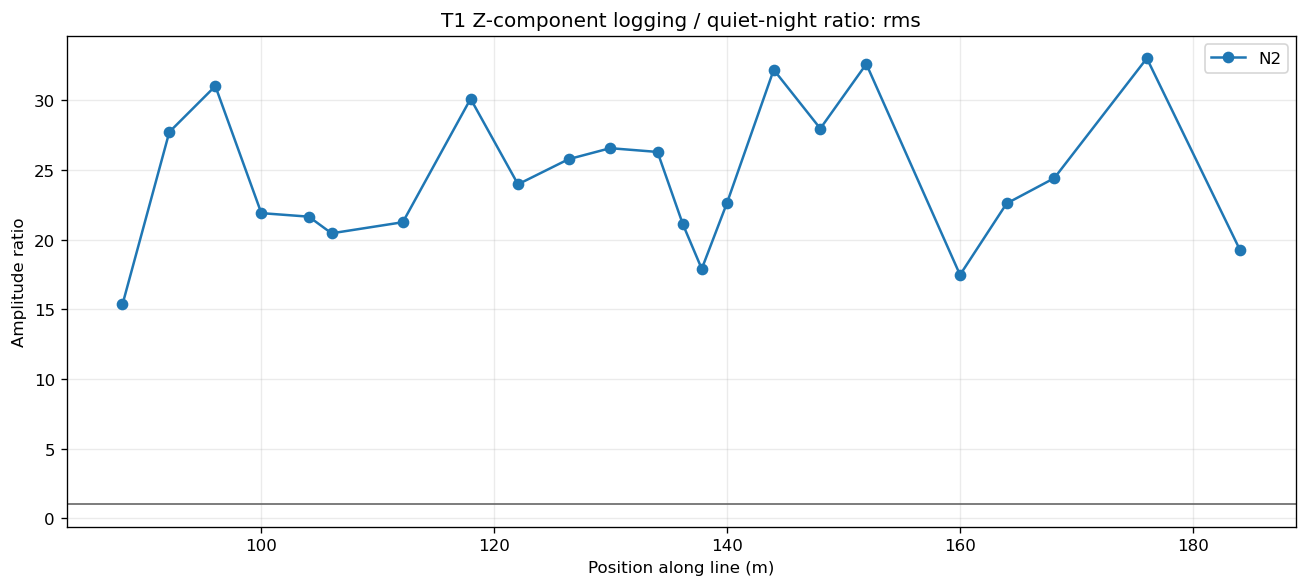

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_Z_logging_to_quiet_ratio_rms.png


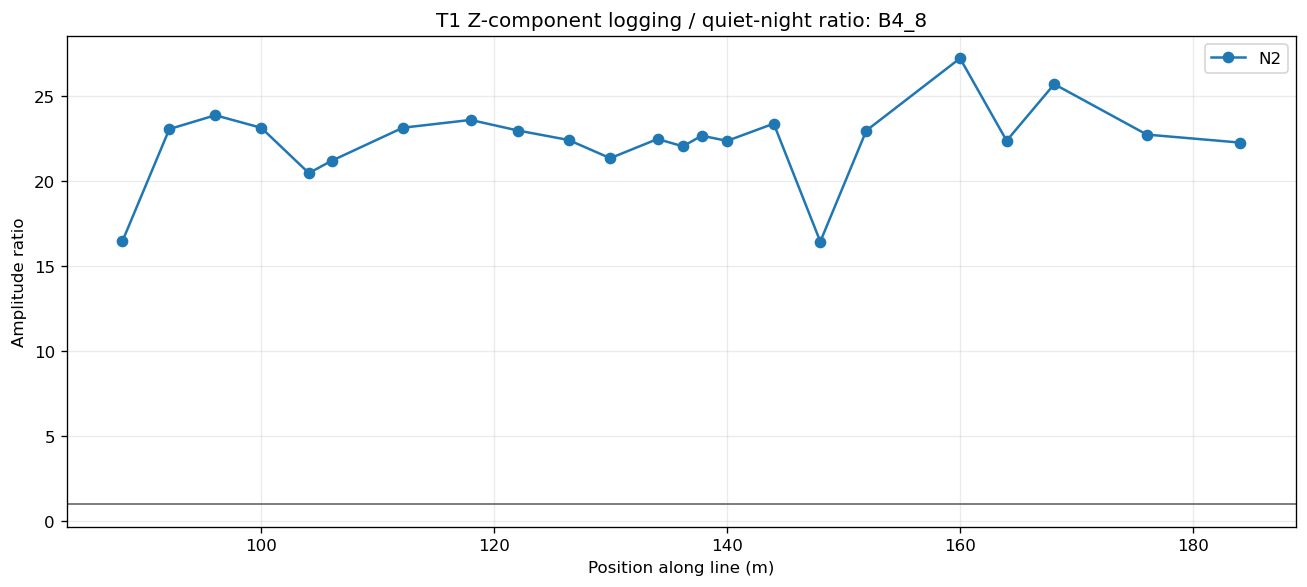

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_Z_logging_to_quiet_ratio_B4_8.png


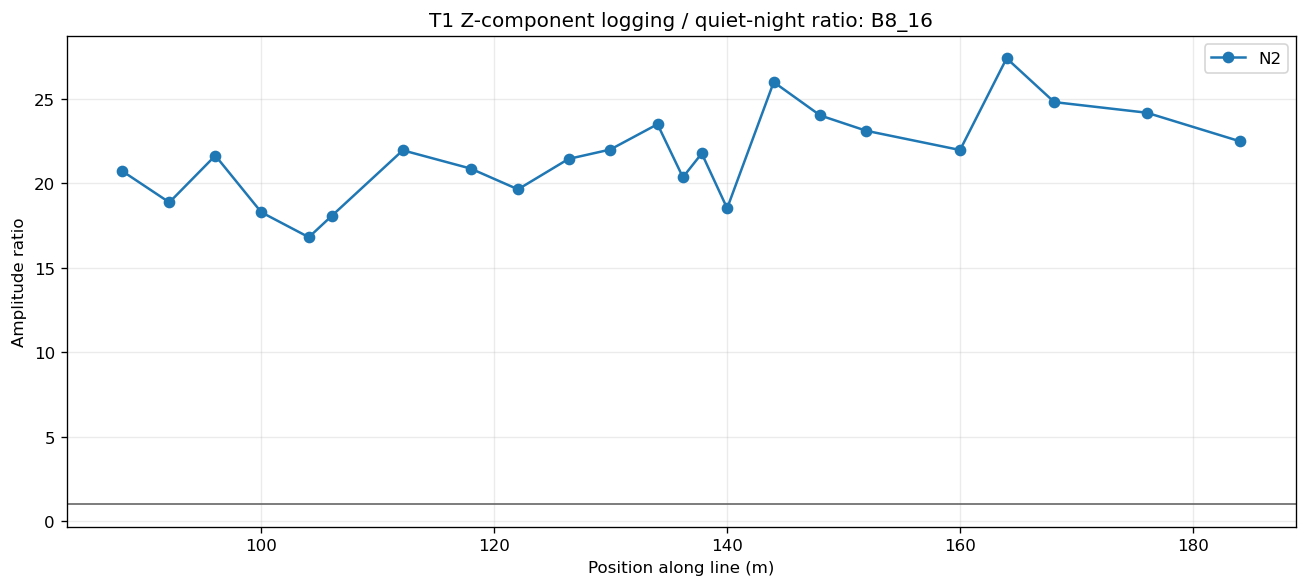

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_Z_logging_to_quiet_ratio_B8_16.png


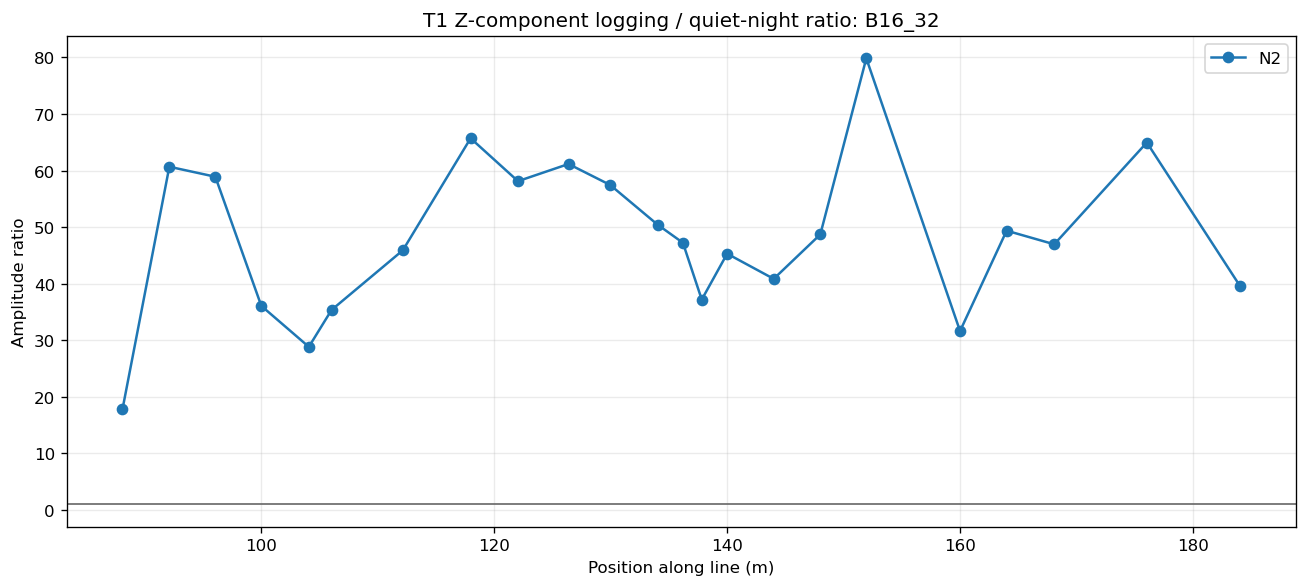

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_Z_logging_to_quiet_ratio_B16_32.png


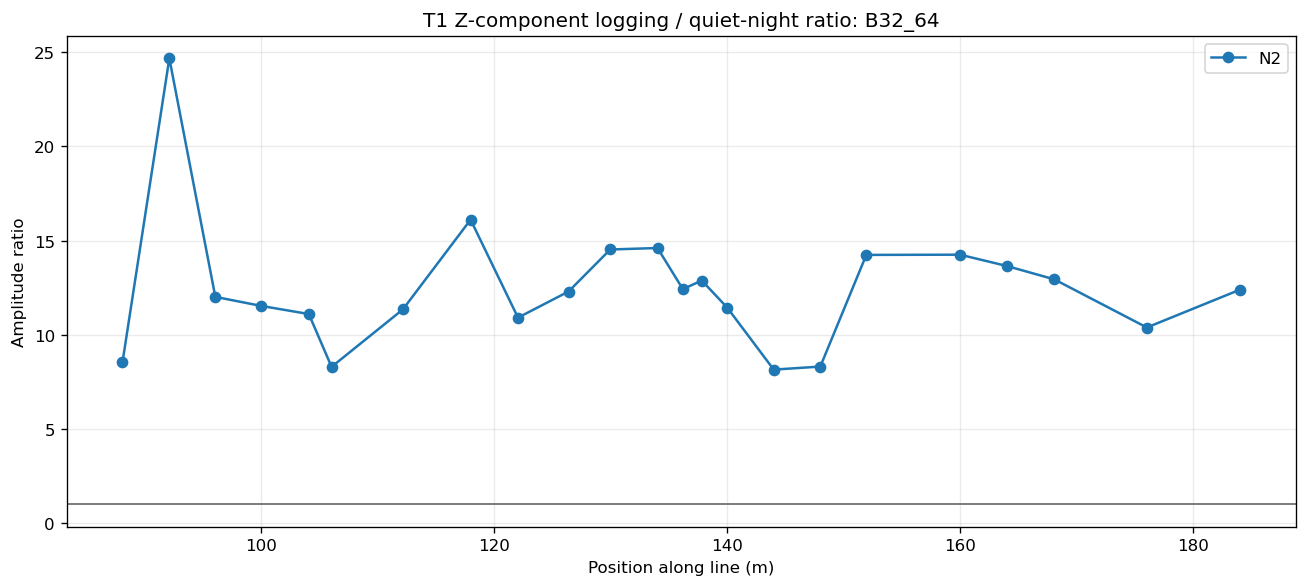

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_Z_logging_to_quiet_ratio_B32_64.png


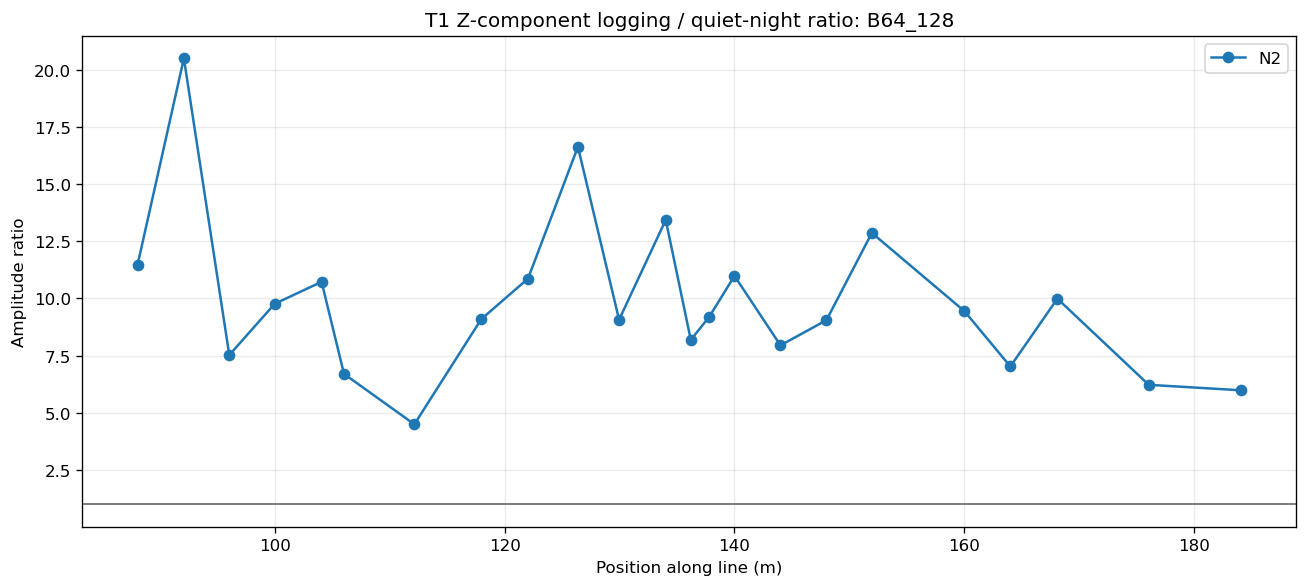

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_Z_logging_to_quiet_ratio_B64_128.png


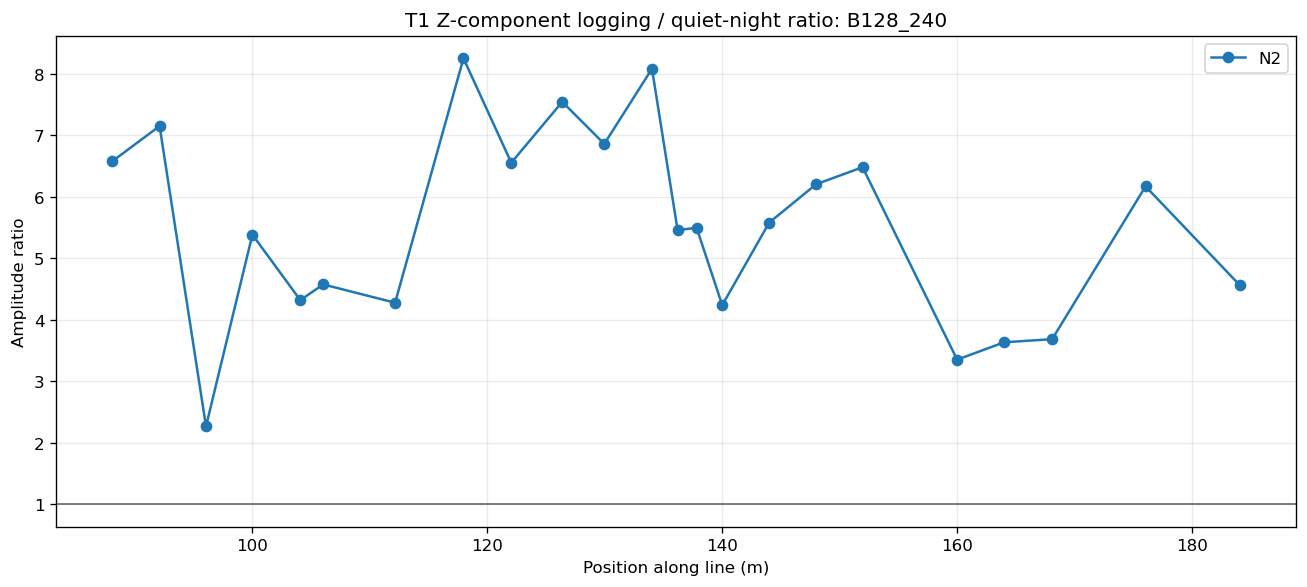

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_Z_logging_to_quiet_ratio_B128_240.png


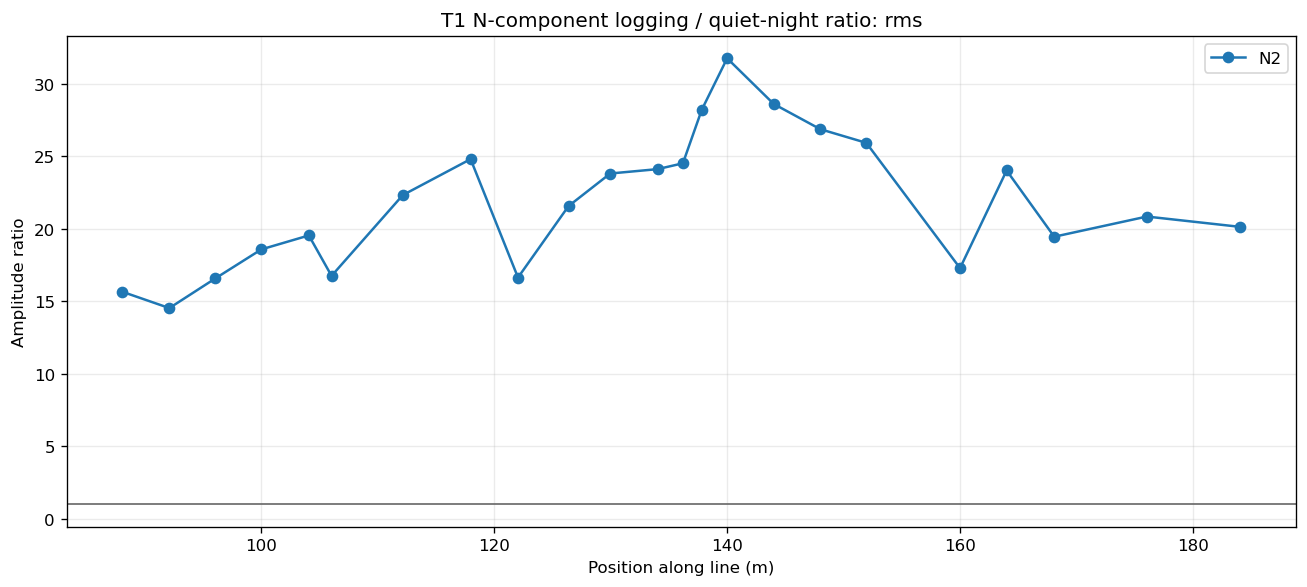

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N_logging_to_quiet_ratio_rms.png


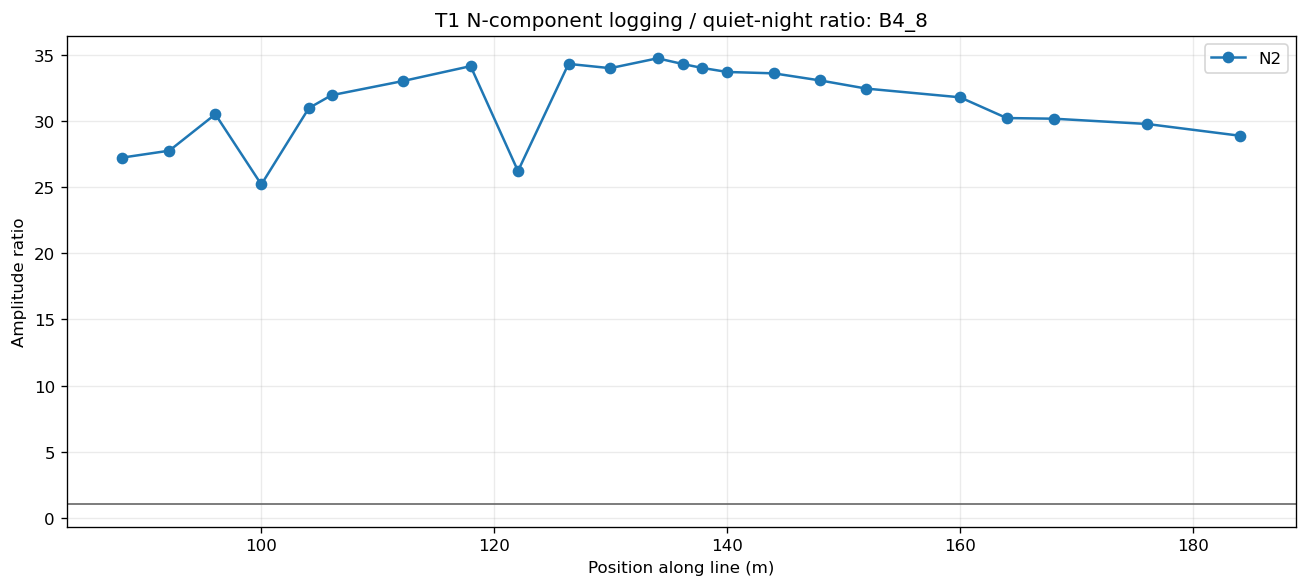

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N_logging_to_quiet_ratio_B4_8.png


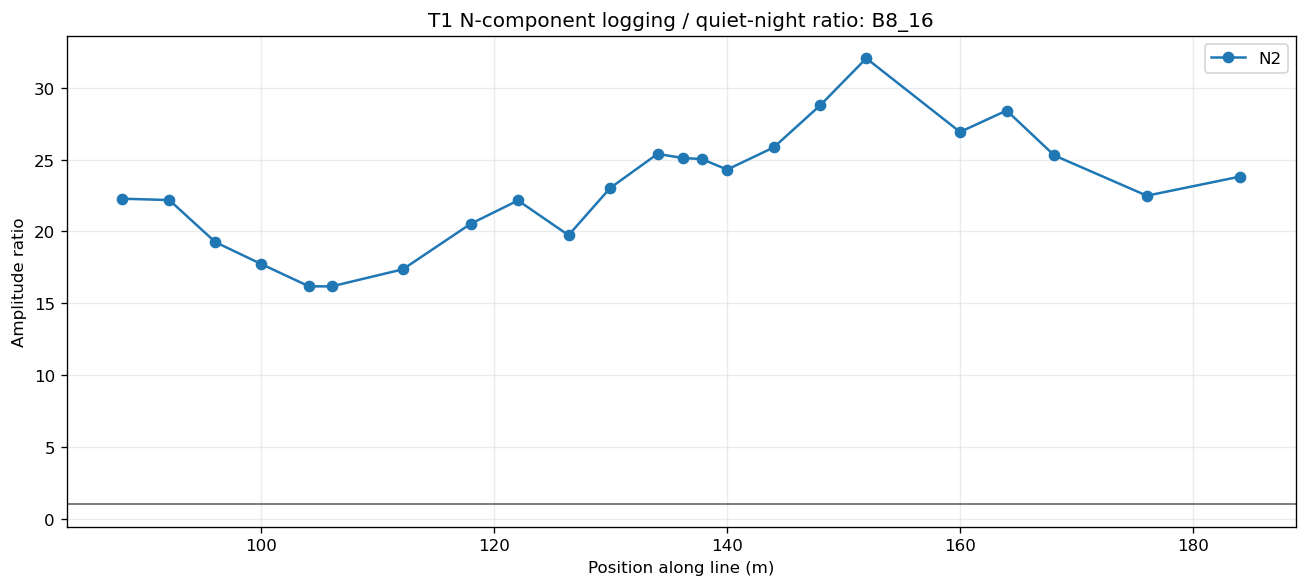

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N_logging_to_quiet_ratio_B8_16.png


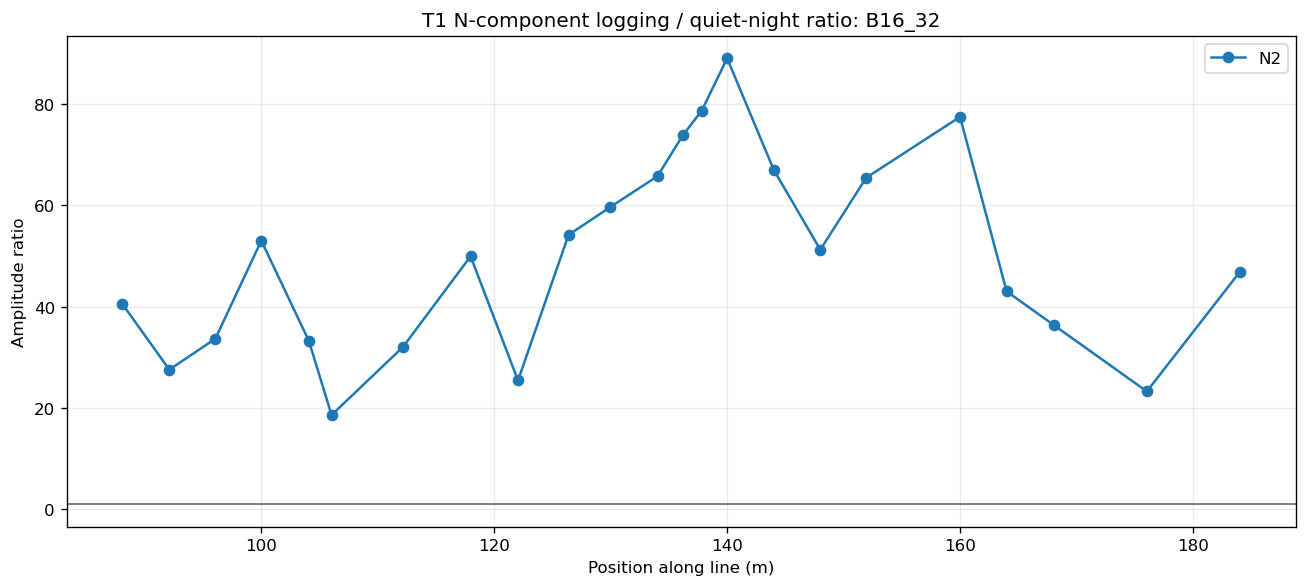

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N_logging_to_quiet_ratio_B16_32.png


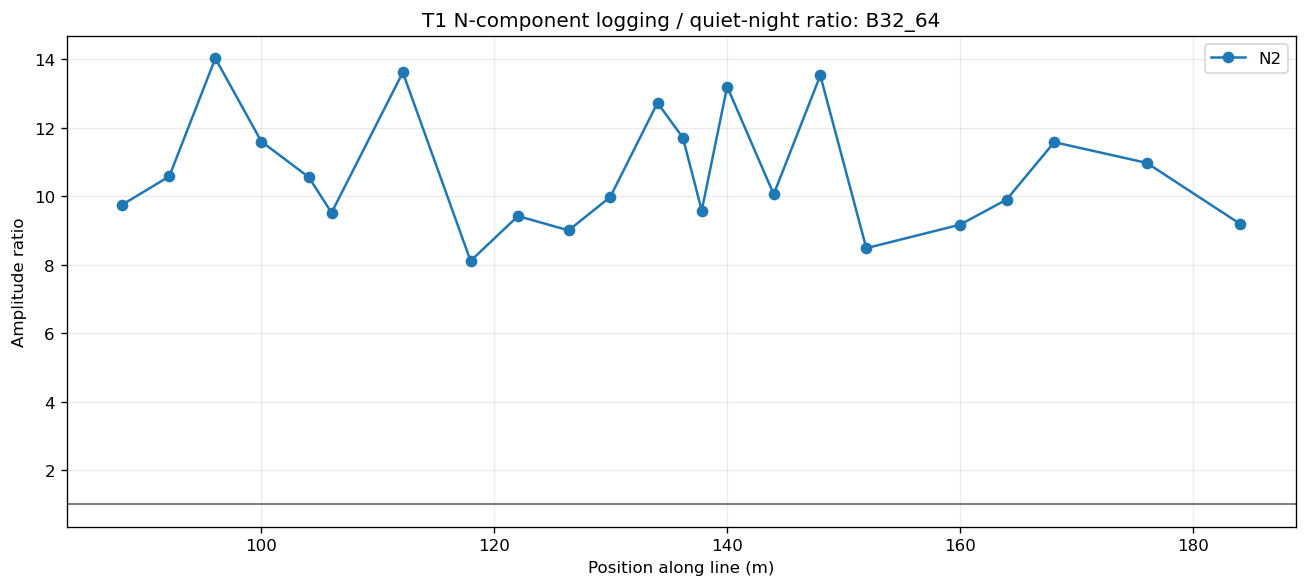

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N_logging_to_quiet_ratio_B32_64.png


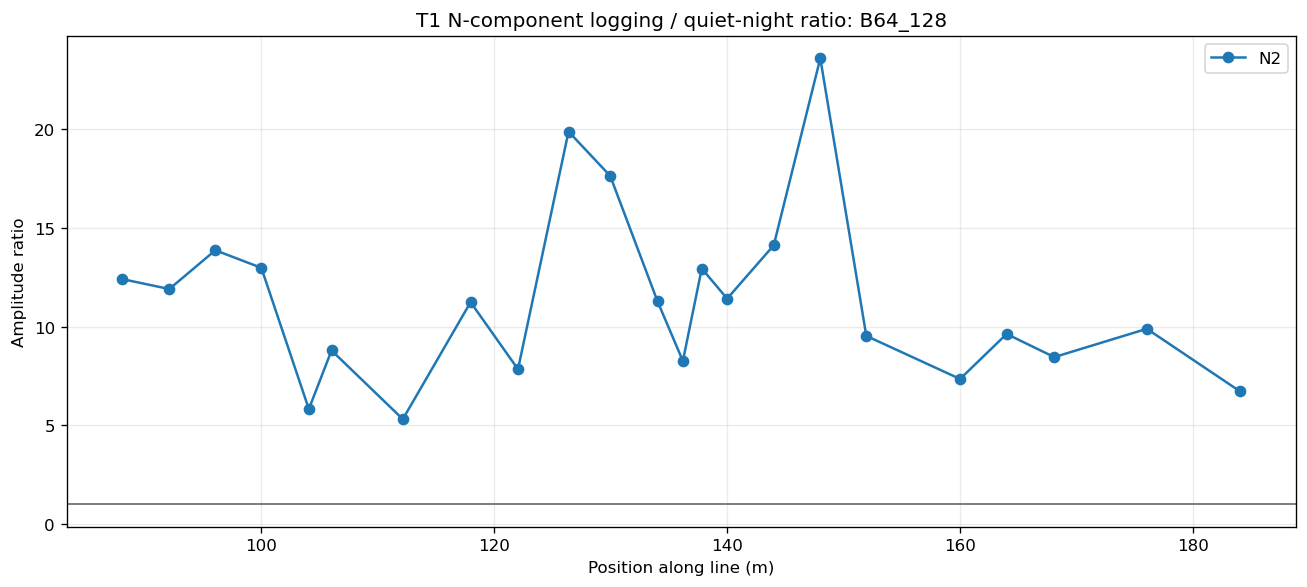

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N_logging_to_quiet_ratio_B64_128.png


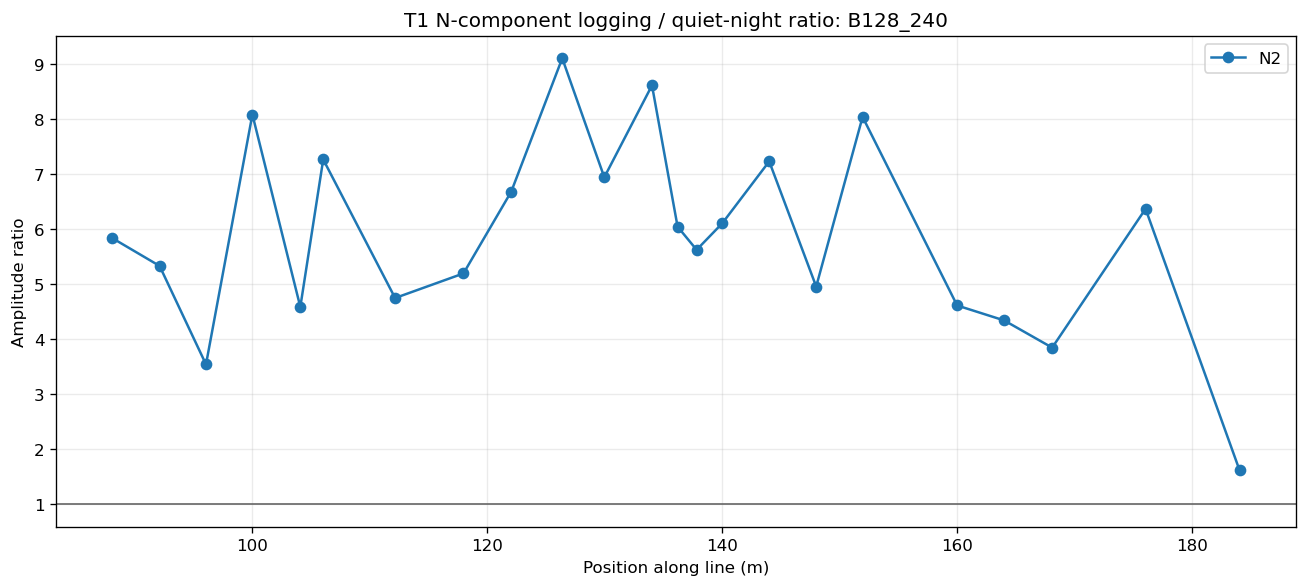

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_N_logging_to_quiet_ratio_B128_240.png


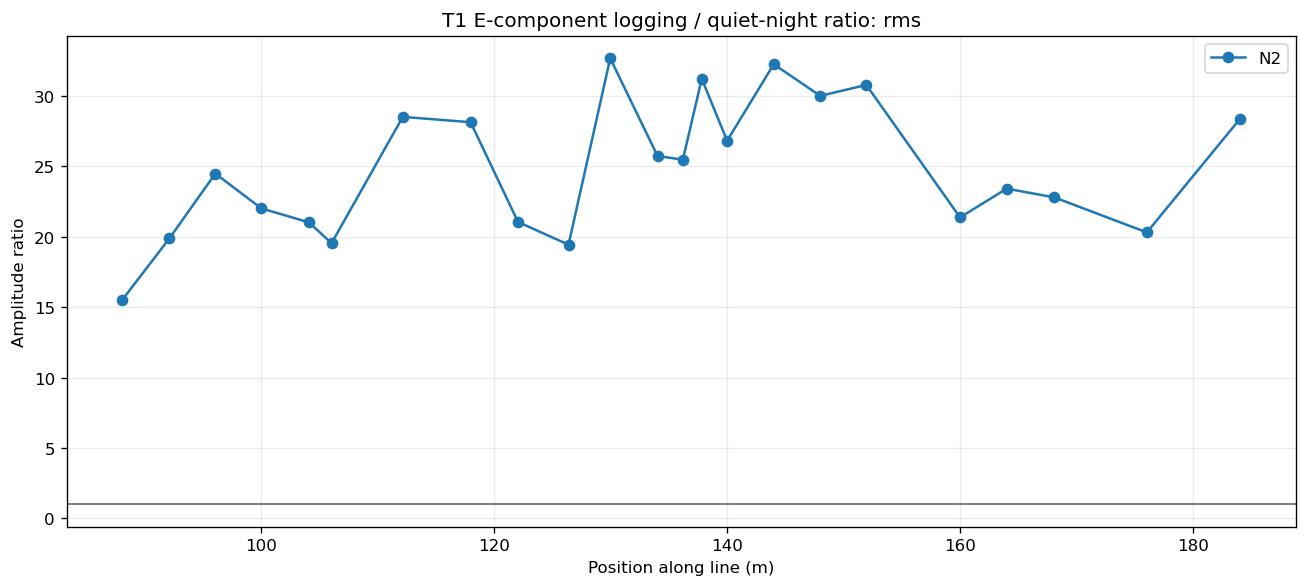

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_E_logging_to_quiet_ratio_rms.png


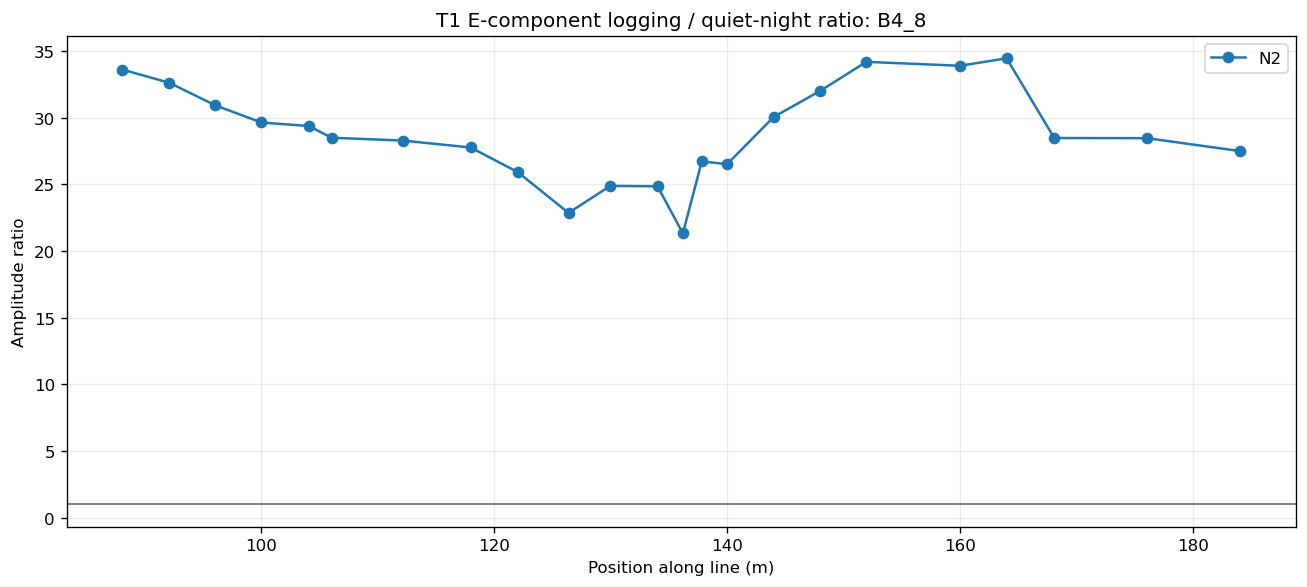

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_E_logging_to_quiet_ratio_B4_8.png


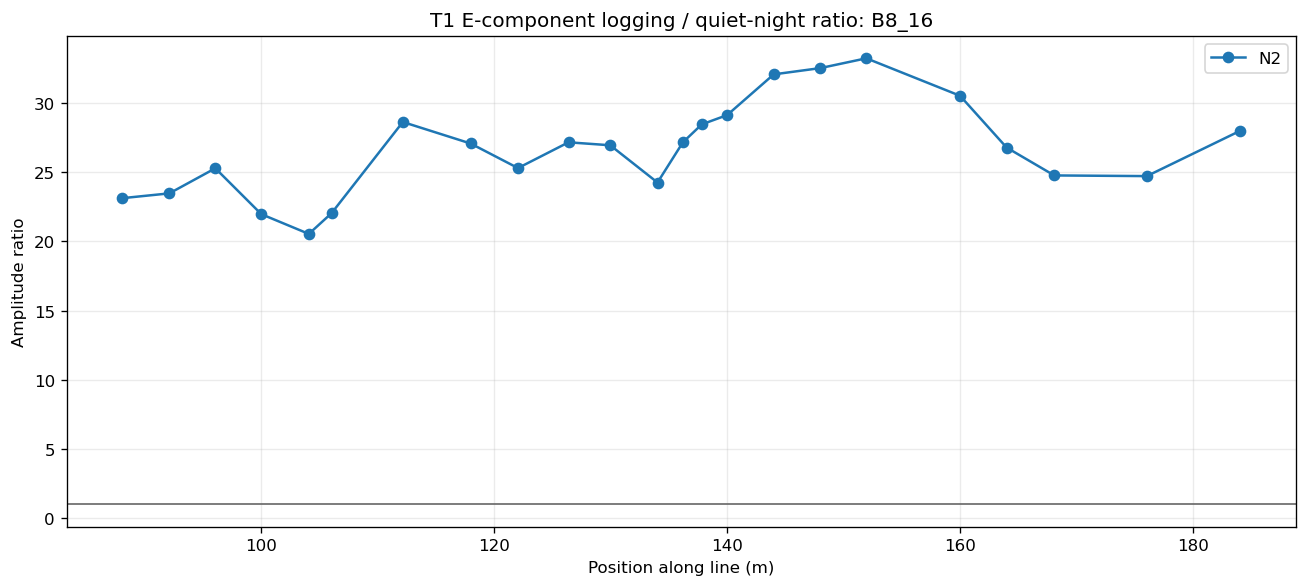

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_E_logging_to_quiet_ratio_B8_16.png


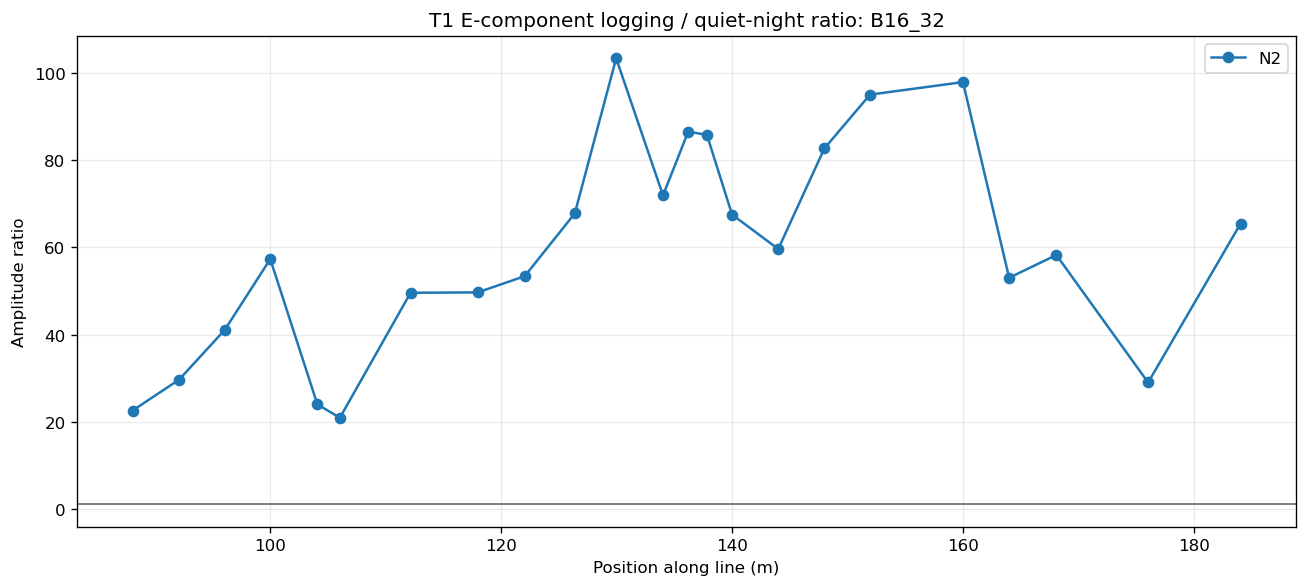

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_E_logging_to_quiet_ratio_B16_32.png


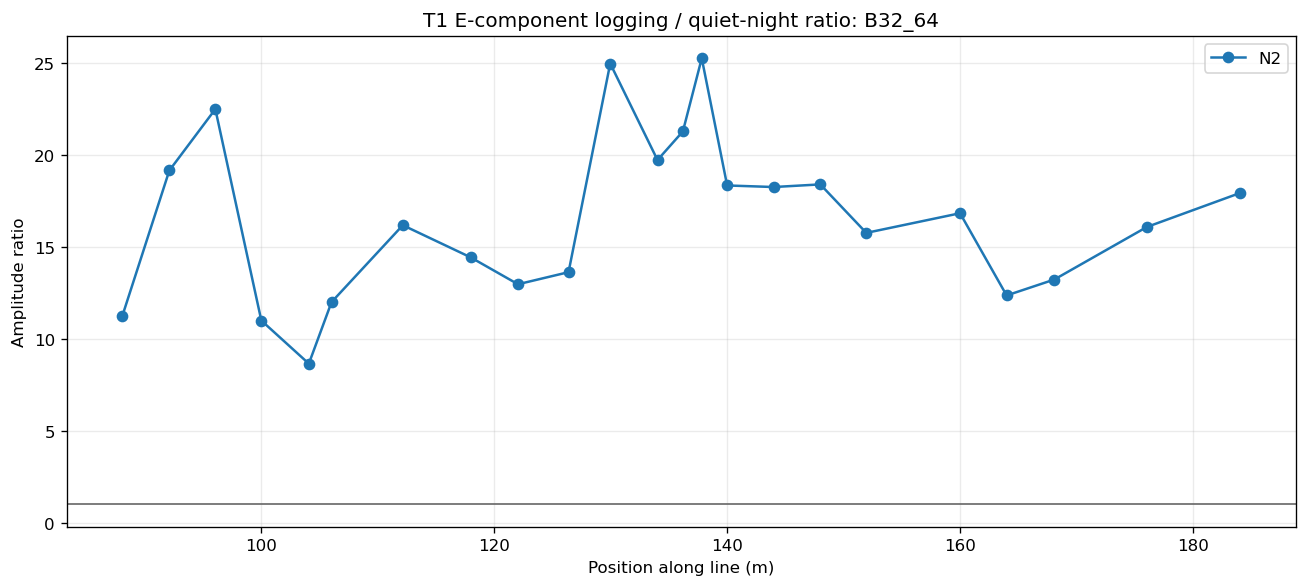

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_E_logging_to_quiet_ratio_B32_64.png


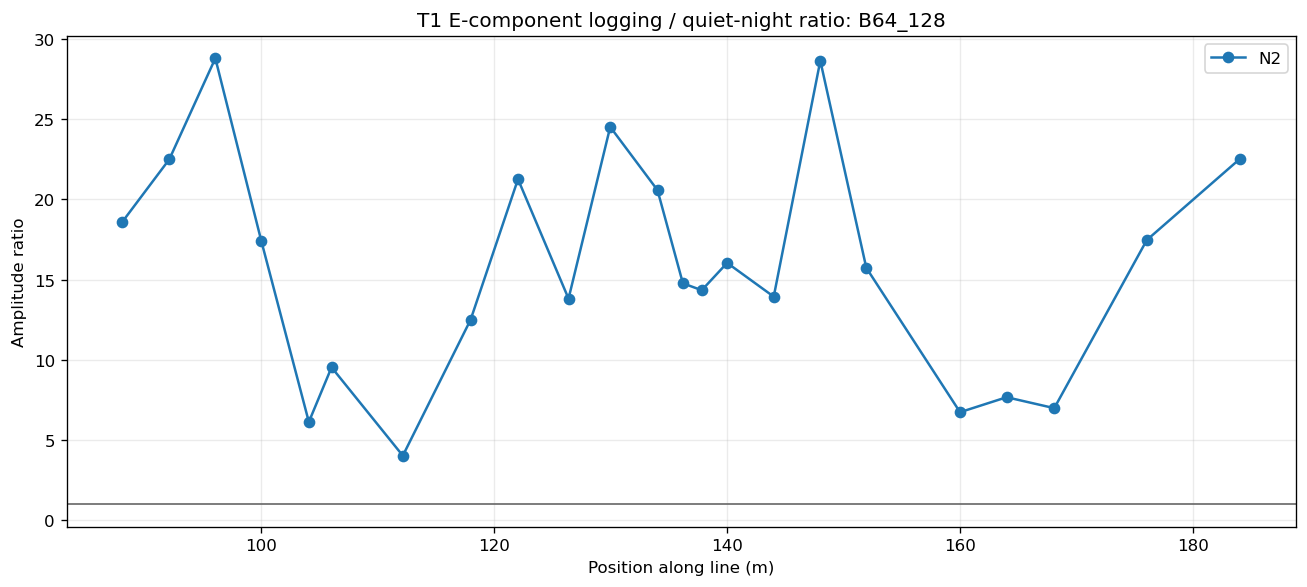

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_E_logging_to_quiet_ratio_B64_128.png


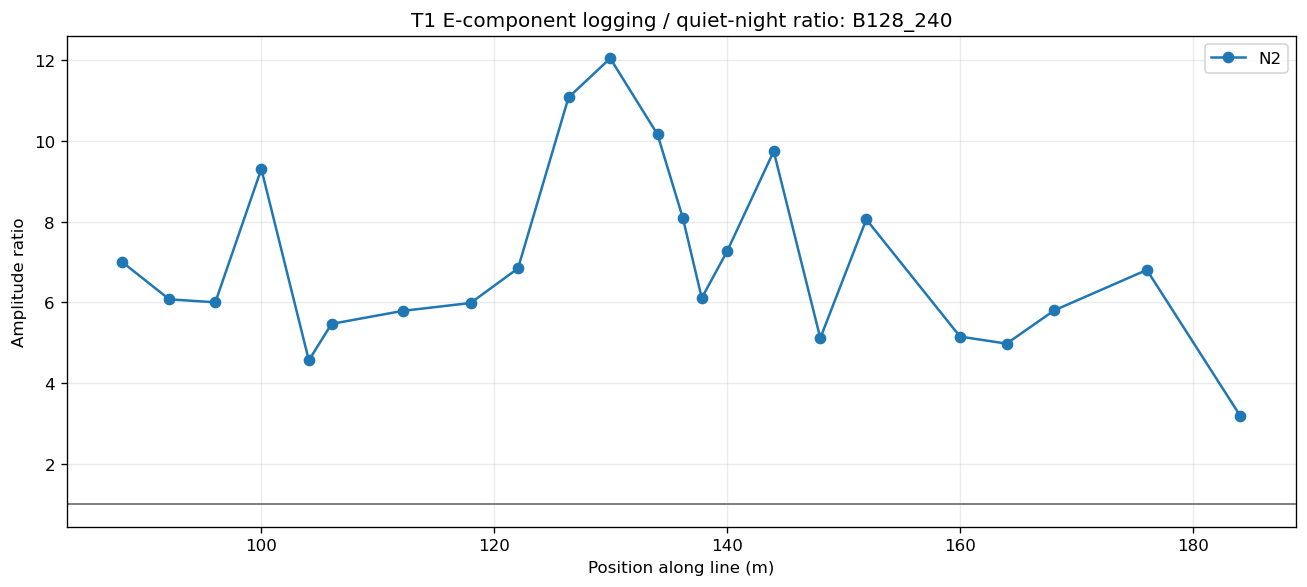

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/noise_profiles/T1_E_logging_to_quiet_ratio_B128_240.png
No ratio data for T3 Z rms
No ratio data for T3 Z B4_8
No ratio data for T3 Z B8_16
No ratio data for T3 Z B16_32
No ratio data for T3 Z B32_64
No ratio data for T3 Z B64_128
No ratio data for T3 Z B128_240
No ratio data for T3 N rms
No ratio data for T3 N B4_8
No ratio data for T3 N B8_16
No ratio data for T3 N B16_32
No ratio data for T3 N B32_64
No ratio data for T3 N B64_128
No ratio data for T3 N B128_240
No ratio data for T3 E rms
No ratio data for T3 E B4_8
No ratio data for T3 E B8_16
No ratio data for T3 E B16_32
No ratio data for T3 E B32_64
No ratio data for T3 E B64_128
No ratio data for T3 E B128_240
Generated 21 ratio plot files


In [11]:
def plot_logging_ratio(ratio_df, network, component, band):
    d = ratio_df[
        (ratio_df["network"] == network)
        & (ratio_df["component"] == component)
        & (ratio_df["band"] == band)
        & ratio_df["position_m"].notna()
    ].copy()

    if d.empty:
        print(f"No ratio data for {network} {component} {band}")
        return None

    fig, ax = plt.subplots(figsize=(11, 5))

    for plot_group, g in d.groupby("plot_group"):
        g = g.sort_values("position_m")
        ax.plot(g["position_m"], g["ratio"], "-o", label=plot_group)

    ax.axhline(1.0, color="0.4", linewidth=1.0)
    ax.set_title(f"{network} {component}-component logging / quiet-night ratio: {band}")
    ax.set_xlabel("Position along line (m)")
    ax.set_ylabel("Amplitude ratio")
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()

    outfile = OUT_DIR / f"{network}_{component}_logging_to_quiet_ratio_{band}.png"
    fig.savefig(outfile, dpi=200)
    plt.show()
    print(f"Wrote {outfile}")
    return outfile

ratio_plot_files = []
for network in NETWORKS:
    for component in ["Z", "N", "E"]:
        for band in BANDS:
            outfile = plot_logging_ratio(ratio_df, network, component, band)
            if outfile is not None:
                ratio_plot_files.append(outfile)

print(f"Generated {len(ratio_plot_files)} ratio plot files")

## Diagnostics

In [12]:
if not summary.empty:
    unmatched = summary[summary["position_m"].isna()][
        ["network", "seed_id", "location", "station", "geometry_window_id"]
    ].drop_duplicates()
    print(f"Unmatched station/location rows: {len(unmatched)}")
    display(unmatched)

    print("Stations by network/location/component:")
    display(summary.groupby(["network", "location", "component"])["station"].nunique().reset_index(name="n_stations"))

    print("Position range by network/location/component:")
    display(
        summary.dropna(subset=["position_m"])
        .groupby(["network", "location", "component"])["position_m"]
        .agg(["count", "min", "max"])
        .reset_index()
    )

Unmatched station/location rows: 6


,network,seed_id,location,station,geometry_window_id
1182,T1,T1.12928.N1.DPE,N1,12928,1
1217,T1,T1.12928.N2.DPE,N2,12928,2
1189,T1,T1.12928.N1.DPN,N1,12928,1
1238,T1,T1.12928.N2.DPN,N2,12928,2
1196,T1,T1.12928.N1.DPZ,N1,12928,1
1259,T1,T1.12928.N2.DPZ,N2,12928,2


Stations by network/location/component:


,network,location,component,n_stations
0,T1,N1,E,24
1,T1,N1,N,24
2,T1,N1,Z,24
3,T1,N2,E,24
4,T1,N2,N,24
5,T1,N2,Z,24


Position range by network/location/component:


,network,location,component,count,min,max
0,T1,N1,E,161,28.000,216.00
1,T1,N1,N,161,28.000,216.00
2,T1,N1,Z,161,28.000,216.00
3,T1,N2,E,483,88.075,184.05
4,T1,N2,N,483,88.075,184.05
5,T1,N2,Z,483,88.075,184.05
